# 📊 ML Portfolio Factor Analysis - Regime-Switching Strategies

## Overview
This notebook analyzes the risk-adjusted performance (alphas) of 25 ML strategies (5 baskets × 5 models) under different factor models. It generates 10 tables (5 main text + 5 appendix) and 3 figures to document the robustness of ML strategies across different factor specifications, alternative benchmarks, and time subperiods.

## 🎯 Generated Outputs

#### Output Folder : (`results/latex/results/`)

### 📄 Main Text Tables

1. **Table 5** (`05_results_Factors_Basket_VS_ML_table.tex`)
   - **Content**: Factor performance (Best ML per basket) — FF6 vs Q5
   - **Panel A**: Buy&Hold Baskets (Offensive + Defensive)
   - **Panel B**: Best ML Strategies (1 per basket, selected on full-sample NET Sharpe)
   - **Columns**: Basket, Strategy/Model, α (FF6), *, t, R², α (Q5), *, t, R²

2. **Table 6** (`06_results_Incremental_Alpha_ML_vs_5050.tex`)
   - **Content**: Incremental Alpha (ML vs 50/50 Benchmark)
   - **Main Panel**: Best ML per basket (FF6 + Q5)
   - **Robustness Panel**: 50/50 vs Offensive vs Defensive (benchmark comparison)
   - **Columns**: Basket, Model, Δα (FF6), *, t, Δα (Q5), *, t

3. **Table 7** (`07_results_Subperiod_Best_ML.tex`)
   - **Content**: Subperiod Analysis (Best ML × P1/P2/P3)
   - **Method**: Strategies selected on full-sample, evaluated ex-post in each period
   - **Columns**: Basket, Model, P1 (Sharpe, Δα, *), P2 (Sharpe, Δα, *), P3 (Sharpe, Δα, *)
   - **Periods**: P1 (1980–1999), P2 (2000–2009), P3 (2010–2024)

### 📑 Appendix Tables

4. **Table A.5** (`05_appendix_ML_Factor_Analysis_Comprehensive.tex`)
   - **Content**: Comprehensive ML Factor Analysis (ALL models)
   - **Panel A**: Buy&Hold Baskets (FF5/FF6/FF7/Q5)
   - **Panel B**: ALL 25 ML Strategies (FF5/FF6/FF7/Q5)
   - **Format**: Landscape, 18 columns (Basket, Strategy, 4 factor models × 4 metrics)

5. **Table A.X** (`06_appendix_A.X_Incremental_Alpha_Full_5050.tex`)
   - **Content**: Incremental Alpha (Full) — 50/50 Benchmark
   - **Strategies**: ALL 25 strategies × FF6 + Q5
   - **FDR**: Benjamini-Hochberg adjusted p-values (q=10%)
   - **Columns**: Basket, Model, Δα (FF6), *, t, p, q (FDR), Δα (Q5), *, t, p, q (FDR)

6. **Table A.Y** (`06_appendix_A.Y_Incremental_Alpha_Robustness.tex`)
   - **Content**: Incremental Alpha Robustness (Offensive + Defensive benchmarks)
   - **Strategies**: ALL 25 strategies (FF6 only)
   - **Columns**: Basket, Model, vs Offensive (Δα, *, t, p), vs Defensive (Δα, *, t, p)

7. **Table A.Z** (`06_appendix_A.Z_Incremental_Alpha_Alternative.tex`)
   - **Content**: Incremental Alpha (Alternative Factor Models)
   - **Strategies**: ALL 25 strategies vs 50/50 (CAPM + FF5 + FF7)
   - **Columns**: Basket, Model, CAPM (Δα, *, t, p), FF5 (Δα, *, t, p), FF7 (Δα, *, t, p)

8. **Table A.8** (`07_appendix_Subperiod_All_ML.tex`)
   - **Content**: Subperiod Robustness (All 25 ML Strategies)
   - **Strategies**: ALL 25 strategies × P1/P2/P3 (FF6 only)
   - **Format**: Identical to Table 7, but with 25 strategies instead of the 5 best

9. **Table A.9** (`07_results_Subperiod_Master_All.tex`)
   - **Content**: Subperiod × All Factor Models (Master Table)
   - **Panel A**: Best ML × P1/P2/P3 × FF5/FF6/FF7
   - **Panel B**: Best ML × P1/P2/P3 × Q5
   - **Format**: 2 panels, uniform structure (3 periods, 4 factor models)

10. **Table A.10** (`07_appendix_A.10_Subperiod_FullGrid_All.tex`)
    - **Content**: Subperiod Full Grid (LARGE TABLE)
    - **Strategies**: ALL 25 strategies × P1/P2/P3 × FF5/FF6/FF7/Q5
    - **Columns**: 2 + 24 (3 periods × 8 metrics per period)
    - **Size**: ~75 rows (25 strategies + 5 basket separators)

### 📊 Figures

11. **Figure 2** (`00_FIG_results_T_vs_Alpha_GROSS.png`)
    - **Type**: Scatter plot (α vs t-stat, FF6 vs Q5)
    - **Data**: 25 ML strategies (GROSS returns)
    - **Encoding**: Color = factor model (FF6 dark blue, Q5 red), Marker = ML model (5 shapes)
    - **Lines**: Significance thresholds (5% red, 10% blue)

12. **Figure 2 bis** (`00_FIG_results_T_vs_Alpha_.png`)
    - **Type**: Scatter plot (α vs t-stat, FF6 vs Q5)
    - **Data**: 25 ML strategies (NET returns)
    - **Encoding**: Identical to Figure 2

13. **Figure 1 bis** (`00_FIG_results_Rolling_Sharpe_with_Delta.png`)
    - **Type**: Two-panel time series
    - **Panel A**: Rolling Sharpe (60m, ML vs Market)
    - **Panel B**: Delta Sharpe (ML − Market, bar plot with green/red)
    - **Period**: 1985–2024 (after 60m burn-in)

---

## 🔬 Methodology

### Data Loading & Preparation
1.  Load ML returns from `data/results/monthly_returns_ml_by_model_basket.parquet`
2.  Load Buy&Hold returns from `data/results/monthly_returns_by_strategy_basket.parquet`
3.  Construct the 50/50 Benchmark: `(Offensive + Defensive) / 2`
4.  Load factor data:
    -   **FF5/FF6/FF7**: `data/factors/ff/FF5.csv` (already in decimal)
    -   **Q5**: `data/factors/q5/q5m.csv` (convert from % to decimal: `/100`)
5.  Extract QMJ from Q5 (`R_ROE`) to construct FF7 = FF6 + QMJ
6.  Harmonize dates: **July 1980 → June 2024** (528 months)
7.  

### Monthly Returns (ML Strategies)
* **File**: `data/results/monthly_returns_ml_by_model_basket.parquet`
* **Structure**:
    * `date`: Date (monthly, end-of-month)
    * `basket`: Basket identifier (5 baskets)
    * `model`: ML model name (5 models)
    * `return_gross`: Gross returns (decimal)
    * `return_net`: Net returns (after transaction costs, decimal)
* **Period**: July 1980 → June 2024 (528 months)
* **Size**: ~25 strategies × 528 months = ~13,200 rows

### Monthly Returns (Buy&Hold Baskets)
* **File**: `data/results/monthly_returns_by_strategy_basket.parquet`
* **Structure**:
    * `date`: Date (monthly, end-of-month)
    * `basket`: Basket identifier (5 baskets)
    * `strategy`: Strategy name (Buy&Hold Offensive, Buy&Hold Defensive)
    * `return_gross`: Gross returns (decimal)
    * `return_net`: Net returns (after transaction costs, decimal)
* **Period**: July 1980 → June 2024 (528 months)
* **Size**: ~10 strategies × 528 months = ~5,280 rows

## 📈 Factor Models

### Fama-French Factors (FF5/FF6/FF7)
* **File**: `data/factors/ff/FF5.csv`
* **Format**: **Already in decimal** (do NOT divide by 100)
* **Columns**:
    * `dateff`: Date (YYYYMMDD)
    * `MKTRF`: Market excess return (decimal)
    * `SMB`: Size factor (decimal)
    * `HML`: Value factor (decimal)
    * `RMW`: Profitability factor (decimal)
    * `CMA`: Investment factor (decimal)
    * `UMD`: Momentum factor (decimal)
    * `RF`: Risk-free rate (decimal)
* **Note**: **QMJ** (Quality-Minus-Junk) is extracted from Q5 (`R_ROE`) to construct FF7.

### Q5 Factor Model
* **File**: `data/factors/q5/q5m.csv`
* **Format**: **In percentage** (divide by 100)
* **Columns**:
    * `year`: Year
    * `month`: Month
    * `R_MKT`: Market factor (%)
    * `R_ME`: Size factor (%)
    * `R_IA`: Investment factor (%)
    * `R_ROE`: Profitability/Quality factor (%)
    * `R_EG`: Expected growth factor (%)
    * `R_F`: Risk-free rate (%)

## 💼 Transaction Costs (Optional, not loaded in this notebook)
* **Note**: The `return_net` returns in the parquet files **already include** transaction costs (calculated in the results generation notebook). No transaction file is loaded here because incremental alphas are calculated directly on net returns.

## 🔧 Shared Constants
* **File**: Cell 0 (shared constants, defined in the notebook)
* **Content**:
    * `BASKET_NAMES_LATEX`: Mapping basket → LaTeX display name
    * `MODEL_NAMES_LATEX`: Mapping model → LaTeX display name
    * `STRATEGY_NAMES_LATEX`: Mapping strategy → LaTeX display name
    * `COMPACT_NAMES`: Short names for space-constrained tables
    * `BASKET_ORDER`: Fixed basket order (5 baskets)

## 🖥️ Environment
* **System**: macOS with VS Code
* **Python**: 3.x
* **Jupyter Notebook**: Compatible

---

## 📋 Usage (Cell-by-Cell)

* **Cell 0**: Load shared constants & mappings (basket/model/strategy names)
* **Cell 1**: Imports & setup
* **Cell 2**: Load monthly returns & factor models
* **Cell 3**: Harmonize dates (July 1980 → June 2024)
* **Cell 4**: Factor regressions — Buy&Hold Baskets (GROSS + NET)
* **Cell 5**: Factor regressions — ML Strategies (NET)
* **Cell 6**: Incremental Alpha — ML vs Offensive (diagnostic + FDR)
* **Cell 7**: Incremental Alpha — ML vs Defensive (robustness)
* **Cell 8**: Incremental Alpha — ML vs 50/50 (main benchmark)
* **Cell 9**: Export **Table 5** (Results — Best ML, FF6 vs Q5)
* **Cell 10**: Export **Table A.5** (Appendix — Comprehensive, all models)
* **Cell 11**: Export **Table 6** (Results — Incremental Alpha, main)
* **Cell 12**: Export **Table A.X** (Appendix — Incremental Alpha Full, FDR)
* **Cell 13**: Export **Table A.Y** (Appendix — Robustness, Off/Def)
* **Cell 14**: Export **Table A.Z** (Appendix — Alternative factors)
* **Cell 15**: Subperiod Analysis — Compute stats (P1/P2/P3)
* **Cell 16**: Export **Table 7** (Results — Subperiod, best ML)
* **Cell 17**: Export **Table A.8** (Appendix — Subperiod, all ML)
* **Cell 18**: Export **Table A.9** (Appendix — Subperiod Master, all factors)
* **Cell 19**: Export **Table A.10** (Appendix — Subperiod Full Grid)
* **Cell 20**: Factor regressions — ML Strategies (GROSS, for scatter plot)
* **Cell 21**: Generate **Figure 2** (Alpha vs t-stat scatter, GROSS)
* **Cell 22**: Generate **Figure 2 bis** (Alpha vs t-stat scatter, NET)
* **Cell 23**: Generate **Figure 1 bis** (Rolling Sharpe + Delta panel)
---

## 📚 References

* Fama & French (1993, 2015) — FF5/FF6 factor models
* Hou, Xue & Zhang (2015) — Q5 factor model
* Benjamini & Hochberg (1995) — FDR correction methodology
* Newey & West (1987) — HAC standard errors


In [45]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1: IMPORTS & SETUP
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
pd.set_option('display.precision', 4)

print("✅ Imports loaded")

✅ Imports loaded


In [46]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 0: SHARED CONSTANTS & MAPPINGS (à placer en DÉBUT de notebook)
# ════════════════════════════════════════════════════════════════════════════

"""
Centralized naming conventions and mappings for consistency across all exports.
Import this cell at the beginning of any results export notebook.
"""

from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════
# BASKET NAMES
# ════════════════════════════════════════════════════════════════════════════

# Basket name mapping (internal → LaTeX-ready)
BASKET_NAMES_LATEX = {
    'Basket_1_Economic': 'Economic Basket',
    'Basket_2_Beta_Expansion': 'Beta Expansion',
    'Basket_3_Rolling_Beta': 'Rolling Beta',
    'Basket_4_EWMA_Beta': 'EWMA Beta',
    'Basket_5_Kalman_Beta': 'Kalman Filter Beta'
}

# Basket order (fixed, as in Table 1)
BASKET_ORDER = [
    'Basket_1_Economic',
    'Basket_2_Beta_Expansion',
    'Basket_3_Rolling_Beta',
    'Basket_4_EWMA_Beta',
    'Basket_5_Kalman_Beta'
]

# Basket mapping for TC files (portfolio → TC)
BASKET_MAP = {
    'Basket_1_Economic': 'basket_1',
    'Basket_2_Beta_Expansion': 'basket_2',
    'Basket_3_Rolling_Beta': 'basket_3',
    'Basket_4_EWMA_Beta': 'basket_4',
    'Basket_5_Kalman_Beta': 'basket_5'
}

# ════════════════════════════════════════════════════════════════════════════
# STRATEGY NAMES
# ════════════════════════════════════════════════════════════════════════════

# Strategy name mapping (internal → LaTeX-ready)
STRATEGY_NAMES_LATEX = {
    'Regime-Switching': 'Regime-Switching',
    'Buy&Hold Offensive': r'Buy \& Hold (Offensive)',
    'Buy&Hold Defensive': r'Buy \& Hold (Defensive)',
    'Market': 'Market Benchmark',
    'Equal-Weighted NYSE': 'Equal-Weighted (NYSE P20)'
}

# Strategy mapping for TC files (portfolio → TC)
STRATEGY_MAP = {
    'Buy&Hold Offensive': 'Offensive',
    'Buy&Hold Defensive': 'Defensive'
}

# ════════════════════════════════════════════════════════════════════════════
# ML MODEL NAMES
# ════════════════════════════════════════════════════════════════════════════

# ML Model names (clean for LaTeX)
MODEL_NAMES_LATEX = {
    'Logistic L2': 'Logistic Regression (L2)',
    'Random Forest': 'Random Forest',
    'XGBoost': 'XGBoost',
    'LSTM Expanding': 'LSTM (Expanding Window)',
    'LSTM Rolling 10Y': 'LSTM (Rolling 10Y)'
}

# ════════════════════════════════════════════════════════════════════════════
# COMPACT NAMES (for space-constrained tables)
# ════════════════════════════════════════════════════════════════════════════


COMPACT_NAMES = {
    # Baskets (✅ LaTeX-safe beta)
    'Economic Basket': 'Economic',
    'Beta Expansion': 'Beta Exp.',
    'Rolling Beta': r'Rolling $\beta$',  
    'EWMA Beta': r'EWMA $\beta$',       
    'Kalman Filter Beta': r'Kalman $\beta$',  
    
    # Models (short form)
    'Logistic Regression (L2)': 'Logistic',
    'Random Forest': 'RF',
    'XGBoost': 'XGB',
    'LSTM (Expanding Window)': 'LSTM-Exp',
    'LSTM (Rolling 10Y)': 'LSTM-Roll',
    
    # Strategies
    'Equal-Weighted (NYSE P20)': 'Market (NYSE P20)',
    'Regime-Switching': 'Regime-Switch'
}

# ════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════

def get_basket_display_name(basket_internal, compact=False):
    """Convert internal basket name to display name"""
    latex_name = BASKET_NAMES_LATEX.get(basket_internal, basket_internal)
    if compact:
        return COMPACT_NAMES.get(latex_name, latex_name)
    return latex_name

def get_strategy_display_name(strategy_internal):
    """Convert internal strategy name to display name"""
    return STRATEGY_NAMES_LATEX.get(strategy_internal, strategy_internal)

def get_model_display_name(model_internal, compact=False):
    """Convert internal model name to display name"""
    latex_name = MODEL_NAMES_LATEX.get(model_internal, model_internal)
    if compact:
        return COMPACT_NAMES.get(latex_name, latex_name)
    return latex_name

# ════════════════════════════════════════════════════════════════════════════
# EXPORT PATHS
# ════════════════════════════════════════════════════════════════════════════

LATEX_RESULTS_DIR = Path('results/latex/results')
LATEX_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_RESULTS_DIR = Path('data/results')
DATA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Shared constants & mappings loaded:")
print(f"   • Baskets: {len(BASKET_NAMES_LATEX)} entries")
print(f"   • Models: {len(MODEL_NAMES_LATEX)} entries")
print(f"   • Strategies: {len(STRATEGY_NAMES_LATEX)} entries")
print(f"   • Compact names: {len(COMPACT_NAMES)} entries")
print(f"   • LaTeX export dir: {LATEX_RESULTS_DIR}")
print(f"   • Data export dir: {DATA_RESULTS_DIR}")

✅ Shared constants & mappings loaded:
   • Baskets: 5 entries
   • Models: 5 entries
   • Strategies: 5 entries
   • Compact names: 12 entries
   • LaTeX export dir: results/latex/results
   • Data export dir: data/results


In [47]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2: LOAD MONTHLY RETURNS & FACTOR MODELS
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("LOADING DATA: MONTHLY RETURNS & FACTOR MODELS")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# 1. MONTHLY RETURNS - ML STRATEGIES (from Results Export notebook)
# ────────────────────────────────────────────────────────────────────────────

# Load ML returns by model (NOT averaged)
df_returns = pd.read_parquet('data/results/monthly_returns_ml_by_model_basket.parquet')
df_returns['date'] = pd.to_datetime(df_returns['date'])

print(f"✅ Monthly Returns (ML) loaded:")
print(f"   • Shape: {df_returns.shape}")
print(f"   • Models: {sorted(df_returns['model'].unique())}")
print(f"   • Baskets: {sorted(df_returns['basket'].unique())}")
print(f"   • Period: {df_returns['date'].min().date()} → {df_returns['date'].max().date()}")
print(f"   • Columns: {list(df_returns.columns)}\n")

# ────────────────────────────────────────────────────────────────────────────
# 1.5 MONTHLY RETURNS - CLASSIC BASKETS (L, N, S, LS)
# ────────────────────────────────────────────────────────────────────────────

# Load classic basket returns
df_basket_returns = pd.read_parquet('data/results/monthly_returns_by_strategy_basket.parquet')
df_basket_returns['date'] = pd.to_datetime(df_basket_returns['date'])

print(f"✅ Monthly Returns (Classic Baskets) loaded:")
print(f"   • Shape: {df_basket_returns.shape}")
print(f"   • Baskets: {sorted(df_basket_returns['basket'].unique())}")
print(f"   • Period: {df_basket_returns['date'].min().date()} → {df_basket_returns['date'].max().date()}")
print(f"   • Columns: {list(df_basket_returns.columns)}\n")

# ────────────────────────────────────────────────────────────────────────────
# 2. FACTOR MODELS
# ────────────────────────────────────────────────────────────────────────────

# FF5 (ALREADY IN DECIMAL - DO NOT DIVIDE BY 100)
ff5 = pd.read_csv('data/factors/ff/FF5.csv')
ff5['date'] = pd.to_datetime(ff5['dateff'])
ff5 = ff5.set_index('date').drop(columns=['dateff'])
ff5.index = ff5.index + pd.offsets.MonthEnd(0)
ff5.columns = ff5.columns.str.upper()

print(f"✅ FF5 loaded:")
print(f"   • Period: {ff5.index.min().date()} → {ff5.index.max().date()} ({len(ff5)} months)")
print(f"   • Factors: {list(ff5.columns)}\n")

# Q5 (CONVERT FROM PERCENT TO DECIMAL)
q5 = pd.read_csv('data/factors/q5/q5m.csv')
q5['date'] = pd.to_datetime(q5['year'].astype(str) + '-' + q5['month'].astype(str) + '-01')
q5 = q5.set_index('date').drop(columns=['year', 'month'])
q5.index = q5.index + pd.offsets.MonthEnd(0)
q5 = q5 / 100  # Q5 is in percent, convert to decimal

print(f"✅ Q5 loaded:")
print(f"   • Period: {q5.index.min().date()} → {q5.index.max().date()} ({len(q5)} months)")
print(f"   • Factors: {list(q5.columns)}\n")

# ────────────────────────────────────────────────────────────────────────────
# 3. BUILD FACTOR MODELS (FF5, FF6, FF7)
# ────────────────────────────────────────────────────────────────────────────

# FF6 = FF5 + UMD (Momentum, already in FF5 file)
# FF7 = FF6 + QMJ (Quality Minus Junk from Q5)

# Merge FF5 with QMJ from Q5
ff_merged = ff5.merge(q5[['R_ROE']], left_index=True, right_index=True, how='left')
ff_merged = ff_merged.rename(columns={'R_ROE': 'QMJ'})

# ────────────────────────────────────────────────────────────────────────────
# 4. EXTRACT RISK-FREE RATE (RF)
# ────────────────────────────────────────────────────────────────────────────

# FF Risk-Free Rate (already in decimal, from FF5)
rf_ff = ff_merged['RF'].copy()

# Q5 Risk-Free Rate (already in decimal, converted above)
rf_q5 = q5['R_F'].copy()

print(f"✅ Risk-Free Rates extracted:")
print(f"   • FF RF: {len(rf_ff)} months")
print(f"   • Q5 RF: {len(rf_q5)} months\n")

# ────────────────────────────────────────────────────────────────────────────
# 5. DEFINE FACTOR MODEL SPECIFICATIONS
# ────────────────────────────────────────────────────────────────────────────

FACTOR_MODELS = {
    'FF5': {
        'factors': ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA'],
        'rf': 'RF',
        'data': ff_merged
    },
    'FF6': {
        'factors': ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD'],
        'rf': 'RF',
        'data': ff_merged
    },
    'FF7': {
        'factors': ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD', 'QMJ'],
        'rf': 'RF',
        'data': ff_merged
    },
    'Q5': {
        'factors': ['R_MKT', 'R_ME', 'R_IA', 'R_ROE', 'R_EG'],
        'rf': 'R_F',
        'data': q5
    }
}

print(f"✅ Factor models defined:")
for model_name, spec in FACTOR_MODELS.items():
    print(f"   • {model_name}: {len(spec['factors'])} factors - {spec['factors']}")

print("\n" + "="*120)
print("DATA LOADED SUCCESSFULLY")
print("="*120)

LOADING DATA: MONTHLY RETURNS & FACTOR MODELS

✅ Monthly Returns (ML) loaded:
   • Shape: (13200, 8)
   • Models: ['LSTM Expanding', 'LSTM Rolling 10Y', 'Logistic L2', 'Random Forest', 'XGBoost']
   • Baskets: ['Basket_1_Economic', 'Basket_2_Beta_Expansion', 'Basket_3_Rolling_Beta', 'Basket_4_EWMA_Beta', 'Basket_5_Kalman_Beta']
   • Period: 1980-07-31 → 2024-06-28
   • Columns: ['date', 'basket', 'strategy', 'model', 'return_gross', 'return_net', 'year', 'month']

✅ Monthly Returns (Classic Baskets) loaded:
   • Shape: (5280, 7)
   • Baskets: ['Basket_1_Economic', 'Basket_2_Beta_Expansion', 'Basket_3_Rolling_Beta', 'Basket_4_EWMA_Beta', 'Basket_5_Kalman_Beta']
   • Period: 1980-07-31 → 2024-06-28
   • Columns: ['date', 'basket', 'strategy', 'return_gross', 'return_net', 'year', 'month']

✅ FF5 loaded:
   • Period: 1963-07-31 → 2024-12-31 (738 months)
   • Factors: ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'UMD']

✅ Q5 loaded:
   • Period: 1967-01-31 → 2024-12-31 (696 months)
   • Fac

In [48]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3: HARMONIZE DATES (July 1980 → June 2024)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("HARMONIZING DATES: July 1980 → June 2024")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# Define common date range
# ────────────────────────────────────────────────────────────────────────────

START_DATE = '1980-07-31'  # July 1980
END_DATE = '2024-06-30'    # June 2024

print(f"📅 Target period: {START_DATE} → {END_DATE}\n")

# ────────────────────────────────────────────────────────────────────────────
# 1. Filter ML Returns
# ────────────────────────────────────────────────────────────────────────────

df_returns_filtered = df_returns[
    (df_returns['date'] >= START_DATE) & 
    (df_returns['date'] <= END_DATE)
].copy()

print(f"✅ ML Returns filtered:")
print(f"   • Before: {len(df_returns)} rows | {df_returns['date'].min().date()} → {df_returns['date'].max().date()}")
print(f"   • After:  {len(df_returns_filtered)} rows | {df_returns_filtered['date'].min().date()} → {df_returns_filtered['date'].max().date()}\n")

# ────────────────────────────────────────────────────────────────────────────
# 2. Filter Classic Basket Returns
# ────────────────────────────────────────────────────────────────────────────

df_basket_returns_filtered = df_basket_returns[
    (df_basket_returns['date'] >= START_DATE) & 
    (df_basket_returns['date'] <= END_DATE)
].copy()

print(f"✅ Classic Basket Returns filtered:")
print(f"   • Before: {len(df_basket_returns)} rows | {df_basket_returns['date'].min().date()} → {df_basket_returns['date'].max().date()}")
print(f"   • After:  {len(df_basket_returns_filtered)} rows | {df_basket_returns_filtered['date'].min().date()} → {df_basket_returns_filtered['date'].max().date()}\n")

# ────────────────────────────────────────────────────────────────────────────
# 3. Filter Factor Models
# ────────────────────────────────────────────────────────────────────────────

ff_merged_filtered = ff_merged[
    (ff_merged.index >= START_DATE) & 
    (ff_merged.index <= END_DATE)
].copy()

q5_filtered = q5[
    (q5.index >= START_DATE) & 
    (q5.index <= END_DATE)
].copy()

print(f"✅ FF5/FF6/FF7 filtered:")
print(f"   • Before: {len(ff_merged)} months | {ff_merged.index.min().date()} → {ff_merged.index.max().date()}")
print(f"   • After:  {len(ff_merged_filtered)} months | {ff_merged_filtered.index.min().date()} → {ff_merged_filtered.index.max().date()}\n")

print(f"✅ Q5 filtered:")
print(f"   • Before: {len(q5)} months | {q5.index.min().date()} → {q5.index.max().date()}")
print(f"   • After:  {len(q5_filtered)} months | {q5_filtered.index.min().date()} → {q5_filtered.index.max().date()}\n")

# ────────────────────────────────────────────────────────────────────────────
# 4. Filter Risk-Free Rates
# ────────────────────────────────────────────────────────────────────────────

rf_ff_filtered = rf_ff[
    (rf_ff.index >= START_DATE) & 
    (rf_ff.index <= END_DATE)
].copy()

rf_q5_filtered = rf_q5[
    (rf_q5.index >= START_DATE) & 
    (rf_q5.index <= END_DATE)
].copy()

print(f"✅ Risk-Free Rates filtered:")
print(f"   • FF RF:  {len(rf_ff_filtered)} months")
print(f"   • Q5 RF:  {len(rf_q5_filtered)} months\n")

# ────────────────────────────────────────────────────────────────────────────
# 5. Update FACTOR_MODELS dictionary with filtered data
# ────────────────────────────────────────────────────────────────────────────

FACTOR_MODELS = {
    'FF5': {
        'factors': ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA'],
        'rf': 'RF',
        'data': ff_merged_filtered
    },
    'FF6': {
        'factors': ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD'],
        'rf': 'RF',
        'data': ff_merged_filtered
    },
    'FF7': {
        'factors': ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD', 'QMJ'],
        'rf': 'RF',
        'data': ff_merged_filtered
    },
    'Q5': {
        'factors': ['R_MKT', 'R_ME', 'R_IA', 'R_ROE', 'R_EG'],
        'rf': 'R_F',
        'data': q5_filtered
    }
}

print("="*120)
print("DATE HARMONIZATION COMPLETE")
print("="*120)

HARMONIZING DATES: July 1980 → June 2024

📅 Target period: 1980-07-31 → 2024-06-30

✅ ML Returns filtered:
   • Before: 13200 rows | 1980-07-31 → 2024-06-28
   • After:  13200 rows | 1980-07-31 → 2024-06-28

✅ Classic Basket Returns filtered:
   • Before: 5280 rows | 1980-07-31 → 2024-06-28
   • After:  5280 rows | 1980-07-31 → 2024-06-28

✅ FF5/FF6/FF7 filtered:
   • Before: 738 months | 1963-07-31 → 2024-12-31
   • After:  528 months | 1980-07-31 → 2024-06-30

✅ Q5 filtered:
   • Before: 696 months | 1967-01-31 → 2024-12-31
   • After:  528 months | 1980-07-31 → 2024-06-30

✅ Risk-Free Rates filtered:
   • FF RF:  528 months
   • Q5 RF:  528 months

DATE HARMONIZATION COMPLETE


### By Baskets FF - Q5

In [49]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4: FACTOR REGRESSIONS - Basket BB&H
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("FACTOR REGRESSIONS: Basket BB&H")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# 1. REGRESSION FUNCTION (HAC with Newey-West 12 lags)
# ────────────────────────────────────────────────────────────────────────────

def run_factor_regression_hac(excess_returns, factors, factor_cols):
    """
    Run OLS regression with HAC standard errors (Newey-West, 12 lags).
    
    Parameters:
    -----------
    excess_returns : pd.Series
        Portfolio excess returns (already net of risk-free rate)
    factors : pd.DataFrame
        Factor returns (with index = dates)
    factor_cols : list
        List of factor column names to use
        
    Returns:
    --------
    dict : Regression results (alpha, t-stat, p-value, betas, R²)
    """
    # Merge returns with factors
    df = excess_returns.to_frame('excess_ret').merge(
        factors[factor_cols], 
        left_index=True, 
        right_index=True, 
        how='inner'
    )
    
    if len(df) < 36:  # Minimum 3 years
        return None
    
    df = df.dropna()
    
    Y = df['excess_ret']
    X = df[factor_cols]
    X = sm.add_constant(X)
    
    # OLS with HAC standard errors (Newey-West, 12 lags)
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    # Extract results
    alpha = results.params['const'] * 12  # Annualized
    t_stat = results.tvalues['const']
    p_value = results.pvalues['const']
    
    # Significance stars
    if p_value < 0.01:
        stars = '***'
    elif p_value < 0.05:
        stars = '**'
    elif p_value < 0.10:
        stars = '*'
    else:
        stars = ''
    
    # Betas
    betas = {col: results.params[col] for col in factor_cols}
    
    return {
        'alpha_ann': alpha,
        't_stat': t_stat,
        'p_value': p_value,
        'stars': stars,
        'r_squared': results.rsquared,
        'n_obs': len(df),
        **{f'beta_{k}': v for k, v in betas.items()}
    }


# ────────────────────────────────────────────────────────────────────────────
# 2. DEFINE FACTOR MODELS
# ────────────────────────────────────────────────────────────────────────────

FACTOR_MODELS_BASKETS = {
    'CAPM': {
        'factors': ['MKTRF'],
        'rf': 'RF',
        'data': ff_merged_filtered
    },
    'FF5': {
        'factors': ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA'],
        'rf': 'RF',
        'data': ff_merged_filtered
    },
    'FF6': {
        'factors': ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD'],
        'rf': 'RF',
        'data': ff_merged_filtered
    },
    'FF7': {
        'factors': ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD', 'QMJ'],
        'rf': 'RF',
        'data': ff_merged_filtered
    },
    'Q5': {
        'factors': ['R_MKT', 'R_ME', 'R_IA', 'R_ROE', 'R_EG'],
        'rf': 'R_F',
        'data': q5_filtered
    }
}

print(f"✅ Factor models defined:")
for model_name, spec in FACTOR_MODELS_BASKETS.items():
    print(f"   • {model_name}: {len(spec['factors'])} factors - {spec['factors']}")


# ────────────────────────────────────────────────────────────────────────────
# 3. RUN REGRESSIONS FOR EACH BASKET (GROSS + NET)
# ────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*120}")
print("Running regressions...")
print(f"{'─'*120}\n")

results_baskets = []

# Toggle: Choose 'return_gross' or 'return_net'
RETURN_TYPE = 'return_net'  # ⚠️ CHANGE THIS TO 'return_gross' or 'return_net'

for basket in df_basket_returns_filtered['basket'].unique():
    for strategy in df_basket_returns_filtered['strategy'].unique():
        
        # Filter to (basket, strategy)
        basket_ret = df_basket_returns_filtered[
            (df_basket_returns_filtered['basket'] == basket) &
            (df_basket_returns_filtered['strategy'] == strategy)
        ].set_index('date')[RETURN_TYPE]  # ← USE TOGGLE HERE
        
        if len(basket_ret) == 0:
            continue
        
        # Run regressions for each factor model
        for factor_name, factor_spec in FACTOR_MODELS_BASKETS.items():
            
            factor_cols = factor_spec['factors']
            rf_col = factor_spec['rf']
            factors_data = factor_spec['data']
            
            # Merge with RF
            df_merged = basket_ret.to_frame('basket_ret').merge(
                factors_data[[rf_col]],
                left_index=True,
                right_index=True,
                how='inner'
            )
            df_merged['excess_ret'] = df_merged['basket_ret'] - df_merged[rf_col]
            excess_ret = df_merged['excess_ret']
            
            # Run regression
            result = run_factor_regression_hac(excess_ret, factors_data, factor_cols)
            
            if result:
                result['basket'] = basket
                result['strategy'] = strategy
                result['factor_model'] = factor_name
                result['return_type'] = RETURN_TYPE  # Track which returns were used
                results_baskets.append(result)

print(f"✅ Using: {RETURN_TYPE.upper()}")
print(f"✅ Regressions computed for {len(results_baskets)} combinations\n")

# ────────────────────────────────────────────────────────────────────────────
# 4. CONVERT TO DATAFRAME & DISPLAY RESULTS
# ────────────────────────────────────────────────────────────────────────────

df_results_baskets = pd.DataFrame(results_baskets)

# print(f"✅ Regressions completed: {len(df_results_baskets)} results\n")

# print("="*120)
# print("RESULTS: FACTOR REGRESSIONS - BY STRATEGY")
# print("="*120 + "\n")

# for factor_model in ['CAPM', 'FF5', 'FF6', 'FF7', 'Q5']:
#     subset = df_results_baskets[df_results_baskets['factor_model'] == factor_model].copy()
    
#     if len(subset) == 0:
#         continue
    
#     print(f"\n{factor_model}:")
#     print(f"{'─'*120}")
#     print(f"{'Basket':<30s} | {'Strategy':<25s} | {'Alpha (%)':>10s} | {'t-stat':>8s} | {'R²':>6s}")
#     print(f"{'─'*120}")
    
#     for _, row in subset.iterrows():
#         basket_short = row['basket'].replace('Basket_', '')
#         alpha_pct = row['alpha_ann'] * 100
        
#         print(f"{basket_short:<30s} | "
#               f"{row['strategy']:<25s} | "
#               f"{alpha_pct:>9.2f}{row['stars']:<1s} | "
#               f"{row['t_stat']:>8.2f} | "
#               f"{row['r_squared']:>6.3f}")

# print("\n" + "="*120)
# print("✅ FACTOR REGRESSIONS COMPLETE (Classic Baskets)")
# print("="*120)
# print("\nLegend: *** p<0.01, ** p<0.05, * p<0.10")
# ────────────────────────────────────────────────────────────────────────────
# 4. DISPLAY RESULTS (CLEAN TABLE)
# ────────────────────────────────────────────────────────────────────────────

print("="*120)
print("RESULTS: FACTOR REGRESSIONS - BY STRATEGY")
print("="*120 + "\n")

for factor_model in ['CAPM', 'FF5', 'FF6', 'FF7', 'Q5']:
    subset = df_results_baskets[df_results_baskets['factor_model'] == factor_model].copy()
    
    if len(subset) == 0:
        continue
    
    print(f"\n{factor_model}:")
    print(f"{'─'*120}")
    print(f"{'Basket':<30s} | {'Strategy':<25s} | {'Alpha (%)':>10s} | {'t-stat':>8s} | {'R²':>6s}")
    print(f"{'─'*120}")
    
    for _, row in subset.iterrows():
        basket_short = row['basket'].replace('Basket_', '')
        alpha_pct = row['alpha_ann'] * 100
        
        print(f"{basket_short:<30s} | "
              f"{row['strategy']:<25s} | "
              f"{alpha_pct:>9.2f}{row['stars']:<1s} | "
              f"{row['t_stat']:>8.2f} | "
              f"{row['r_squared']:>6.3f}")

print("\n" + "="*120)
print("✅ FACTOR REGRESSIONS COMPLETE (Classic Baskets)")
print("="*120)
print("\nLegend: *** p<0.01, ** p<0.05, * p<0.10")

FACTOR REGRESSIONS: Basket BB&H

✅ Factor models defined:
   • CAPM: 1 factors - ['MKTRF']
   • FF5: 5 factors - ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA']
   • FF6: 6 factors - ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD']
   • FF7: 7 factors - ['MKTRF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD', 'QMJ']
   • Q5: 5 factors - ['R_MKT', 'R_ME', 'R_IA', 'R_ROE', 'R_EG']

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Running regressions...
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

✅ Using: RETURN_NET
✅ Regressions computed for 50 combinations

RESULTS: FACTOR REGRESSIONS - BY STRATEGY


CAPM:
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Basket                         | Strategy                  |  Alpha (%) |   t-stat |     R²
──────────────────────────────────────────────────

### By strategy-ML

In [50]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5: FACTOR REGRESSIONS - ML STRATEGIES (by Model & Basket)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("FACTOR REGRESSIONS: ML STRATEGIES (by Model & Basket)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# 1. RUN REGRESSIONS FOR EACH (MODEL, BASKET, FACTOR_MODEL)
# ────────────────────────────────────────────────────────────────────────────

results_ml = []

for basket in df_returns_filtered['basket'].unique():
    for model in df_returns_filtered['model'].unique():
        
        # Filter to (basket, model)
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')['return_net']
        
        if len(ml_ret) == 0:
            continue
        
        # Run regressions for each factor model
        for factor_name, factor_spec in FACTOR_MODELS_BASKETS.items():
            
            factor_cols = factor_spec['factors']
            rf_col = factor_spec['rf']
            factors_data = factor_spec['data']
            
            # Merge with RF
            df_merged = ml_ret.to_frame('ml_ret').merge(
                factors_data[[rf_col]],
                left_index=True,
                right_index=True,
                how='inner'
            )
            df_merged['excess_ret'] = df_merged['ml_ret'] - df_merged[rf_col]
            excess_ret = df_merged['excess_ret']
            
            # Run regression
            result = run_factor_regression_hac(excess_ret, factors_data, factor_cols)
            
            if result:
                result['basket'] = basket
                result['model'] = model
                result['factor_model'] = factor_name
                results_ml.append(result)

# ────────────────────────────────────────────────────────────────────────────
# 2. CONVERT TO DATAFRAME
# ────────────────────────────────────────────────────────────────────────────

df_results_ml = pd.DataFrame(results_ml)

print(f"✅ Regressions completed: {len(df_results_ml)} results\n")

# ────────────────────────────────────────────────────────────────────────────
# 3. DISPLAY RESULTS BY FACTOR MODEL
# ────────────────────────────────────────────────────────────────────────────

print("="*120)
print("RESULTS: FACTOR REGRESSIONS - ML STRATEGIES")
print("="*120 + "\n")

for factor_model in ['CAPM', 'FF5', 'FF6', 'FF7', 'Q5']:
    subset = df_results_ml[df_results_ml['factor_model'] == factor_model].copy()
    
    if len(subset) == 0:
        continue
    
    print(f"\n{factor_model}:")
    print(f"{'─'*120}")
    print(f"{'Basket':<30s} | {'Model':<25s} | {'Alpha (%)':>10s} | {'t-stat':>8s} | {'R²':>6s}")
    print(f"{'─'*120}")
    
    for _, row in subset.iterrows():
        basket_short = row['basket'].replace('Basket_', '')
        alpha_pct = row['alpha_ann'] * 100
        
        print(f"{basket_short:<30s} | "
              f"{row['model']:<25s} | "
              f"{alpha_pct:>9.2f}{row['stars']:<1s} | "
              f"{row['t_stat']:>8.2f} | "
              f"{row['r_squared']:>6.3f}")

print("\n" + "="*120)
print("✅ FACTOR REGRESSIONS COMPLETE (ML Strategies)")
print("="*120)
print("\nLegend: *** p<0.01, ** p<0.05, * p<0.10")

# ────────────────────────────────────────────────────────────────────────────
# 4. SUMMARY: AVERAGE ALPHA BY MODEL (across all baskets)
# ────────────────────────────────────────────────────────────────────────────

print("\n" + "="*120)
print("SUMMARY: AVERAGE ALPHA BY ML MODEL (across all baskets)")
print("="*120 + "\n")

for factor_model in ['FF6', 'Q5']:  # Focus on FF6 and Q5
    subset = df_results_ml[df_results_ml['factor_model'] == factor_model].copy()
    
    if len(subset) == 0:
        continue
    
    avg_by_model = subset.groupby('model').agg({
        'alpha_ann': 'mean',
        't_stat': 'mean'
    }).reset_index()
    
    avg_by_model = avg_by_model.sort_values('alpha_ann', ascending=False)
    
    print(f"\n{factor_model}:")
    print(f"{'─'*80}")
    print(f"{'Model':<30s} | {'Avg Alpha (%)':>15s} | {'Avg t-stat':>12s}")
    print(f"{'─'*80}")
    
    for _, row in avg_by_model.iterrows():
        alpha_pct = row['alpha_ann'] * 100
        print(f"{row['model']:<30s} | {alpha_pct:>14.2f}% | {row['t_stat']:>12.2f}")

print("\n" + "="*120)

FACTOR REGRESSIONS: ML STRATEGIES (by Model & Basket)

✅ Regressions completed: 125 results

RESULTS: FACTOR REGRESSIONS - ML STRATEGIES


CAPM:
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Basket                         | Model                     |  Alpha (%) |   t-stat |     R²
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1_Economic                     | LSTM Expanding            |      0.55  |     0.28 |  0.841
1_Economic                     | LSTM Rolling 10Y          |      0.39  |     0.19 |  0.843
1_Economic                     | Logistic L2               |      0.75  |     0.36 |  0.838
1_Economic                     | Random Forest             |      0.71  |     0.33 |  0.833
1_Economic                     | XGBoost                   |      1.28  |     0.56 |  0.833
2_Beta_Expansion               | LSTM Expanding            | 

### ML vs B&H -> Only offensive

In [51]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6: INCREMENTAL ALPHA TEST - ML vs Buy&Hold (ROBUST VERSION)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("INCREMENTAL ALPHA TEST: ML vs Buy&Hold (DIAGNOSTIC MODE)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: VERIFY DATA AVAILABILITY
# ────────────────────────────────────────────────────────────────────────────

print("📊 DATA CHECK:")
print(f"   • ML returns shape: {df_returns_filtered.shape}")
print(f"   • Basket returns shape: {df_basket_returns_filtered.shape}")
print(f"   • ML columns: {list(df_returns_filtered.columns)}")
print(f"   • Basket columns: {list(df_basket_returns_filtered.columns)}")
print(f"   • Available strategies: {sorted(df_basket_returns_filtered['strategy'].unique())}")
print()

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: RAW RETURN COMPARISON (Before Factor Adjustment)
# ────────────────────────────────────────────────────────────────────────────

print("="*120)
print("RAW RETURN COMPARISON (ML - B&H, before factor adjustment)")
print("="*120 + "\n")

# Toggle
RETURN_TYPE_INC = 'return_net'  # ⚠️ CHANGE TO 'return_gross' TO TEST

print(f"📊 Using: {RETURN_TYPE_INC.upper()}\n")

raw_comparisons = []

for basket in df_returns_filtered['basket'].unique():
    
    # Get B&H Offensive returns
    bh_ret = df_basket_returns_filtered[
        (df_basket_returns_filtered['basket'] == basket) &
        (df_basket_returns_filtered['strategy'] == 'Buy&Hold Offensive')
    ].set_index('date')[RETURN_TYPE_INC]
    
    if len(bh_ret) == 0:
        print(f"⚠️  No B&H data for {basket}")
        continue
    
    for model in df_returns_filtered['model'].unique():
        
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')[RETURN_TYPE_INC]
        
        if len(ml_ret) == 0:
            continue
        
        # Merge
        df_cmp = ml_ret.to_frame('ml').merge(
            bh_ret.to_frame('bh'),
            left_index=True,
            right_index=True,
            how='inner'
        )
        
        if len(df_cmp) == 0:
            continue
        
        # Compute raw statistics
        ml_mean = df_cmp['ml'].mean() * 12 * 100  # Annualized %
        bh_mean = df_cmp['bh'].mean() * 12 * 100
        delta_mean = (df_cmp['ml'] - df_cmp['bh']).mean() * 12 * 100
        
        raw_comparisons.append({
            'basket': basket,
            'model': model,
            'ml_return_ann': ml_mean,
            'bh_return_ann': bh_mean,
            'delta_return_ann': delta_mean,
            'n_months': len(df_cmp)
        })

df_raw = pd.DataFrame(raw_comparisons)

# Display top 10 and bottom 10
print(f"{'─'*120}")
print(f"{'Basket':<30s} | {'Model':<25s} | {'ML (%)':>8s} | {'B&H (%)':>8s} | {'Δ (%)':>8s} | {'N':>5s}")
print(f"{'─'*120}")

# Top performers
df_raw_sorted = df_raw.sort_values('delta_return_ann', ascending=False)
print("\n🔝 TOP 10 (Best ML vs B&H):")
for _, row in df_raw_sorted.head(10).iterrows():
    print(f"{row['basket'].replace('Basket_', ''):<30s} | "
          f"{row['model']:<25s} | "
          f"{row['ml_return_ann']:>8.2f} | "
          f"{row['bh_return_ann']:>8.2f} | "
          f"{row['delta_return_ann']:>8.2f} | "
          f"{row['n_months']:>5.0f}")

print("\n⬇️  BOTTOM 10 (Worst ML vs B&H):")
for _, row in df_raw_sorted.tail(10).iterrows():
    print(f"{row['basket'].replace('Basket_', ''):<30s} | "
          f"{row['model']:<25s} | "
          f"{row['ml_return_ann']:>8.2f} | "
          f"{row['bh_return_ann']:>8.2f} | "
          f"{row['delta_return_ann']:>8.2f} | "
          f"{row['n_months']:>5.0f}")

# Summary stats
print(f"\n{'='*120}")
print("SUMMARY STATISTICS (Raw Δ Returns):")
print(f"{'='*120}")
print(f"   • Mean Δ Return (annualized): {df_raw['delta_return_ann'].mean():.2f}%")
print(f"   • Median Δ Return: {df_raw['delta_return_ann'].median():.2f}%")
print(f"   • Positive Δ: {(df_raw['delta_return_ann'] > 0).sum()} / {len(df_raw)} ({(df_raw['delta_return_ann'] > 0).mean()*100:.1f}%)")
print(f"   • Negative Δ: {(df_raw['delta_return_ann'] < 0).sum()} / {len(df_raw)} ({(df_raw['delta_return_ann'] < 0).mean()*100:.1f}%)")
print()

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: FACTOR-ADJUSTED INCREMENTAL ALPHA (CORRECTED)
# ────────────────────────────────────────────────────────────────────────────

print("="*120)
print("FACTOR-ADJUSTED INCREMENTAL ALPHA (regression-based) - CORRECTED")
print("="*120 + "\n")

results_incremental = []

for basket in df_returns_filtered['basket'].unique():
    
    # Get B&H returns
    bh_ret = df_basket_returns_filtered[
        (df_basket_returns_filtered['basket'] == basket) &
        (df_basket_returns_filtered['strategy'] == 'Buy&Hold Offensive')
    ].set_index('date')[RETURN_TYPE_INC]
    
    if len(bh_ret) == 0:
        continue
    
    for model in df_returns_filtered['model'].unique():
        
        # Get ML returns
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')[RETURN_TYPE_INC]
        
        if len(ml_ret) == 0:
            continue
        
        # Merge
        df_merged = ml_ret.to_frame('ml').merge(
            bh_ret.to_frame('bh'),
            left_index=True,
            right_index=True,
            how='inner'
        )
        
        if len(df_merged) == 0:
            continue
        
        # Compute Δ = ML - B&H
        df_merged['delta'] = df_merged['ml'] - df_merged['bh']
        delta_ret = df_merged['delta']
        
        # Run factor regressions on Δ
        for factor_name, factor_spec in FACTOR_MODELS_BASKETS.items():
            
            factor_cols = factor_spec['factors']
            factors_data = factor_spec['data']
            
            # ✅ CRITICAL FIX: Δ = (ML - RF) - (BH - RF) = ML - BH
            # The RF already cancels out! Do NOT subtract it again.
            # We regress Δ directly on factors (no RF adjustment needed)
            
            excess_ret = delta_ret  # ← NO RF SUBTRACTION!
            
            # Run regression
            result = run_factor_regression_hac(excess_ret, factors_data, factor_cols)
            
            if result:
                result['basket'] = basket
                result['model'] = model
                result['factor_model'] = factor_name
                result['return_type'] = RETURN_TYPE_INC
                results_incremental.append(result)

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: DISPLAY RESULTS (avec FDR et proportion positive)
# ────────────────────────────────────────────────────────────────────────────

from statsmodels.stats.multitest import multipletests

df_incremental = pd.DataFrame(results_incremental)  # ou df_incremental_def, df_incremental_5050

print(f"✅ Incremental alpha tests completed: {len(df_incremental)} results\n")

for factor_model in ['CAPM', 'FF6', 'Q5']:
    subset = df_incremental[df_incremental['factor_model'] == factor_model].copy()
    
    if len(subset) == 0:
        continue
    
    # ✅ FDR Adjustment (Benjamini-Hochberg, q=10%)
    _, p_adj, _, _ = multipletests(subset['p_value'], alpha=0.10, method='fdr_bh')
    subset['p_adj'] = p_adj
    subset['sig_fdr'] = (subset['p_adj'] < 0.10).astype(int)
    
    # ✅ Proportion positive & Median
    n_pos = (subset['alpha_ann'] > 0).sum()
    pct_pos = n_pos / len(subset) * 100
    median_alpha = subset['alpha_ann'].median() * 100
    n_sig_fdr = subset['sig_fdr'].sum()
    
    print(f"\n{factor_model}:")
    print(f"{'─'*120}")
    print(f"{'Basket':<30s} | {'Model':<25s} | {'Δα (%)':>10s} | {'t':>6s} | {'p':>6s} | {'FDR':>5s}")
    print(f"{'─'*120}")
    
    # Top 5
    subset_sorted = subset.sort_values('alpha_ann', ascending=False)
    print("🔝 TOP 5:")
    for _, row in subset_sorted.head(5).iterrows():
        fdr_mark = '✓' if row['sig_fdr'] else ''
        print(f"{row['basket'].replace('Basket_', ''):<30s} | "
              f"{row['model']:<25s} | "
              f"{row['alpha_ann']*100:>9.2f}{row['stars']:<1s} | "
              f"{row['t_stat']:>6.2f} | "
              f"{row['p_value']:>6.3f} | "
              f"{fdr_mark:>5s}")
    
    # Bottom 5
    print("\n⬇️  BOTTOM 5:")
    for _, row in subset_sorted.tail(5).iterrows():
        fdr_mark = '✓' if row['sig_fdr'] else ''
        print(f"{row['basket'].replace('Basket_', ''):<30s} | "
              f"{row['model']:<25s} | "
              f"{row['alpha_ann']*100:>9.2f}{row['stars']:<1s} | "
              f"{row['t_stat']:>6.2f} | "
              f"{row['p_value']:>6.3f} | "
              f"{fdr_mark:>5s}")
    
    # ✅ SUMMARY (avec FDR)
    print(f"\n📊 SUMMARY ({factor_model}):")
    print(f"   • Positive Δα: {n_pos}/{len(subset)} ({pct_pos:.1f}%)")
    print(f"   • Median Δα: {median_alpha:.2f}%")
    print(f"   • Significant (FDR q=10%): {n_sig_fdr}/{len(subset)} ({n_sig_fdr/len(subset)*100:.1f}%)")
# ────────────────────────────────────────────────────────────────────────────
# STEP 5: SUMMARY STATISTICS
# ────────────────────────────────────────────────────────────────────────────

print("\n" + "="*120)
print("SUMMARY: INCREMENTAL ALPHA STATISTICS")
print("="*120 + "\n")

for factor_model in ['CAPM', 'FF6', 'Q5']:
    subset = df_incremental[df_incremental['factor_model'] == factor_model].copy()
    
    if len(subset) == 0:
        continue
    
    total = len(subset)
    positive = (subset['alpha_ann'] > 0).sum()
    sig_10 = (subset['p_value'] < 0.10).sum()
    sig_05 = (subset['p_value'] < 0.05).sum()
    sig_01 = (subset['p_value'] < 0.01).sum()
    
    mean_alpha = subset['alpha_ann'].mean() * 100
    median_alpha = subset['alpha_ann'].median() * 100
    
    print(f"{factor_model}:")
    print(f"   • Total tests: {total}")
    print(f"   • Mean Δ Alpha: {mean_alpha:.2f}% (annualized)")
    print(f"   • Median Δ Alpha: {median_alpha:.2f}%")
    print(f"   • Positive Δ Alpha: {positive} ({positive/total*100:.1f}%)")
    print(f"   • Significant at 10%: {sig_10} ({sig_10/total*100:.1f}%)")
    print(f"   • Significant at 5%: {sig_05} ({sig_05/total*100:.1f}%)")
    print(f"   • Significant at 1%: {sig_01} ({sig_01/total*100:.1f}%)")
    print()

print("="*120)
print("✅ DIAGNOSTIC COMPLETE")
print("="*120)

INCREMENTAL ALPHA TEST: ML vs Buy&Hold (DIAGNOSTIC MODE)

📊 DATA CHECK:
   • ML returns shape: (13200, 8)
   • Basket returns shape: (5280, 7)
   • ML columns: ['date', 'basket', 'strategy', 'model', 'return_gross', 'return_net', 'year', 'month']
   • Basket columns: ['date', 'basket', 'strategy', 'return_gross', 'return_net', 'year', 'month']
   • Available strategies: ['Buy&Hold Defensive', 'Buy&Hold Offensive']

RAW RETURN COMPARISON (ML - B&H, before factor adjustment)

📊 Using: RETURN_NET

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Basket                         | Model                     |   ML (%) |  B&H (%) |    Δ (%) |     N
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

🔝 TOP 10 (Best ML vs B&H):
2_Beta_Expansion               | LSTM Rolling 10Y          |    16.47 |    15.69 |     0.78 |   528
2_Beta_Expansion              

### ML VS B&H - Defensive

In [52]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7: INCREMENTAL ALPHA TEST - ML vs Buy&Hold DEFENSIVE (ROBUSTNESS)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("INCREMENTAL ALPHA TEST: ML vs Buy&Hold DEFENSIVE (ROBUSTNESS CHECK)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: RAW RETURN COMPARISON (Before Factor Adjustment)
# ────────────────────────────────────────────────────────────────────────────

print("="*120)
print("RAW RETURN COMPARISON (ML - B&H Defensive, before factor adjustment)")
print("="*120 + "\n")

print(f"📊 Using: {RETURN_TYPE_INC.upper()}\n")

raw_comparisons_def = []

for basket in df_returns_filtered['basket'].unique():
    
    # Get B&H DEFENSIVE returns
    bh_ret_def = df_basket_returns_filtered[
        (df_basket_returns_filtered['basket'] == basket) &
        (df_basket_returns_filtered['strategy'] == 'Buy&Hold Defensive')
    ].set_index('date')[RETURN_TYPE_INC]
    
    if len(bh_ret_def) == 0:
        print(f"⚠️  No B&H Defensive data for {basket}")
        continue
    
    for model in df_returns_filtered['model'].unique():
        
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')[RETURN_TYPE_INC]
        
        if len(ml_ret) == 0:
            continue
        
        # Merge
        df_cmp = ml_ret.to_frame('ml').merge(
            bh_ret_def.to_frame('bh_def'),
            left_index=True,
            right_index=True,
            how='inner'
        )
        
        if len(df_cmp) == 0:
            continue
        
        # Compute raw statistics
        ml_mean = df_cmp['ml'].mean() * 12 * 100
        bh_def_mean = df_cmp['bh_def'].mean() * 12 * 100
        delta_mean = (df_cmp['ml'] - df_cmp['bh_def']).mean() * 12 * 100
        
        raw_comparisons_def.append({
            'basket': basket,
            'model': model,
            'ml_return_ann': ml_mean,
            'bh_def_return_ann': bh_def_mean,
            'delta_return_ann': delta_mean,
            'n_months': len(df_cmp)
        })

df_raw_def = pd.DataFrame(raw_comparisons_def)

# Display top 10 and bottom 10
print(f"{'─'*120}")
print(f"{'Basket':<30s} | {'Model':<25s} | {'ML (%)':>8s} | {'B&H Def (%)':>12s} | {'Δ (%)':>8s} | {'N':>5s}")
print(f"{'─'*120}")

df_raw_def_sorted = df_raw_def.sort_values('delta_return_ann', ascending=False)
print("\n🔝 TOP 10 (Best ML vs B&H Defensive):")
for _, row in df_raw_def_sorted.head(10).iterrows():
    print(f"{row['basket'].replace('Basket_', ''):<30s} | "
          f"{row['model']:<25s} | "
          f"{row['ml_return_ann']:>8.2f} | "
          f"{row['bh_def_return_ann']:>12.2f} | "
          f"{row['delta_return_ann']:>8.2f} | "
          f"{row['n_months']:>5.0f}")

print("\n⬇️  BOTTOM 10 (Worst ML vs B&H Defensive):")
for _, row in df_raw_def_sorted.tail(10).iterrows():
    print(f"{row['basket'].replace('Basket_', ''):<30s} | "
          f"{row['model']:<25s} | "
          f"{row['ml_return_ann']:>8.2f} | "
          f"{row['bh_def_return_ann']:>12.2f} | "
          f"{row['delta_return_ann']:>8.2f} | "
          f"{row['n_months']:>5.0f}")

# Summary stats
print(f"\n{'='*120}")
print("SUMMARY STATISTICS (Raw Δ Returns vs Defensive):")
print(f"{'='*120}")
print(f"   • Mean Δ Return (annualized): {df_raw_def['delta_return_ann'].mean():.2f}%")
print(f"   • Median Δ Return: {df_raw_def['delta_return_ann'].median():.2f}%")
print(f"   • Positive Δ: {(df_raw_def['delta_return_ann'] > 0).sum()} / {len(df_raw_def)} ({(df_raw_def['delta_return_ann'] > 0).mean()*100:.1f}%)")
print(f"   • Negative Δ: {(df_raw_def['delta_return_ann'] < 0).sum()} / {len(df_raw_def)} ({(df_raw_def['delta_return_ann'] < 0).mean()*100:.1f}%)")
print()

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: FACTOR-ADJUSTED INCREMENTAL ALPHA
# ────────────────────────────────────────────────────────────────────────────

print("="*120)
print("FACTOR-ADJUSTED INCREMENTAL ALPHA (ML vs B&H Defensive)")
print("="*120 + "\n")

results_incremental_def = []

for basket in df_returns_filtered['basket'].unique():
    
    # Get B&H DEFENSIVE returns
    bh_ret_def = df_basket_returns_filtered[
        (df_basket_returns_filtered['basket'] == basket) &
        (df_basket_returns_filtered['strategy'] == 'Buy&Hold Defensive')
    ].set_index('date')[RETURN_TYPE_INC]
    
    if len(bh_ret_def) == 0:
        continue
    
    for model in df_returns_filtered['model'].unique():
        
        # Get ML returns
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')[RETURN_TYPE_INC]
        
        if len(ml_ret) == 0:
            continue
        
        # Merge
        df_merged = ml_ret.to_frame('ml').merge(
            bh_ret_def.to_frame('bh_def'),
            left_index=True,
            right_index=True,
            how='inner'
        )
        
        if len(df_merged) == 0:
            continue
        
        # Compute Δ = ML - B&H Defensive
        df_merged['delta'] = df_merged['ml'] - df_merged['bh_def']
        delta_ret = df_merged['delta']
        
        # Run factor regressions on Δ
        for factor_name, factor_spec in FACTOR_MODELS_BASKETS.items():
            
            factor_cols = factor_spec['factors']
            factors_data = factor_spec['data']
            
            # ✅ NO RF SUBTRACTION (already cancels out in Δ)
            excess_ret = delta_ret
            
            # Run regression
            result = run_factor_regression_hac(excess_ret, factors_data, factor_cols)
            
            if result:
                result['basket'] = basket
                result['model'] = model
                result['factor_model'] = factor_name
                result['return_type'] = RETURN_TYPE_INC
                result['benchmark'] = 'Defensive'  # Track benchmark
                results_incremental_def.append(result)

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: DISPLAY RESULTS
# ────────────────────────────────────────────────────────────────────────────

df_incremental_def = pd.DataFrame(results_incremental_def)

print(f"✅ Incremental alpha tests completed: {len(df_incremental_def)} results\n")

for factor_model in ['CAPM', 'FF6', 'Q5']:
    subset = df_incremental_def[df_incremental_def['factor_model'] == factor_model].copy()
    
    if len(subset) == 0:
        continue
    
    print(f"\n{factor_model}:")
    print(f"{'─'*120}")
    print(f"{'Basket':<30s} | {'Model':<25s} | {'Δ Alpha (%)':>12s} | {'t-stat':>8s} | {'R²':>6s}")
    print(f"{'─'*120}")
    
    # Show top 5 and bottom 5
    subset_sorted = subset.sort_values('alpha_ann', ascending=False)
    
    print("🔝 TOP 5:")
    for _, row in subset_sorted.head(5).iterrows():
        basket_short = row['basket'].replace('Basket_', '')
        alpha_pct = row['alpha_ann'] * 100
        print(f"{basket_short:<30s} | {row['model']:<25s} | {alpha_pct:>11.2f}{row['stars']:<1s} | {row['t_stat']:>8.2f} | {row['r_squared']:>6.3f}")
    
    print("\n⬇️  BOTTOM 5:")
    for _, row in subset_sorted.tail(5).iterrows():
        basket_short = row['basket'].replace('Basket_', '')
        alpha_pct = row['alpha_ann'] * 100
        print(f"{basket_short:<30s} | {row['model']:<25s} | {alpha_pct:>11.2f}{row['stars']:<1s} | {row['t_stat']:>8.2f} | {row['r_squared']:>6.3f}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: DISPLAY RESULTS (avec FDR et proportion positive)
# ────────────────────────────────────────────────────────────────────────────

from statsmodels.stats.multitest import multipletests

df_incremental = pd.DataFrame(results_incremental)  # ou df_incremental_def, df_incremental_5050

print(f"✅ Incremental alpha tests completed: {len(df_incremental)} results\n")

for factor_model in ['CAPM', 'FF6', 'Q5']:
    subset = df_incremental[df_incremental['factor_model'] == factor_model].copy()
    
    if len(subset) == 0:
        continue
    
    # ✅ FDR Adjustment (Benjamini-Hochberg, q=10%)
    _, p_adj, _, _ = multipletests(subset['p_value'], alpha=0.10, method='fdr_bh')
    subset['p_adj'] = p_adj
    subset['sig_fdr'] = (subset['p_adj'] < 0.10).astype(int)
    
    # ✅ Proportion positive & Median
    n_pos = (subset['alpha_ann'] > 0).sum()
    pct_pos = n_pos / len(subset) * 100
    median_alpha = subset['alpha_ann'].median() * 100
    n_sig_fdr = subset['sig_fdr'].sum()
    
    print(f"\n{factor_model}:")
    print(f"{'─'*120}")
    print(f"{'Basket':<30s} | {'Model':<25s} | {'Δα (%)':>10s} | {'t':>6s} | {'p':>6s} | {'FDR':>5s}")
    print(f"{'─'*120}")
    
    # Top 5
    subset_sorted = subset.sort_values('alpha_ann', ascending=False)
    print("🔝 TOP 5:")
    for _, row in subset_sorted.head(5).iterrows():
        fdr_mark = '✓' if row['sig_fdr'] else ''
        print(f"{row['basket'].replace('Basket_', ''):<30s} | "
              f"{row['model']:<25s} | "
              f"{row['alpha_ann']*100:>9.2f}{row['stars']:<1s} | "
              f"{row['t_stat']:>6.2f} | "
              f"{row['p_value']:>6.3f} | "
              f"{fdr_mark:>5s}")
    
    # Bottom 5
    print("\n⬇️  BOTTOM 5:")
    for _, row in subset_sorted.tail(5).iterrows():
        fdr_mark = '✓' if row['sig_fdr'] else ''
        print(f"{row['basket'].replace('Basket_', ''):<30s} | "
              f"{row['model']:<25s} | "
              f"{row['alpha_ann']*100:>9.2f}{row['stars']:<1s} | "
              f"{row['t_stat']:>6.2f} | "
              f"{row['p_value']:>6.3f} | "
              f"{fdr_mark:>5s}")
    
    # ✅ SUMMARY (avec FDR)
    print(f"\n📊 SUMMARY ({factor_model}):")
    print(f"   • Positive Δα: {n_pos}/{len(subset)} ({pct_pos:.1f}%)")
    print(f"   • Median Δα: {median_alpha:.2f}%")
    print(f"   • Significant (FDR q=10%): {n_sig_fdr}/{len(subset)} ({n_sig_fdr/len(subset)*100:.1f}%)")

INCREMENTAL ALPHA TEST: ML vs Buy&Hold DEFENSIVE (ROBUSTNESS CHECK)

RAW RETURN COMPARISON (ML - B&H Defensive, before factor adjustment)

📊 Using: RETURN_NET

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Basket                         | Model                     |   ML (%) |  B&H Def (%) |    Δ (%) |     N
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

🔝 TOP 10 (Best ML vs B&H Defensive):
3_Rolling_Beta                 | LSTM Rolling 10Y          |    16.34 |        15.49 |     0.84 |   528
5_Kalman_Beta                  | LSTM Expanding            |    16.24 |        15.48 |     0.75 |   528
2_Beta_Expansion               | LSTM Rolling 10Y          |    16.47 |        15.75 |     0.72 |   528
5_Kalman_Beta                  | LSTM Rolling 10Y          |    16.20 |        15.48 |     0.71 |   528
3_Rolling_Beta                 | Random 

### ML VS B&H - 50/50

In [53]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8: INCREMENTAL ALPHA TEST - ML vs Buy&Hold 50/50 (ULTIMATE ROBUSTNESS)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("INCREMENTAL ALPHA TEST: ML vs Buy&Hold 50/50 (ULTIMATE ROBUSTNESS)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: CONSTRUCT 50/50 BENCHMARK (Offensive + Defensive)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Constructing 50/50 Benchmark (50% Offensive + 50% Defensive)...\n")

bh_5050_returns = []

for basket in df_basket_returns_filtered['basket'].unique():
    
    # Get Offensive returns
    bh_off = df_basket_returns_filtered[
        (df_basket_returns_filtered['basket'] == basket) &
        (df_basket_returns_filtered['strategy'] == 'Buy&Hold Offensive')
    ].set_index('date')[RETURN_TYPE_INC]
    
    # Get Defensive returns
    bh_def = df_basket_returns_filtered[
        (df_basket_returns_filtered['basket'] == basket) &
        (df_basket_returns_filtered['strategy'] == 'Buy&Hold Defensive')
    ].set_index('date')[RETURN_TYPE_INC]
    
    if len(bh_off) == 0 or len(bh_def) == 0:
        continue
    
    # Merge and compute 50/50
    df_bh = bh_off.to_frame('off').merge(
        bh_def.to_frame('def'),
        left_index=True,
        right_index=True,
        how='inner'
    )
    
    df_bh['bh_5050'] = (df_bh['off'] + df_bh['def']) / 2
    
    # Store
    for date, ret in df_bh['bh_5050'].items():
        bh_5050_returns.append({
            'date': date,
            'basket': basket,
            'return_5050': ret
        })

df_bh_5050 = pd.DataFrame(bh_5050_returns)

print(f"✅ 50/50 Benchmark constructed:")
print(f"   • Total observations: {len(df_bh_5050)}")
print(f"   • Baskets: {sorted(df_bh_5050['basket'].unique())}")
print(f"   • Period: {df_bh_5050['date'].min().date()} → {df_bh_5050['date'].max().date()}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: RAW RETURN COMPARISON (Before Factor Adjustment)
# ────────────────────────────────────────────────────────────────────────────

print("="*120)
print("RAW RETURN COMPARISON (ML - B&H 50/50, before factor adjustment)")
print("="*120 + "\n")

print(f"📊 Using: {RETURN_TYPE_INC.upper()}\n")

raw_comparisons_5050 = []

for basket in df_returns_filtered['basket'].unique():
    
    # Get B&H 50/50 returns
    bh_ret_5050 = df_bh_5050[
        df_bh_5050['basket'] == basket
    ].set_index('date')['return_5050']
    
    if len(bh_ret_5050) == 0:
        print(f"⚠️  No B&H 50/50 data for {basket}")
        continue
    
    for model in df_returns_filtered['model'].unique():
        
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')[RETURN_TYPE_INC]
        
        if len(ml_ret) == 0:
            continue
        
        # Merge
        df_cmp = ml_ret.to_frame('ml').merge(
            bh_ret_5050.to_frame('bh_5050'),
            left_index=True,
            right_index=True,
            how='inner'
        )
        
        if len(df_cmp) == 0:
            continue
        
        # Compute raw statistics
        ml_mean = df_cmp['ml'].mean() * 12 * 100
        bh_5050_mean = df_cmp['bh_5050'].mean() * 12 * 100
        delta_mean = (df_cmp['ml'] - df_cmp['bh_5050']).mean() * 12 * 100
        
        raw_comparisons_5050.append({
            'basket': basket,
            'model': model,
            'ml_return_ann': ml_mean,
            'bh_5050_return_ann': bh_5050_mean,
            'delta_return_ann': delta_mean,
            'n_months': len(df_cmp)
        })

df_raw_5050 = pd.DataFrame(raw_comparisons_5050)

# Display top 10 and bottom 10
print(f"{'─'*120}")
print(f"{'Basket':<30s} | {'Model':<25s} | {'ML (%)':>8s} | {'B&H 50/50 (%)':>14s} | {'Δ (%)':>8s} | {'N':>5s}")
print(f"{'─'*120}")

df_raw_5050_sorted = df_raw_5050.sort_values('delta_return_ann', ascending=False)
print("\n🔝 TOP 10 (Best ML vs B&H 50/50):")
for _, row in df_raw_5050_sorted.head(10).iterrows():
    print(f"{row['basket'].replace('Basket_', ''):<30s} | "
          f"{row['model']:<25s} | "
          f"{row['ml_return_ann']:>8.2f} | "
          f"{row['bh_5050_return_ann']:>14.2f} | "
          f"{row['delta_return_ann']:>8.2f} | "
          f"{row['n_months']:>5.0f}")

print("\n⬇️  BOTTOM 10 (Worst ML vs B&H 50/50):")
for _, row in df_raw_5050_sorted.tail(10).iterrows():
    print(f"{row['basket'].replace('Basket_', ''):<30s} | "
          f"{row['model']:<25s} | "
          f"{row['ml_return_ann']:>8.2f} | "
          f"{row['bh_5050_return_ann']:>14.2f} | "
          f"{row['delta_return_ann']:>8.2f} | "
          f"{row['n_months']:>5.0f}")

# Summary stats
print(f"\n{'='*120}")
print("SUMMARY STATISTICS (Raw Δ Returns vs 50/50):")
print(f"{'='*120}")
print(f"   • Mean Δ Return (annualized): {df_raw_5050['delta_return_ann'].mean():.2f}%")
print(f"   • Median Δ Return: {df_raw_5050['delta_return_ann'].median():.2f}%")
print(f"   • Positive Δ: {(df_raw_5050['delta_return_ann'] > 0).sum()} / {len(df_raw_5050)} ({(df_raw_5050['delta_return_ann'] > 0).mean()*100:.1f}%)")
print(f"   • Negative Δ: {(df_raw_5050['delta_return_ann'] < 0).sum()} / {len(df_raw_5050)} ({(df_raw_5050['delta_return_ann'] < 0).mean()*100:.1f}%)")
print()

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: FACTOR-ADJUSTED INCREMENTAL ALPHA
# ────────────────────────────────────────────────────────────────────────────

print("="*120)
print("FACTOR-ADJUSTED INCREMENTAL ALPHA (ML vs B&H 50/50)")
print("="*120 + "\n")

results_incremental_5050 = []

for basket in df_returns_filtered['basket'].unique():
    
    # Get B&H 50/50 returns
    bh_ret_5050 = df_bh_5050[
        df_bh_5050['basket'] == basket
    ].set_index('date')['return_5050']
    
    if len(bh_ret_5050) == 0:
        continue
    
    for model in df_returns_filtered['model'].unique():
        
        # Get ML returns
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')[RETURN_TYPE_INC]
        
        if len(ml_ret) == 0:
            continue
        
        # Merge
        df_merged = ml_ret.to_frame('ml').merge(
            bh_ret_5050.to_frame('bh_5050'),
            left_index=True,
            right_index=True,
            how='inner'
        )
        
        if len(df_merged) == 0:
            continue
        
        # Compute Δ = ML - B&H 50/50
        df_merged['delta'] = df_merged['ml'] - df_merged['bh_5050']
        delta_ret = df_merged['delta']
        
        # Run factor regressions on Δ
        for factor_name, factor_spec in FACTOR_MODELS_BASKETS.items():
            
            factor_cols = factor_spec['factors']
            factors_data = factor_spec['data']
            
            # ✅ NO RF SUBTRACTION (already cancels out in Δ)
            excess_ret = delta_ret
            
            # Run regression
            result = run_factor_regression_hac(excess_ret, factors_data, factor_cols)
            
            if result:
                result['basket'] = basket
                result['model'] = model
                result['factor_model'] = factor_name
                result['return_type'] = RETURN_TYPE_INC
                result['benchmark'] = '50/50'  # Track benchmark
                results_incremental_5050.append(result)

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: DISPLAY RESULTS (avec FDR et proportion positive)
# ────────────────────────────────────────────────────────────────────────────

from statsmodels.stats.multitest import multipletests

df_incremental = pd.DataFrame(results_incremental)  # ou df_incremental_def, df_incremental_5050

print(f"✅ Incremental alpha tests completed: {len(df_incremental)} results\n")

for factor_model in ['CAPM', 'FF6', 'Q5']:
    subset = df_incremental[df_incremental['factor_model'] == factor_model].copy()
    
    if len(subset) == 0:
        continue
    
    # ✅ FDR Adjustment (Benjamini-Hochberg, q=10%)
    _, p_adj, _, _ = multipletests(subset['p_value'], alpha=0.10, method='fdr_bh')
    subset['p_adj'] = p_adj
    subset['sig_fdr'] = (subset['p_adj'] < 0.10).astype(int)
    
    # ✅ Proportion positive & Median
    n_pos = (subset['alpha_ann'] > 0).sum()
    pct_pos = n_pos / len(subset) * 100
    median_alpha = subset['alpha_ann'].median() * 100
    n_sig_fdr = subset['sig_fdr'].sum()
    
    print(f"\n{factor_model}:")
    print(f"{'─'*120}")
    print(f"{'Basket':<30s} | {'Model':<25s} | {'Δα (%)':>10s} | {'t':>6s} | {'p':>6s} | {'FDR':>5s}")
    print(f"{'─'*120}")
    
    # Top 5
    subset_sorted = subset.sort_values('alpha_ann', ascending=False)
    print("🔝 TOP 5:")
    for _, row in subset_sorted.head(5).iterrows():
        fdr_mark = '✓' if row['sig_fdr'] else ''
        print(f"{row['basket'].replace('Basket_', ''):<30s} | "
              f"{row['model']:<25s} | "
              f"{row['alpha_ann']*100:>9.2f}{row['stars']:<1s} | "
              f"{row['t_stat']:>6.2f} | "
              f"{row['p_value']:>6.3f} | "
              f"{fdr_mark:>5s}")
    
    # Bottom 5
    print("\n⬇️  BOTTOM 5:")
    for _, row in subset_sorted.tail(5).iterrows():
        fdr_mark = '✓' if row['sig_fdr'] else ''
        print(f"{row['basket'].replace('Basket_', ''):<30s} | "
              f"{row['model']:<25s} | "
              f"{row['alpha_ann']*100:>9.2f}{row['stars']:<1s} | "
              f"{row['t_stat']:>6.2f} | "
              f"{row['p_value']:>6.3f} | "
              f"{fdr_mark:>5s}")
    
    # ✅ SUMMARY (avec FDR)
    print(f"\n📊 SUMMARY ({factor_model}):")
    print(f"   • Positive Δα: {n_pos}/{len(subset)} ({pct_pos:.1f}%)")
    print(f"   • Median Δα: {median_alpha:.2f}%")
    print(f"   • Significant (FDR q=10%): {n_sig_fdr}/{len(subset)} ({n_sig_fdr/len(subset)*100:.1f}%)")
# ────────────────────────────────────────────────────────────────────────────
# STEP 5: SUMMARY STATISTICS
# ────────────────────────────────────────────────────────────────────────────
df_incremental_5050 = pd.DataFrame(results_incremental_5050)  # 50/50 benchmark results

print("\n" + "="*120)
print("SUMMARY: INCREMENTAL ALPHA STATISTICS (vs 50/50)")
print("="*120 + "\n")

for factor_model in ['CAPM', 'FF6', 'Q5']:
    subset = df_incremental_5050[df_incremental_5050['factor_model'] == factor_model].copy()
    
    if len(subset) == 0:
        continue
    
    total = len(subset)
    positive = (subset['alpha_ann'] > 0).sum()
    sig_10 = (subset['p_value'] < 0.10).sum()
    sig_05 = (subset['p_value'] < 0.05).sum()
    sig_01 = (subset['p_value'] < 0.01).sum()
    
    mean_alpha = subset['alpha_ann'].mean() * 100
    median_alpha = subset['alpha_ann'].median() * 100
    
    print(f"{factor_model}:")
    print(f"   • Total tests: {total}")
    print(f"   • Mean Δ Alpha: {mean_alpha:.2f}% (annualized)")
    print(f"   • Median Δ Alpha: {median_alpha:.2f}%")
    print(f"   • Positive Δ Alpha: {positive} ({positive/total*100:.1f}%)")
    print(f"   • Significant at 10%: {sig_10} ({sig_10/total*100:.1f}%)")
    print(f"   • Significant at 5%: {sig_05} ({sig_05/total*100:.1f}%)")
    print(f"   • Significant at 1%: {sig_01} ({sig_01/total*100:.1f}%)")
    print()

print("="*120)
print("✅ ULTIMATE ROBUSTNESS CHECK COMPLETE (50/50 Benchmark)")
print("="*120)

INCREMENTAL ALPHA TEST: ML vs Buy&Hold 50/50 (ULTIMATE ROBUSTNESS)

📊 Constructing 50/50 Benchmark (50% Offensive + 50% Defensive)...

✅ 50/50 Benchmark constructed:
   • Total observations: 2640
   • Baskets: ['Basket_1_Economic', 'Basket_2_Beta_Expansion', 'Basket_3_Rolling_Beta', 'Basket_4_EWMA_Beta', 'Basket_5_Kalman_Beta']
   • Period: 1980-07-31 → 2024-06-28

RAW RETURN COMPARISON (ML - B&H 50/50, before factor adjustment)

📊 Using: RETURN_NET

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Basket                         | Model                     |   ML (%) |  B&H 50/50 (%) |    Δ (%) |     N
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

🔝 TOP 10 (Best ML vs B&H 50/50):
2_Beta_Expansion               | LSTM Rolling 10Y          |    16.47 |          15.72 |     0.75 |   528
3_Rolling_Beta                 | LSTM Rolling 10Y        

# Exportation 

## Results -> Table Q5-FF6

In [54]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: EXPORT ALPHA SUMMARY TABLE (NET ONLY) - FF6 & Q5
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING ALPHA SUMMARY TABLE (NET RETURNS ONLY)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: SELECT BEST ML MODEL PER BASKET (based on FF6 alpha)
# ────────────────────────────────────────────────────────────────────────────

print("🔍 Selecting best ML model per basket (max FF6 alpha)...\n")

# Filter to FF6 only for model selection
df_ml_ff6 = df_results_ml[df_results_ml['factor_model'] == 'FF6'].copy()

# Find best model per basket
best_ml_models = df_ml_ff6.loc[df_ml_ff6.groupby('basket')['alpha_ann'].idxmax()][['basket', 'model']]

print("✅ Best ML models selected:")
for _, row in best_ml_models.iterrows():
    basket_short = row['basket'].replace('Basket_', '')
    print(f"   • {basket_short:<30s} → {row['model']}")

print()

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: BUILD PANEL A (Buy&Hold: Offensive + Defensive)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Building Panel A (Buy&Hold Baskets - Offensive + Defensive)...\n")

# Filter to FF6 and Q5, Offensive + Defensive only
panel_a = df_results_baskets[
    (df_results_baskets['factor_model'].isin(['FF6', 'Q5'])) &
    (df_results_baskets['strategy'].isin(['Buy&Hold Offensive', 'Buy&Hold Defensive']))
].copy()

# Pivot to get FF6 and Q5 side by side
panel_a_pivot = []

for basket in BASKET_ORDER:  # ✅ Use fixed order from CELL 0
    for strategy in ['Buy&Hold Offensive', 'Buy&Hold Defensive']:
        
        # FF6 stats
        ff6_row = panel_a[
            (panel_a['basket'] == basket) &
            (panel_a['strategy'] == strategy) &
            (panel_a['factor_model'] == 'FF6')
        ]
        
        # Q5 stats
        q5_row = panel_a[
            (panel_a['basket'] == basket) &
            (panel_a['strategy'] == strategy) &
            (panel_a['factor_model'] == 'Q5')
        ]
        
        if len(ff6_row) > 0 and len(q5_row) > 0:
            ff6_row = ff6_row.iloc[0]
            q5_row = q5_row.iloc[0]
            
            # ✅ Use helper function for strategy display name
            strat_display = get_strategy_display_name(strategy).replace(r'Buy \& Hold ', '')
            
            panel_a_pivot.append({
                'basket_internal': basket,  # Keep internal name for filtering
                'basket': get_basket_display_name(basket, compact=True),
                'strategy': strat_display,
                'ff6_alpha': ff6_row['alpha_ann'] * 100,
                'ff6_t': ff6_row['t_stat'],
                'ff6_r2': ff6_row['r_squared'],
                'ff6_stars': ff6_row['stars'],
                'q5_alpha': q5_row['alpha_ann'] * 100,
                'q5_t': q5_row['t_stat'],
                'q5_r2': q5_row['r_squared'],
                'q5_stars': q5_row['stars']
            })

df_panel_a = pd.DataFrame(panel_a_pivot)

print(f"✅ Panel A built: {len(df_panel_a)} rows (2 strategies × {len(df_panel_a)//2} baskets)\n")
# ────────────────────────────────────────────────────────────────────────────
# STEP 3: BUILD PANEL B (Best ML Strategies)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Building Panel B (Best ML Strategies)...\n")

panel_b_pivot = []

for _, best_row in best_ml_models.iterrows():
    basket = best_row['basket']
    model = best_row['model']
    
    # FF6 stats
    ff6_row = df_results_ml[
        (df_results_ml['basket'] == basket) &
        (df_results_ml['model'] == model) &
        (df_results_ml['factor_model'] == 'FF6')
    ]
    
    # Q5 stats
    q5_row = df_results_ml[
        (df_results_ml['basket'] == basket) &
        (df_results_ml['model'] == model) &
        (df_results_ml['factor_model'] == 'Q5')
    ]
    
    if len(ff6_row) > 0 and len(q5_row) > 0:
        ff6_row = ff6_row.iloc[0]
        q5_row = q5_row.iloc[0]
        
        panel_b_pivot.append({
            'basket_internal': basket,  # Keep internal name
            'basket': get_basket_display_name(basket, compact=True),
            'model': get_model_display_name(model, compact=True),  # ✅ Use helper
            'ff6_alpha': ff6_row['alpha_ann'] * 100,
            'ff6_t': ff6_row['t_stat'],
            'ff6_r2': ff6_row['r_squared'],
            'ff6_stars': ff6_row['stars'],
            'q5_alpha': q5_row['alpha_ann'] * 100,
            'q5_t': q5_row['t_stat'],
            'q5_r2': q5_row['r_squared'],
            'q5_stars': q5_row['stars']
        })

df_panel_b = pd.DataFrame(panel_b_pivot)

print(f"✅ Panel B built: {len(df_panel_b)} rows (1 best ML × {len(df_panel_b)} baskets)\n")
# ────────────────────────────────────────────────────────────────────────────
# STEP 4: BUILD LATEX TABLE (étoiles en colonnes séparées)
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table...\n")

latex_lines = []

# Table header (✅ 10 colonnes : basket, strategy, α, *, t, R², α, *, t, R²)
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Risk-Adjusted Performance of Buy\&Hold and ML Strategies}")
latex_lines.append(r"\label{tab:alpha_summary}")
latex_lines.append(r"\small")
latex_lines.append(r"\renewcommand{\arraystretch}{1.25}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")
latex_lines.append(r"\begin{tabular}{l l r l r r r l r r}")  # ✅ 10 colonnes
latex_lines.append(r"\toprule")

# Column headers (✅ span ajusté)
latex_lines.append(r"\textbf{Basket} & \textbf{Strategy} & \multicolumn{4}{c}{\textbf{FF6}} & \multicolumn{4}{c}{\textbf{Q5}} \\")
latex_lines.append(r"\cmidrule(lr){3-6} \cmidrule(lr){7-10}")
latex_lines.append(r" & & $\alpha$ (\%) & & $t$ & $R^2$ & $\alpha$ (\%) & & $t$ & $R^2$ \\")
latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# PANEL A: Buy&Hold Baskets
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\multicolumn{10}{l}{\textbf{Panel A: Buy\&Hold Baskets (Net)}} \\")

for basket in BASKET_ORDER:
    basket_rows = df_panel_a[df_panel_a['basket_internal'] == basket].copy()
    
    if len(basket_rows) == 0:
        continue
    
    for i, (_, row) in enumerate(basket_rows.iterrows()):
        basket_cell = row['basket'] if i == 0 else ""
        
        latex_lines.append(
            f"{basket_cell} & {row['strategy']} & "
            f"{row['ff6_alpha']:.2f} & {row['ff6_stars']} & "  # ✅ colonne séparée
            f"{row['ff6_t']:.2f} & "
            f"{row['ff6_r2']:.3f} & "
            f"{row['q5_alpha']:.2f} & {row['q5_stars']} & "   # ✅ colonne séparée
            f"{row['q5_t']:.2f} & "
            f"{row['q5_r2']:.3f} \\\\"
        )

latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# PANEL B: Best ML Strategies
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\multicolumn{10}{l}{\textbf{Panel B: Best ML Strategies by Basket (Net)}} \\")

for _, row in df_panel_b.iterrows():
    latex_lines.append(
        f"{row['basket']} & {row['model']} & "
        f"{row['ff6_alpha']:.2f} & {row['ff6_stars']} & "
        f"{row['ff6_t']:.2f} & "
        f"{row['ff6_r2']:.3f} & "
        f"{row['q5_alpha']:.2f} & {row['q5_stars']} & "
        f"{row['q5_t']:.2f} & "
        f"{row['q5_r2']:.3f} \\\\"
    )

# Table footer
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")
latex_lines.append(r"\caption*{\footnotesize \textit{Notes:} This table reports risk-adjusted performance metrics for buy-and-hold baskets (Panel A) and the best-performing ML strategy per basket (Panel B). All returns are net of transaction costs. Alphas ($\alpha$) are annualized and expressed in percentage points. $t$-statistics use Newey-West HAC standard errors with 12 lags. $R^2$ measures the explanatory power of the factor models. FF6 includes market, size, value, profitability, investment, and momentum factors. Q5 includes market, size, investment, profitability, and expected growth factors. Sample period: July 1980--June 2024. Significance levels: *** $p<0.01$, ** $p<0.05$, * $p<0.10$.}")
latex_lines.append(r"\end{table}")
# ────────────────────────────────────────────────────────────────────────────
# STEP 5: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/05_results_Factors_Basket_VS_ML_table.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ LaTeX table exported to: {output_path}")
print(f"   • Panel A: {len(df_panel_a)} rows (Buy&Hold Offensive + Defensive)")
print(f"   • Panel B: {len(df_panel_b)} rows (Best ML per basket)")
print(f"   • Total lines: {len(latex_lines)}")

print("\n" + "="*120)
print("✅ EXPORT COMPLETE")
print("="*120)

EXPORTING ALPHA SUMMARY TABLE (NET RETURNS ONLY)

🔍 Selecting best ML model per basket (max FF6 alpha)...

✅ Best ML models selected:
   • 1_Economic                     → XGBoost
   • 2_Beta_Expansion               → Random Forest
   • 3_Rolling_Beta                 → Random Forest
   • 4_EWMA_Beta                    → Random Forest
   • 5_Kalman_Beta                  → Random Forest

📊 Building Panel A (Buy&Hold Baskets - Offensive + Defensive)...

✅ Panel A built: 10 rows (2 strategies × 5 baskets)

📊 Building Panel B (Best ML Strategies)...

✅ Panel B built: 5 rows (1 best ML × 5 baskets)

📝 Building LaTeX table...

✅ LaTeX table exported to: results/latex/results/05_results_Factors_Basket_VS_ML_table.tex
   • Panel A: 10 rows (Buy&Hold Offensive + Defensive)
   • Panel B: 5 rows (Best ML per basket)
   • Total lines: 36

✅ EXPORT COMPLETE


## Appendix -> Table Q5-FF'x

In [55]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: EXPORT COMPREHENSIVE ML FACTOR TABLE (APPENDIX) - NET RETURNS
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING COMPREHENSIVE ML FACTOR TABLE (APPENDIX)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: PREPARE DATA (NET RETURNS ONLY)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Preparing comprehensive data (all models, all factor models)...\n")

# Filter to FF5, FF6, FF7, Q5 only
df_ml_comprehensive = df_results_ml[
    df_results_ml['factor_model'].isin(['FF5', 'FF6', 'FF7', 'Q5'])
].copy()

# Filter baskets to same factor models
df_baskets_comprehensive = df_results_baskets[
    df_results_baskets['factor_model'].isin(['FF5', 'FF6', 'FF7', 'Q5'])
].copy()

print(f"✅ Data prepared:")
print(f"   • ML rows: {len(df_ml_comprehensive)}")
print(f"   • Basket rows: {len(df_baskets_comprehensive)}")
print(f"   • Factor models: {sorted(df_ml_comprehensive['factor_model'].unique())}")
print(f"   • ML models: {sorted(df_ml_comprehensive['model'].unique())}")
print(f"   • Baskets: {sorted(df_ml_comprehensive['basket'].unique())}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: BUILD LATEX TABLE
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table (Panel A: Baskets, Panel B: ML)...\n")

latex_lines = []

# Table header (✅ 4 colonnes par factor model: α, *, t, R²)
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Comprehensive Factor Analysis: Classic Baskets and ML Strategies (Net Returns)}")
latex_lines.append(r"\label{tab:ml_factor_comprehensive}")
latex_lines.append(r"\scriptsize")
latex_lines.append(r"\renewcommand{\arraystretch}{1.15}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")
latex_lines.append(r"\begin{tabular}{l l r l r r r l r r r l r r r l r r}")  # ✅ 2 + 4×4 = 18 colonnes
latex_lines.append(r"\toprule")

# Column headers (4 factor models × 4 cols each = 16 + 2)
latex_lines.append(r"\textbf{Basket} & \textbf{Strategy} & "
                  r"\multicolumn{4}{c}{\textbf{FF5}} & "
                  r"\multicolumn{4}{c}{\textbf{FF6}} & "
                  r"\multicolumn{4}{c}{\textbf{FF7}} & "
                  r"\multicolumn{4}{c}{\textbf{Q5}} \\")
latex_lines.append(r"\cmidrule(lr){3-6} \cmidrule(lr){7-10} \cmidrule(lr){11-14} \cmidrule(lr){15-18}")
latex_lines.append(r" & & $\alpha$ & & $t$ & $R^2$ & $\alpha$ & & $t$ & $R^2$ & $\alpha$ & & $t$ & $R^2$ & $\alpha$ & & $t$ & $R^2$ \\")
latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# PANEL A: CLASSIC BASKETS (Offensive + Defensive)
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\multicolumn{18}{l}{\textbf{Panel A: Classic Buy\&Hold Baskets (Net)}} \\")

for basket_idx, basket in enumerate(BASKET_ORDER):
    
    basket_display = get_basket_display_name(basket, compact=True)
    
    if basket_idx > 0:
        latex_lines.append(r"\midrule")
    
    for strategy_idx, strategy in enumerate(['Buy&Hold Offensive', 'Buy&Hold Defensive']):
        
        # Get results for this (basket, strategy) across all factor models
        basket_strategy_data = df_baskets_comprehensive[
            (df_baskets_comprehensive['basket'] == basket) &
            (df_baskets_comprehensive['strategy'] == strategy)
        ]
        
        if len(basket_strategy_data) == 0:
            continue
        
        # Build row data (FF5, FF6, FF7, Q5)
        row_data = {}
        for fm in ['FF5', 'FF6', 'FF7', 'Q5']:
            fm_row = basket_strategy_data[basket_strategy_data['factor_model'] == fm]
            if len(fm_row) > 0:
                fm_row = fm_row.iloc[0]
                row_data[fm] = {
                    'alpha': fm_row['alpha_ann'] * 100,
                    't': fm_row['t_stat'],
                    'r2': fm_row['r_squared'],
                    'stars': fm_row['stars']
                }
            else:
                row_data[fm] = {'alpha': None, 't': None, 'r2': None, 'stars': ''}
        
        # Basket name (only on first strategy)
        basket_cell = basket_display if strategy_idx == 0 else ""
        
        # Strategy name (compact: remove "Buy & Hold")
        strategy_display = get_strategy_display_name(strategy).replace(r'Buy \& Hold ', '')
        
        # Build LaTeX row (✅ α, *, t, R² pour chaque factor model)
        alpha_line = f"{basket_cell} & {strategy_display}"
        for fm in ['FF5', 'FF6', 'FF7', 'Q5']:
            if row_data[fm]['alpha'] is not None:
                alpha_line += f" & {row_data[fm]['alpha']:.2f}"  # α
                alpha_line += f" & {row_data[fm]['stars']}"       # ✅ colonne *
                alpha_line += f" & {row_data[fm]['t']:.2f}"       # t
                alpha_line += f" & {row_data[fm]['r2']:.3f}"      # R²
            else:
                alpha_line += " & -- & & -- & --"  # ✅ colonne * vide si pas de data
        alpha_line += r" \\"
        
        latex_lines.append(alpha_line)

latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# PANEL B: ML STRATEGIES (ALL MODELS)
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\multicolumn{18}{l}{\textbf{Panel B: Machine Learning Strategies (Net)}} \\")

model_order = ['Logistic L2', 'Random Forest', 'XGBoost', 'LSTM Expanding', 'LSTM Rolling 10Y']

for basket_idx, basket in enumerate(BASKET_ORDER):
    
    # Basket header
    basket_display = get_basket_display_name(basket, compact=True)
    
    if basket_idx > 0:
        latex_lines.append(r"\midrule")
    
    for model_idx, model in enumerate(model_order):
        
        # Get results for this (basket, model) across all factor models
        basket_model_data = df_ml_comprehensive[
            (df_ml_comprehensive['basket'] == basket) &
            (df_ml_comprehensive['model'] == model)
        ]
        
        if len(basket_model_data) == 0:
            continue
        
        # Build row data (FF5, FF6, FF7, Q5)
        row_data = {}
        for fm in ['FF5', 'FF6', 'FF7', 'Q5']:
            fm_row = basket_model_data[basket_model_data['factor_model'] == fm]
            if len(fm_row) > 0:
                fm_row = fm_row.iloc[0]
                row_data[fm] = {
                    'alpha': fm_row['alpha_ann'] * 100,
                    't': fm_row['t_stat'],
                    'r2': fm_row['r_squared'],
                    'stars': fm_row['stars']
                }
            else:
                row_data[fm] = {'alpha': None, 't': None, 'r2': None, 'stars': ''}
        
        # Basket name (only on first model)
        basket_cell = basket_display if model_idx == 0 else ""
        
        # Model name (compact)
        model_display = get_model_display_name(model, compact=True)
        
        # Build LaTeX row (✅ α, *, t, R² pour chaque factor model)
        alpha_line = f"{basket_cell} & {model_display}"
        for fm in ['FF5', 'FF6', 'FF7', 'Q5']:
            if row_data[fm]['alpha'] is not None:
                alpha_line += f" & {row_data[fm]['alpha']:.2f}"  # α
                alpha_line += f" & {row_data[fm]['stars']}"       # ✅ colonne *
                alpha_line += f" & {row_data[fm]['t']:.2f}"       # t
                alpha_line += f" & {row_data[fm]['r2']:.3f}"      # R²
            else:
                alpha_line += " & -- & & -- & --"  # ✅ colonne * vide si pas de data
        alpha_line += r" \\"
        
        latex_lines.append(alpha_line)

# ────────────────────────────────────────────────────────────────────────────
# FOOTER
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")
latex_lines.append(r"\caption*{\scriptsize \textit{Notes:} This table reports risk-adjusted alphas ($\alpha$, in \% per annum), $t$-statistics (Newey-West HAC, 12 lags), and $R^2$ for all ML strategies across five baskets and four factor models. All returns are net of transaction costs. FF5/FF6/FF7 are Fama--French factor models: FF5 includes market (MKT), size (SMB), value (HML), profitability (RMW), and investment (CMA); FF6 extends FF5 by adding momentum (UMD); and \textbf{FF7 extends FF6 by adding quality-minus-junk (QMJ)}. Q5 refers to the Hou--Xue--Zhang $q$-factor model (market, size, investment, profitability, and expected growth). Significance: *** $p<0.01$, ** $p<0.05$, * $p<0.10$. Sample: July 1980--June 2024.}")
latex_lines.append(r"\end{table}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/05_appendix_ML_Factor_Analysis_Comprehensive.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ Comprehensive table exported to: {output_path}")
print(f"   • Total lines: {len(latex_lines)}")
print(f"   • Panel A (Baskets): {len(BASKET_ORDER) * 2} rows (Offensive + Defensive)")
print(f"   • Panel B (ML): {len(BASKET_ORDER) * len(model_order)} rows")
print(f"   • Factor models: FF5, FF6, FF7, Q5")

print("\n" + "="*120)
print("✅ APPENDIX TABLE EXPORT COMPLETE")
print("="*120)

EXPORTING COMPREHENSIVE ML FACTOR TABLE (APPENDIX)

📊 Preparing comprehensive data (all models, all factor models)...

✅ Data prepared:
   • ML rows: 100
   • Basket rows: 40
   • Factor models: ['FF5', 'FF6', 'FF7', 'Q5']
   • ML models: ['LSTM Expanding', 'LSTM Rolling 10Y', 'Logistic L2', 'Random Forest', 'XGBoost']
   • Baskets: ['Basket_1_Economic', 'Basket_2_Beta_Expansion', 'Basket_3_Rolling_Beta', 'Basket_4_EWMA_Beta', 'Basket_5_Kalman_Beta']

📝 Building LaTeX table (Panel A: Baskets, Panel B: ML)...

✅ Comprehensive table exported to: results/latex/results/05_appendix_ML_Factor_Analysis_Comprehensive.tex
   • Total lines: 64
   • Panel A (Baskets): 10 rows (Offensive + Defensive)
   • Panel B (ML): 25 rows
   • Factor models: FF5, FF6, FF7, Q5

✅ APPENDIX TABLE EXPORT COMPLETE


# Incremental Table Results - ML vs BH50/50

In [56]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: EXPORT INCREMENTAL ALPHA TABLE (RESULTS) - ML vs 50/50 Benchmark
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING INCREMENTAL ALPHA TABLE (RESULTS - ML vs 50/50)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: SELECT BEST ML MODEL PER BASKET (based on FF6 Δα vs 50/50)
# ────────────────────────────────────────────────────────────────────────────

print("🔍 Selecting best ML model per basket (max FF6 Δα vs 50/50)...\n")

# Filter to FF6 only for model selection (50/50 benchmark)
df_inc_ff6_5050 = df_incremental_5050[df_incremental_5050['factor_model'] == 'FF6'].copy()

# Find best model per basket
best_ml_5050 = df_inc_ff6_5050.loc[df_inc_ff6_5050.groupby('basket')['alpha_ann'].idxmax()][['basket', 'model']]

print("✅ Best ML models selected (vs 50/50):")
for _, row in best_ml_5050.iterrows():
    basket_short = row['basket'].replace('Basket_', '')
    print(f"   • {basket_short:<30s} → {row['model']}")

print()

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: BUILD MAIN TABLE (Best ML per Basket vs 50/50)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Building main table (Best ML per basket vs 50/50)...\n")

main_table = []

for _, best_row in best_ml_5050.iterrows():
    basket = best_row['basket']
    model = best_row['model']
    
    # FF6 stats
    ff6_row = df_incremental_5050[
        (df_incremental_5050['basket'] == basket) &
        (df_incremental_5050['model'] == model) &
        (df_incremental_5050['factor_model'] == 'FF6')
    ]
    
    # Q5 stats
    q5_row = df_incremental_5050[
        (df_incremental_5050['basket'] == basket) &
        (df_incremental_5050['model'] == model) &
        (df_incremental_5050['factor_model'] == 'Q5')
    ]
    
    if len(ff6_row) > 0 and len(q5_row) > 0:
        ff6_row = ff6_row.iloc[0]
        q5_row = q5_row.iloc[0]
        
        main_table.append({
            'basket_internal': basket,
            'basket': get_basket_display_name(basket, compact=True),
            'model': get_model_display_name(model, compact=True),
            'ff6_alpha': ff6_row['alpha_ann'] * 100,
            'ff6_t': ff6_row['t_stat'],
            'ff6_stars': ff6_row['stars'],
            'q5_alpha': q5_row['alpha_ann'] * 100,
            'q5_t': q5_row['t_stat'],
            'q5_stars': q5_row['stars']
        })

df_main_table = pd.DataFrame(main_table)

print(f"✅ Main table built: {len(df_main_table)} rows\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: COMPUTE SUMMARY STATS (Average/Median across ALL models)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Computing summary statistics (all models, not just best)...\n")

# FF6 summary (all 25 models)
ff6_all = df_incremental_5050[df_incremental_5050['factor_model'] == 'FF6'].copy()
ff6_mean_alpha = ff6_all['alpha_ann'].mean() * 100
ff6_mean_t = ff6_all['t_stat'].mean()
ff6_median_alpha = ff6_all['alpha_ann'].median() * 100
ff6_median_t = ff6_all['t_stat'].median()

# Q5 summary
q5_all = df_incremental_5050[df_incremental_5050['factor_model'] == 'Q5'].copy()
q5_mean_alpha = q5_all['alpha_ann'].mean() * 100
q5_mean_t = q5_all['t_stat'].mean()
q5_median_alpha = q5_all['alpha_ann'].median() * 100
q5_median_t = q5_all['t_stat'].median()

print(f"✅ Summary stats computed:")
print(f"   • FF6 Mean Δα: {ff6_mean_alpha:.2f}%, t={ff6_mean_t:.2f}")
print(f"   • Q5 Mean Δα: {q5_mean_alpha:.2f}%, t={q5_mean_t:.2f}")
print(f"   • FF6 Median Δα: {ff6_median_alpha:.2f}%, t={ff6_median_t:.2f}")
print(f"   • Q5 Median Δα: {q5_median_alpha:.2f}%, t={q5_median_t:.2f}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: COMPUTE ROBUSTNESS STATS (Offensive + Defensive + 50/50)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Computing robustness statistics (Offensive + Defensive + 50/50)...\n")


# 50/50 (benchmark principal) - ✅ CORRIGER LE CALCUL
bm5050_ff6 = df_incremental_5050[df_incremental_5050['factor_model'] == 'FF6'].copy()
bm5050_mean = bm5050_ff6['alpha_ann'].mean() * 100
bm5050_pct_pos = (bm5050_ff6['alpha_ann'] > 0).mean() * 100  # ✅ RECOMPUTER ICI
bm5050_n_sig = (bm5050_ff6['t_stat'].abs() > 1.96).sum()
bm5050_total = len(bm5050_ff6)

# Offensive - ✅ VÉRIFIER COHÉRENCE
off_ff6 = df_incremental[df_incremental['factor_model'] == 'FF6'].copy()
off_mean = off_ff6['alpha_ann'].mean() * 100
off_pct_pos = (off_ff6['alpha_ann'] > 0).mean() * 100  # ✅ RECOMPUTER ICI
off_n_sig = (off_ff6['t_stat'].abs() > 1.96).sum()
off_total = len(off_ff6)

# Defensive - ✅ VÉRIFIER COHÉRENCE
def_ff6 = df_incremental_def[df_incremental_def['factor_model'] == 'FF6'].copy()
def_mean = def_ff6['alpha_ann'].mean() * 100
def_pct_pos = (def_ff6['alpha_ann'] > 0).mean() * 100  # ✅ RECOMPUTER ICI
def_n_sig = (def_ff6['t_stat'].abs() > 1.96).sum()
def_total = len(def_ff6)

print(f"✅ Robustness stats computed:")
print(f"   • 50/50:     Mean Δα={bm5050_mean:.2f}%, Positive={bm5050_pct_pos:.0f}%, Sig={bm5050_n_sig}/{bm5050_total}")
print(f"   • Offensive: Mean Δα={off_mean:.2f}%, Positive={off_pct_pos:.0f}%, Sig={off_n_sig}/{off_total}")
print(f"   • Defensive: Mean Δα={def_mean:.2f}%, Positive={def_pct_pos:.0f}%, Sig={def_n_sig}/{def_total}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: BUILD LATEX TABLE (UNIFIED TABLE avec robustness en bas)
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table (unified structure)...\n")

latex_lines = []

# Table header
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Incremental Alpha: ML vs Buy\&Hold 50/50 Benchmark}")
latex_lines.append(r"\label{tab:incremental_alpha_5050}")
latex_lines.append(r"\small")
latex_lines.append(r"\renewcommand{\arraystretch}{1.25}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")
latex_lines.append(r"\begin{tabular}{l l r l r r l r}")
latex_lines.append(r"\toprule")

# Column headers
latex_lines.append(r"\textbf{Basket} & \textbf{Best Model} & \multicolumn{3}{c}{\textbf{FF6}} & \multicolumn{3}{c}{\textbf{Q5}} \\")
latex_lines.append(r"\cmidrule(lr){3-5} \cmidrule(lr){6-8}")
latex_lines.append(r" & & $\Delta\alpha$ (\%) & & $t$ & $\Delta\alpha$ (\%) & & $t$ \\")
latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# MAIN ROWS (Best ML per basket)
# ────────────────────────────────────────────────────────────────────────────

for _, row in df_main_table.iterrows():
    latex_lines.append(
        f"{row['basket']} & {row['model']} & "
        f"{row['ff6_alpha']:.2f} & {row['ff6_stars']} & "
        f"{row['ff6_t']:.2f} & "
        f"{row['q5_alpha']:.2f} & {row['q5_stars']} & "
        f"{row['q5_t']:.2f} \\\\"
    )

# ────────────────────────────────────────────────────────────────────────────
# SUMMARY ROWS (Average/Median)
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\midrule")
latex_lines.append(
    r"\textit{Average (all models)} & -- & "
    f"{ff6_mean_alpha:.2f} & & {ff6_mean_t:.2f} & "
    f"{q5_mean_alpha:.2f} & & {q5_mean_t:.2f} \\\\"
)
latex_lines.append(
    r"\textit{Median (all models)} & -- & "
    f"{ff6_median_alpha:.2f} & & {ff6_median_t:.2f} & "
    f"{q5_median_alpha:.2f} & & {q5_median_t:.2f} \\\\"
)

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")

# ✅ FIX FINAL : ROBUSTNESS PANEL (clarté + cohérence)

# ────────────────────────────────────────────────────────────────────────────
# ROBUSTNESS PANEL (✅ CORRECTED: headers + cohérence)
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"")
latex_lines.append(r"\vspace{0.4cm}")
latex_lines.append(r"\small")
latex_lines.append(r"\renewcommand{\arraystretch}{1.15}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")
latex_lines.append(r"\begin{tabular}{l c c c}")
latex_lines.append(r"\toprule")
latex_lines.append(r"\multicolumn{4}{l}{\textbf{Robustness: Alternative Benchmarks (FF6 only)}} \\")
latex_lines.append(r"\midrule")
latex_lines.append(r"\textbf{Benchmark} & \textbf{Mean $\Delta\alpha$ (\%)} & \textbf{\% $\Delta\alpha>0$ (FF6)} & \textbf{\# Significant (FF6)} \\")  # ✅ HEADER PRÉCISÉ
latex_lines.append(r"\midrule")
latex_lines.append(f"50/50 (main) & {bm5050_mean:.2f} & {bm5050_pct_pos:.0f}\\% & {bm5050_n_sig}/{bm5050_total} \\\\")
latex_lines.append(f"Offensive only & {off_mean:.2f} & {off_pct_pos:.0f}\\% & {off_n_sig}/{off_total} \\\\")
latex_lines.append(f"Defensive only & {def_mean:.2f} & {def_pct_pos:.0f}\\% & {def_n_sig}/{def_total} \\\\")
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")

# ────────────────────────────────────────────────────────────────────────────
# NOTES (✅ PRÉCISER "% p.a." + "monthly data, NW(12)")
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\caption*{\footnotesize \textit{Notes:} This table reports incremental alphas ($\Delta\alpha$, annualized in \% p.a.) from regressing the difference between ML strategy returns and a 50/50 benchmark (50\% Buy\&Hold Offensive + 50\% Defensive) on Fama--French 6-factor (FF6) and Hou--Xue--Zhang $q$-factor (Q5) models. The 50/50 benchmark is ex-ante neutral and not informed by future performance. The main panel shows the best-performing ML model per basket (identified based on net Sharpe ratio in the performance analysis). Summary rows report mean and median $\Delta\alpha$ across all 25 ML strategies (5 baskets $\times$ 5 models). The robustness panel compares results across three alternative benchmarks using FF6 only: the main 50/50 benchmark, Offensive-only, and Defensive-only portfolios. \# Significant = number of strategies with $|t|>1.96$ (5\% level, non-FDR-adjusted). All returns are net of transaction costs. $t$-statistics use Newey-West HAC standard errors (12 lags) on monthly data. Sample: July 1980--June 2024. Significance: *** $p<0.01$, ** $p<0.05$, * $p<0.10$.}")
latex_lines.append(r"\end{table}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 6: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/06_results_Incremental_Alpha_ML_vs_5050.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ Incremental alpha table exported to: {output_path}")
print(f"   • Main table: {len(df_main_table)} rows (best ML per basket)")
print(f"   • Summary: Average + Median (all 25 models)")
print(f"   • Robustness panel: 50/50 + Offensive + Defensive (3 benchmarks)")
print(f"   • Total lines: {len(latex_lines)}")

print("\n" + "="*120)
print("✅ RESULTS TABLE EXPORT COMPLETE")
print("="*120)

EXPORTING INCREMENTAL ALPHA TABLE (RESULTS - ML vs 50/50)

🔍 Selecting best ML model per basket (max FF6 Δα vs 50/50)...

✅ Best ML models selected (vs 50/50):
   • 1_Economic                     → XGBoost
   • 2_Beta_Expansion               → Random Forest
   • 3_Rolling_Beta                 → Random Forest
   • 4_EWMA_Beta                    → Random Forest
   • 5_Kalman_Beta                  → Random Forest

📊 Building main table (Best ML per basket vs 50/50)...

✅ Main table built: 5 rows

📊 Computing summary statistics (all models, not just best)...

✅ Summary stats computed:
   • FF6 Mean Δα: 0.24%, t=0.35
   • Q5 Mean Δα: -0.19%, t=-0.28
   • FF6 Median Δα: 0.21%, t=0.30
   • Q5 Median Δα: -0.22%, t=-0.46

📊 Computing robustness statistics (Offensive + Defensive + 50/50)...

✅ Robustness stats computed:
   • 50/50:     Mean Δα=0.24%, Positive=64%, Sig=0/25
   • Offensive: Mean Δα=-0.31%, Positive=28%, Sig=0/25
   • Defensive: Mean Δα=0.79%, Positive=80%, Sig=1/25

📝 Building LaT

### INCREMENTAL ALPHA (FULL) - 50/50 Benchmark

In [57]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: APPENDIX TABLE A.X - INCREMENTAL ALPHA (FULL) - 50/50 Benchmark
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING APPENDIX TABLE A.X: INCREMENTAL ALPHA (FULL) - 50/50 Benchmark")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: PREPARE DATA (All 25 ML strategies vs 50/50)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Preparing data (all 25 ML strategies, FF6 + Q5)...\n")

# Filter to FF6 and Q5 only
df_inc_full = df_incremental_5050[
    df_incremental_5050['factor_model'].isin(['FF6', 'Q5'])
].copy()

print(f"✅ Data prepared:")
print(f"   • Total rows: {len(df_inc_full)}")
print(f"   • Strategies: {len(df_inc_full) // 2} (25 ML strategies)")
print(f"   • Factor models: FF6, Q5\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: COMPUTE FDR-ADJUSTED P-VALUES
# ────────────────────────────────────────────────────────────────────────────

from statsmodels.stats.multitest import multipletests

print("📊 Computing FDR-adjusted p-values (Benjamini-Hochberg, q=10%)...\n")

# Compute FDR for each factor model separately
for factor_model in ['FF6', 'Q5']:
    subset_idx = df_inc_full['factor_model'] == factor_model
    p_values = df_inc_full.loc[subset_idx, 'p_value']
    
    _, p_adj, _, _ = multipletests(p_values, alpha=0.10, method='fdr_bh')
    
    df_inc_full.loc[subset_idx, 'p_adj'] = p_adj
    df_inc_full.loc[subset_idx, 'sig_fdr'] = (p_adj < 0.10).astype(int)

print(f"✅ FDR adjustment completed\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: BUILD PIVOT TABLE (FF6 + Q5 side-by-side)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Building pivot table (FF6 + Q5 side-by-side)...\n")

model_order = ['Logistic L2', 'Random Forest', 'XGBoost', 'LSTM Expanding', 'LSTM Rolling 10Y']

pivot_rows = []

for basket in BASKET_ORDER:
    for model in model_order:
        
        # FF6 stats
        ff6_row = df_inc_full[
            (df_inc_full['basket'] == basket) &
            (df_inc_full['model'] == model) &
            (df_inc_full['factor_model'] == 'FF6')
        ]
        
        # Q5 stats
        q5_row = df_inc_full[
            (df_inc_full['basket'] == basket) &
            (df_inc_full['model'] == model) &
            (df_inc_full['factor_model'] == 'Q5')
        ]
        
        if len(ff6_row) > 0 and len(q5_row) > 0:
            ff6_row = ff6_row.iloc[0]
            q5_row = q5_row.iloc[0]
            
            pivot_rows.append({
                'basket_internal': basket,
                'basket': get_basket_display_name(basket, compact=True),
                'model': get_model_display_name(model, compact=True),
                # FF6
                'ff6_alpha': ff6_row['alpha_ann'] * 100,
                'ff6_stars': ff6_row['stars'],
                'ff6_t': ff6_row['t_stat'],
                'ff6_p': ff6_row['p_value'],
                'ff6_q': ff6_row['p_adj'],
                # Q5
                'q5_alpha': q5_row['alpha_ann'] * 100,
                'q5_stars': q5_row['stars'],
                'q5_t': q5_row['t_stat'],
                'q5_p': q5_row['p_value'],
                'q5_q': q5_row['p_adj']
            })

df_pivot = pd.DataFrame(pivot_rows)

print(f"✅ Pivot table built: {len(df_pivot)} rows\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: BUILD LATEX TABLE (siunitx alignment + stars column)
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table (siunitx + stars columns)...\n")

latex_lines = []

# Table header
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Incremental Alpha: All ML Strategies vs 50/50 Benchmark (Full)}")
latex_lines.append(r"\label{tab:incremental_alpha_full}")
latex_lines.append(r"\small")
latex_lines.append(r"\renewcommand{\arraystretch}{1.2}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")

# ✅ siunitx columns: S[table-format=X.XX] pour l'alignement
latex_lines.append(r"\begin{tabular}{l l " + 
                  r"S[table-format=2.2] l S[table-format=1.2] S[table-format=1.3] S[table-format=1.3] " +  # FF6
                  r"S[table-format=2.2] l S[table-format=1.2] S[table-format=1.3] S[table-format=1.3]}")   # Q5
latex_lines.append(r"\toprule")

# Column headers
latex_lines.append(r"\textbf{Basket} & \textbf{Model} & " +
                  r"\multicolumn{5}{c}{\textbf{FF6}} & " +
                  r"\multicolumn{5}{c}{\textbf{Q5}} \\")
latex_lines.append(r"\cmidrule(lr){3-7} \cmidrule(lr){8-12}")
latex_lines.append(r" & & {$\Delta\alpha$} & & {$t$} & {$p$} & {$q$ (FDR)} & " +
                  r"{$\Delta\alpha$} & & {$t$} & {$p$} & {$q$ (FDR)} \\")
latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# MAIN ROWS (all 25 strategies)
# ────────────────────────────────────────────────────────────────────────────

for basket_idx, basket in enumerate(BASKET_ORDER):
    
    if basket_idx > 0:
        latex_lines.append(r"\midrule")
    
    basket_rows = df_pivot[df_pivot['basket_internal'] == basket]
    
    for model_idx, (_, row) in enumerate(basket_rows.iterrows()):
        
        # Basket name (only on first model)
        basket_cell = row['basket'] if model_idx == 0 else ""
        
        # Build row (✅ using {} for negative numbers in siunitx)
        latex_lines.append(
            f"{basket_cell} & {row['model']} & "
            # FF6
            f"{{{row['ff6_alpha']:.2f}}} & {row['ff6_stars']} & "
            f"{{{row['ff6_t']:.2f}}} & "
            f"{row['ff6_p']:.3f} & "
            f"{row['ff6_q']:.3f} & "
            # Q5
            f"{{{row['q5_alpha']:.2f}}} & {row['q5_stars']} & "
            f"{{{row['q5_t']:.2f}}} & "
            f"{row['q5_p']:.3f} & "
            f"{row['q5_q']:.3f} \\\\"
        )

# Table footer
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")

# Notes
latex_lines.append(r"\caption*{\footnotesize \textit{Notes:} This table reports incremental alphas ($\Delta\alpha$, annualized in \% p.a.) for all 25 ML strategies (5 baskets $\times$ 5 models) against a 50/50 benchmark (50\% Buy\&Hold Offensive + 50\% Defensive). Incremental alphas are computed by regressing the difference between ML and benchmark returns on Fama--French 6-factor (FF6) and Hou--Xue--Zhang $q$-factor (Q5) models. $t$-statistics use Newey-West HAC standard errors (12 lags) on monthly data. $p$ = raw $p$-value; $q$ (FDR) = Benjamini-Hochberg FDR-adjusted $p$-value ($\alpha=10\%$). All returns are net of transaction costs. Sample: July 1980--June 2024. Significance: *** $p<0.01$, ** $p<0.05$, * $p<0.10$.}")
latex_lines.append(r"\end{table}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/06_appendix_A.X_Incremental_Alpha_Full_5050.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ Appendix Table A.X exported to: {output_path}")
print(f"   • Total strategies: {len(df_pivot)} (25 ML strategies)")
print(f"   • Factor models: FF6, Q5")
print(f"   • FDR correction: Benjamini-Hochberg (q=10%)")
print(f"   • Total lines: {len(latex_lines)}")

print("\n" + "="*120)
print("✅ APPENDIX TABLE A.X EXPORT COMPLETE")
print("="*120)

EXPORTING APPENDIX TABLE A.X: INCREMENTAL ALPHA (FULL) - 50/50 Benchmark

📊 Preparing data (all 25 ML strategies, FF6 + Q5)...

✅ Data prepared:
   • Total rows: 50
   • Strategies: 25 (25 ML strategies)
   • Factor models: FF6, Q5

📊 Computing FDR-adjusted p-values (Benjamini-Hochberg, q=10%)...

✅ FDR adjustment completed

📊 Building pivot table (FF6 + Q5 side-by-side)...

✅ Pivot table built: 25 rows

📝 Building LaTeX table (siunitx + stars columns)...

✅ Appendix Table A.X exported to: results/latex/results/06_appendix_A.X_Incremental_Alpha_Full_5050.tex
   • Total strategies: 25 (25 ML strategies)
   • Factor models: FF6, Q5
   • FDR correction: Benjamini-Hochberg (q=10%)
   • Total lines: 47

✅ APPENDIX TABLE A.X EXPORT COMPLETE


## ALPHA ROBUSTNESS (Offensive + Defensive)

In [58]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: APPENDIX TABLE A.Y - INCREMENTAL ALPHA ROBUSTNESS (Offensive + Defensive)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING APPENDIX TABLE A.Y: INCREMENTAL ALPHA ROBUSTNESS (Offensive + Defensive)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: PREPARE DATA (All 25 ML strategies vs Offensive + Defensive)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Preparing data (all 25 ML strategies, FF6 only)...\n")

# Filter to FF6 only (for space constraints)
df_inc_off = df_incremental[df_incremental['factor_model'] == 'FF6'].copy()
df_inc_def = df_incremental_def[df_incremental_def['factor_model'] == 'FF6'].copy()

print(f"✅ Data prepared:")
print(f"   • Offensive benchmark: {len(df_inc_off)} rows")
print(f"   • Defensive benchmark: {len(df_inc_def)} rows")
print(f"   • Total: {len(df_inc_off) + len(df_inc_def)} rows\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: BUILD PIVOT TABLE (Offensive + Defensive side-by-side)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Building pivot table (Offensive + Defensive side-by-side)...\n")

model_order = ['Logistic L2', 'Random Forest', 'XGBoost', 'LSTM Expanding', 'LSTM Rolling 10Y']

pivot_rows = []

for basket in BASKET_ORDER:
    for model in model_order:
        
        # Offensive stats
        off_row = df_inc_off[
            (df_inc_off['basket'] == basket) &
            (df_inc_off['model'] == model)
        ]
        
        # Defensive stats
        def_row = df_inc_def[
            (df_inc_def['basket'] == basket) &
            (df_inc_def['model'] == model)
        ]
        
        if len(off_row) > 0 and len(def_row) > 0:
            off_row = off_row.iloc[0]
            def_row = def_row.iloc[0]
            
            pivot_rows.append({
                'basket_internal': basket,
                'basket': get_basket_display_name(basket, compact=True),
                'model': get_model_display_name(model, compact=True),
                # Offensive
                'off_alpha': off_row['alpha_ann'] * 100,
                'off_stars': off_row['stars'],
                'off_t': off_row['t_stat'],
                'off_p': off_row['p_value'],
                # Defensive
                'def_alpha': def_row['alpha_ann'] * 100,
                'def_stars': def_row['stars'],
                'def_t': def_row['t_stat'],
                'def_p': def_row['p_value']
            })

df_pivot = pd.DataFrame(pivot_rows)

print(f"✅ Pivot table built: {len(df_pivot)} rows\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: BUILD LATEX TABLE (same style as A.X)
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table...\n")

latex_lines = []

# Table header
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Incremental Alpha Robustness: ML vs Offensive and Defensive Benchmarks (FF6)}")
latex_lines.append(r"\label{tab:incremental_alpha_robustness}")
latex_lines.append(r"\small")
latex_lines.append(r"\renewcommand{\arraystretch}{1.2}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")

# ✅ siunitx columns: Offensive (Δα, *, t, p) + Defensive (Δα, *, t, p)
latex_lines.append(r"\begin{tabular}{l l " + 
                  r"S[table-format=2.2] l S[table-format=1.2] S[table-format=1.3] " +  # Offensive
                  r"S[table-format=2.2] l S[table-format=1.2] S[table-format=1.3]}")    # Defensive
latex_lines.append(r"\toprule")

# Column headers
latex_lines.append(r"\textbf{Basket} & \textbf{Model} & " +
                  r"\multicolumn{4}{c}{\textbf{vs Offensive}} & " +
                  r"\multicolumn{4}{c}{\textbf{vs Defensive}} \\")
latex_lines.append(r"\cmidrule(lr){3-6} \cmidrule(lr){7-10}")
latex_lines.append(r" & & {$\Delta\alpha$} & & {$t$} & {$p$} & " +
                  r"{$\Delta\alpha$} & & {$t$} & {$p$} \\")
latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# MAIN ROWS (all 25 strategies)
# ────────────────────────────────────────────────────────────────────────────

for basket_idx, basket in enumerate(BASKET_ORDER):
    
    if basket_idx > 0:
        latex_lines.append(r"\midrule")
    
    basket_rows = df_pivot[df_pivot['basket_internal'] == basket]
    
    for model_idx, (_, row) in enumerate(basket_rows.iterrows()):
        
        # Basket name (only on first model)
        basket_cell = row['basket'] if model_idx == 0 else ""
        
        # Build row (✅ using {} for negative numbers in siunitx)
        latex_lines.append(
            f"{basket_cell} & {row['model']} & "
            # Offensive
            f"{{{row['off_alpha']:.2f}}} & {row['off_stars']} & "
            f"{{{row['off_t']:.2f}}} & "
            f"{row['off_p']:.3f} & "
            # Defensive
            f"{{{row['def_alpha']:.2f}}} & {row['def_stars']} & "
            f"{{{row['def_t']:.2f}}} & "
            f"{row['def_p']:.3f} \\\\"
        )

# Table footer
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")

# Notes
latex_lines.append(r"\caption*{\footnotesize \textit{Notes:} This table reports incremental alphas ($\Delta\alpha$, annualized in \% p.a.) for all 25 ML strategies (5 baskets $\times$ 5 models) against two alternative benchmarks: Buy\&Hold Offensive (left panel) and Buy\&Hold Defensive (right panel). Incremental alphas are computed by regressing the difference between ML and benchmark returns on the Fama--French 6-factor (FF6) model. $t$-statistics use Newey-West HAC standard errors (12 lags) on monthly data. $p$ = raw $p$-value. All returns are net of transaction costs. This robustness check complements the main 50/50 benchmark analysis (Table \ref{tab:incremental_alpha_full}). Sample: July 1980--June 2024. Significance: *** $p<0.01$, ** $p<0.05$, * $p<0.10$.}")
latex_lines.append(r"\end{table}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/06_appendix_A.Y_Incremental_Alpha_Robustness.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ Appendix Table A.Y exported to: {output_path}")
print(f"   • Total strategies: {len(df_pivot)} (25 ML strategies)")
print(f"   • Benchmarks: Offensive + Defensive")
print(f"   • Factor model: FF6 only")
print(f"   • Total lines: {len(latex_lines)}")

print("\n" + "="*120)
print("✅ APPENDIX TABLE A.Y EXPORT COMPLETE")
print("="*120)

EXPORTING APPENDIX TABLE A.Y: INCREMENTAL ALPHA ROBUSTNESS (Offensive + Defensive)

📊 Preparing data (all 25 ML strategies, FF6 only)...

✅ Data prepared:
   • Offensive benchmark: 25 rows
   • Defensive benchmark: 25 rows
   • Total: 50 rows

📊 Building pivot table (Offensive + Defensive side-by-side)...

✅ Pivot table built: 25 rows

📝 Building LaTeX table...

✅ Appendix Table A.Y exported to: results/latex/results/06_appendix_A.Y_Incremental_Alpha_Robustness.tex
   • Total strategies: 25 (25 ML strategies)
   • Benchmarks: Offensive + Defensive
   • Factor model: FF6 only
   • Total lines: 47

✅ APPENDIX TABLE A.Y EXPORT COMPLETE


 ### INCREMENTAL ALPHA (ALTERNATIVE FACTOR MODELS)

In [59]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: APPENDIX TABLE A.Z - INCREMENTAL ALPHA (ALTERNATIVE FACTOR MODELS)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING APPENDIX TABLE A.Z: INCREMENTAL ALPHA (ALTERNATIVE FACTOR MODELS)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: PREPARE DATA (All 25 ML strategies, FF5 + FF7 + CAPM)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Preparing data (all 25 ML strategies, FF5 + FF7 + CAPM)...\n")

# Filter to alternative factor models (FF5, FF7, CAPM)
df_inc_alt = df_incremental_5050[
    df_incremental_5050['factor_model'].isin(['CAPM', 'FF5', 'FF7'])
].copy()

print(f"✅ Data prepared:")
print(f"   • Total rows: {len(df_inc_alt)}")
print(f"   • Factor models: CAPM, FF5, FF7")
print(f"   • Strategies: {len(df_inc_alt) // 3} (25 ML strategies)\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: BUILD PIVOT TABLE (CAPM + FF5 + FF7 side-by-side)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Building pivot table (CAPM + FF5 + FF7 side-by-side)...\n")

model_order = ['Logistic L2', 'Random Forest', 'XGBoost', 'LSTM Expanding', 'LSTM Rolling 10Y']

pivot_rows = []

for basket in BASKET_ORDER:
    for model in model_order:
        
        # CAPM stats
        capm_row = df_inc_alt[
            (df_inc_alt['basket'] == basket) &
            (df_inc_alt['model'] == model) &
            (df_inc_alt['factor_model'] == 'CAPM')
        ]
        
        # FF5 stats
        ff5_row = df_inc_alt[
            (df_inc_alt['basket'] == basket) &
            (df_inc_alt['model'] == model) &
            (df_inc_alt['factor_model'] == 'FF5')
        ]
        
        # FF7 stats
        ff7_row = df_inc_alt[
            (df_inc_alt['basket'] == basket) &
            (df_inc_alt['model'] == model) &
            (df_inc_alt['factor_model'] == 'FF7')
        ]
        
        if len(capm_row) > 0 and len(ff5_row) > 0 and len(ff7_row) > 0:
            capm_row = capm_row.iloc[0]
            ff5_row = ff5_row.iloc[0]
            ff7_row = ff7_row.iloc[0]
            
            pivot_rows.append({
                'basket_internal': basket,
                'basket': get_basket_display_name(basket, compact=True),
                'model': get_model_display_name(model, compact=True),
                # CAPM
                'capm_alpha': capm_row['alpha_ann'] * 100,
                'capm_stars': capm_row['stars'],
                'capm_t': capm_row['t_stat'],
                'capm_p': capm_row['p_value'],
                # FF5
                'ff5_alpha': ff5_row['alpha_ann'] * 100,
                'ff5_stars': ff5_row['stars'],
                'ff5_t': ff5_row['t_stat'],
                'ff5_p': ff5_row['p_value'],
                # FF7
                'ff7_alpha': ff7_row['alpha_ann'] * 100,
                'ff7_stars': ff7_row['stars'],
                'ff7_t': ff7_row['t_stat'],
                'ff7_p': ff7_row['p_value']
            })

df_pivot = pd.DataFrame(pivot_rows)

print(f"✅ Pivot table built: {len(df_pivot)} rows\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: BUILD LATEX TABLE (same style as A.X et A.Y)
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table...\n")

latex_lines = []

# Table header
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Incremental Alpha: Alternative Factor Models (CAPM, FF5, FF7)}")
latex_lines.append(r"\label{tab:incremental_alpha_alternative}")
latex_lines.append(r"\small")
latex_lines.append(r"\renewcommand{\arraystretch}{1.2}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")

# ✅ siunitx columns: 3 factor models × (Δα, *, t, p)
latex_lines.append(r"\begin{tabular}{l l " + 
                  r"S[table-format=2.2] l S[table-format=1.2] S[table-format=1.3] " +  # CAPM
                  r"S[table-format=2.2] l S[table-format=1.2] S[table-format=1.3] " +  # FF5
                  r"S[table-format=2.2] l S[table-format=1.2] S[table-format=1.3]}")   # FF7
latex_lines.append(r"\toprule")

# Column headers
latex_lines.append(r"\textbf{Basket} & \textbf{Model} & " +
                  r"\multicolumn{4}{c}{\textbf{CAPM}} & " +
                  r"\multicolumn{4}{c}{\textbf{FF5}} & " +
                  r"\multicolumn{4}{c}{\textbf{FF7}} \\")
latex_lines.append(r"\cmidrule(lr){3-6} \cmidrule(lr){7-10} \cmidrule(lr){11-14}")
latex_lines.append(r" & & {$\Delta\alpha$} & & {$t$} & {$p$} & " +
                  r"{$\Delta\alpha$} & & {$t$} & {$p$} & " +
                  r"{$\Delta\alpha$} & & {$t$} & {$p$} \\")
latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# MAIN ROWS (all 25 strategies)
# ────────────────────────────────────────────────────────────────────────────

for basket_idx, basket in enumerate(BASKET_ORDER):
    
    if basket_idx > 0:
        latex_lines.append(r"\midrule")
    
    basket_rows = df_pivot[df_pivot['basket_internal'] == basket]
    
    for model_idx, (_, row) in enumerate(basket_rows.iterrows()):
        
        # Basket name (only on first model)
        basket_cell = row['basket'] if model_idx == 0 else ""
        
        # Build row (✅ using {} for negative numbers in siunitx)
        latex_lines.append(
            f"{basket_cell} & {row['model']} & "
            # CAPM
            f"{{{row['capm_alpha']:.2f}}} & {row['capm_stars']} & "
            f"{{{row['capm_t']:.2f}}} & "
            f"{row['capm_p']:.3f} & "
            # FF5
            f"{{{row['ff5_alpha']:.2f}}} & {row['ff5_stars']} & "
            f"{{{row['ff5_t']:.2f}}} & "
            f"{row['ff5_p']:.3f} & "
            # FF7
            f"{{{row['ff7_alpha']:.2f}}} & {row['ff7_stars']} & "
            f"{{{row['ff7_t']:.2f}}} & "
            f"{row['ff7_p']:.3f} \\\\"
        )

# Table footer
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")

# Notes
latex_lines.append(r"\caption*{\footnotesize \textit{Notes:} This table reports incremental alphas ($\Delta\alpha$, annualized in \% p.a.) for all 25 ML strategies (5 baskets $\times$ 5 models) against the 50/50 benchmark, using alternative factor models: CAPM (single-factor), Fama--French 5-factor (FF5), and Fama--French 7-factor (FF7, which extends FF6 by adding the quality-minus-junk factor). Incremental alphas are computed by regressing the difference between ML and 50/50 benchmark returns on each factor model. $t$-statistics use Newey-West HAC standard errors (12 lags) on monthly data. $p$ = raw $p$-value. All returns are net of transaction costs. This robustness check complements the main FF6/Q5 analysis (Table \ref{tab:incremental_alpha_full}). Sample: July 1980--June 2024. Significance: *** $p<0.01$, ** $p<0.05$, * $p<0.10$.}")
latex_lines.append(r"\end{table}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/06_appendix_A.Z_Incremental_Alpha_Alternative.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ Appendix Table A.Z exported to: {output_path}")
print(f"   • Total strategies: {len(df_pivot)} (25 ML strategies)")
print(f"   • Factor models: CAPM, FF5, FF7")
print(f"   • Benchmark: 50/50")
print(f"   • Total lines: {len(latex_lines)}")

print("\n" + "="*120)
print("✅ APPENDIX TABLE A.Z EXPORT COMPLETE")
print("="*120)

EXPORTING APPENDIX TABLE A.Z: INCREMENTAL ALPHA (ALTERNATIVE FACTOR MODELS)

📊 Preparing data (all 25 ML strategies, FF5 + FF7 + CAPM)...

✅ Data prepared:
   • Total rows: 75
   • Factor models: CAPM, FF5, FF7
   • Strategies: 25 (25 ML strategies)

📊 Building pivot table (CAPM + FF5 + FF7 side-by-side)...

✅ Pivot table built: 25 rows

📝 Building LaTeX table...

✅ Appendix Table A.Z exported to: results/latex/results/06_appendix_A.Z_Incremental_Alpha_Alternative.tex
   • Total strategies: 25 (25 ML strategies)
   • Factor models: CAPM, FF5, FF7
   • Benchmark: 50/50
   • Total lines: 47

✅ APPENDIX TABLE A.Z EXPORT COMPLETE


# Subperiod Analysis

In [60]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: SUBPERIOD ANALYSIS - TABLE 1 (RESULTS) - CORRECTED
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("SUBPERIOD ANALYSIS - TABLE 1: FULL-SAMPLE SELECTED ML STRATEGIES × P1/P2/P3")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: DEFINE SUBPERIODS (ex-ante, non-negotiable)
# ────────────────────────────────────────────────────────────────────────────

SUBPERIODS = {
    'P1': ('1980-07-31', '1999-12-31'),  # Pré-dot-com (20 ans)
    'P2': ('2000-01-31', '2009-12-31'),  # Crises (dot-com + GFC, 10 ans)
    'P3': ('2010-01-31', '2024-06-30')   # Post-QE (14.5 ans)
}

print("📅 Subperiods defined (ex-ante, fixed):")
for period, (start, end) in SUBPERIODS.items():
    print(f"   • {period}: {start} → {end}")
print()

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: IDENTIFY BEST ML PER BASKET (full-sample, NET SHARPE criterion)
# ────────────────────────────────────────────────────────────────────────────

print("🔍 Selecting best ML per basket (max NET SHARPE, full-sample 1980-2024)...\n")

# ✅ Compute full-sample Sharpe for each (basket, model)
sharpe_full_sample = []

for basket in df_returns_filtered['basket'].unique():
    for model in df_returns_filtered['model'].unique():
        
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')['return_net']
        
        if len(ml_ret) < 36:  # min 3 years
            continue
        
        # Net Sharpe (annualized)
        sharpe_net = (ml_ret.mean() / ml_ret.std()) * np.sqrt(12)
        
        sharpe_full_sample.append({
            'basket': basket,
            'model': model,
            'sharpe_net': sharpe_net
        })

df_sharpe_full = pd.DataFrame(sharpe_full_sample)

# ✅ Select best model per basket (max Sharpe)
best_ml_fixed = df_sharpe_full.loc[df_sharpe_full.groupby('basket')['sharpe_net'].idxmax()][['basket', 'model']]

print("✅ Best ML models selected (FIXED on full-sample Net Sharpe):")
for _, row in best_ml_fixed.iterrows():
    basket_short = row['basket'].replace('Basket_', '')
    print(f"   • {basket_short:<30s} → {row['model']}")
print()

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: COMPUTE SUBPERIOD STATS (Net Sharpe + Δα FF6 vs 50/50)
# ────────────────────────────────────────────────────────────────────────────

print("📊 Computing subperiod stats (Net Sharpe + Δα FF6 vs 50/50)...\n")

def compute_subperiod_incremental_alpha(basket, model, start_date, end_date):
    """Compute Net Sharpe + Δα (FF6) vs 50/50 for a given subperiod."""
    
    # Filter ML returns
    ml_ret = df_returns_filtered[
        (df_returns_filtered['basket'] == basket) &
        (df_returns_filtered['model'] == model) &
        (df_returns_filtered['date'] >= start_date) &
        (df_returns_filtered['date'] <= end_date)
    ].set_index('date')['return_net']
    
    # Filter 50/50 benchmark
    bh_ret = df_bh_5050[
        (df_bh_5050['basket'] == basket) &
        (df_bh_5050['date'] >= start_date) &
        (df_bh_5050['date'] <= end_date)
    ].set_index('date')['return_5050']
    
    if len(ml_ret) < 36 or len(bh_ret) < 36:
        return None
    
    # Net Sharpe (ML)
    sharpe_net = (ml_ret.mean() / ml_ret.std()) * np.sqrt(12)
    
    # Compute Δ = ML - BH
    df_merged = ml_ret.to_frame('ml').merge(bh_ret.to_frame('bh'), 
                                            left_index=True, right_index=True, how='inner')
    df_merged['delta'] = df_merged['ml'] - df_merged['bh']
    delta_ret = df_merged['delta']
    
    results = {'sharpe_net': sharpe_net}
    
    # ✅ Run FF6 regression on Δ
    factor_spec = FACTOR_MODELS_BASKETS['FF6']
    factors_data = factor_spec['data']
    factor_cols = factor_spec['factors']
    
    # Filter factors to subperiod
    factors_sub = factors_data[
        (factors_data.index >= start_date) &
        (factors_data.index <= end_date)
    ]
    
    # Run regression
    reg_result = run_factor_regression_hac(delta_ret, factors_sub, factor_cols)
    
    if reg_result:
        results['ff6_alpha'] = reg_result['alpha_ann']
        results['ff6_t'] = reg_result['t_stat']
        results['ff6_p'] = reg_result['p_value']
        results['ff6_stars'] = reg_result['stars']  # ✅ Vérifier ici
    else:
        # ✅ SI REGRESSION FAIL → mettre valeurs par défaut
        results['ff6_alpha'] = 0.0
        results['ff6_t'] = 0.0
        results['ff6_p'] = 1.0
        results['ff6_stars'] = ''
    
    return results



# Compute for all (best_ml_fixed × SUBPERIODS)
subperiod_results = []

for _, row in best_ml_fixed.iterrows():
    basket = row['basket']
    model = row['model']
    
    for period_name, (start, end) in SUBPERIODS.items():
        stats = compute_subperiod_incremental_alpha(basket, model, start, end)
        
        if stats:
            stats['basket'] = basket
            stats['model'] = model
            stats['period'] = period_name
            subperiod_results.append(stats)

df_subperiod = pd.DataFrame(subperiod_results)

print(f"✅ Subperiod stats computed: {len(df_subperiod)} rows\n")


# ...existing code... (compute for all baskets)

# ✅ DIAGNOSTIC : Afficher les étoiles pour chaque période
print("\n📊 DIAGNOSTIC: Vérification des étoiles par période\n")
print(f"{'Basket':<25s} | {'Model':<15s} | {'Period':<5s} | {'Δα (%)':<8s} | {'t':<7s} | {'Stars':<5s}")
print("-" * 80)

for _, row in df_subperiod.iterrows():
    print(f"{row['basket'].replace('Basket_', ''):<25s} | "
          f"{row['model']:<15s} | "
          f"{row['period']:<5s} | "
          f"{row['ff6_alpha']*100:>7.2f} | "
          f"{row['ff6_t']:>6.2f} | "
          f"'{row['ff6_stars']}'")  # ✅ Quotes pour voir si vide

print("\n" + "="*120)

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: BUILD LATEX TABLE (5 strategies × P1/P2/P3, STRUCTURE UNIFORME)
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table (uniform structure across periods)...\n")

latex_lines = []

# Table header (✅ Structure uniforme: Sharpe | Δα | *)
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Subperiod Performance of Full-Sample Selected ML Strategies vs.\ 50/50 Benchmark (FF6)}")
latex_lines.append(r"\label{tab:subperiod_best_ml}")
latex_lines.append(r"\small")
latex_lines.append(r"\renewcommand{\arraystretch}{1.2}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")
latex_lines.append(r"\begin{tabular}{l l c r l c r l c r l}")
latex_lines.append(r"\toprule")

# Column headers (✅ 3 colonnes par période)
latex_lines.append(r"\textbf{Basket} & \textbf{Model} & " +
                  r"\multicolumn{3}{c}{\textbf{P1: 1980--1999}} & " +
                  r"\multicolumn{3}{c}{\textbf{P2: 2000--2009}} & " +
                  r"\multicolumn{3}{c}{\textbf{P3: 2010--2024}} \\")
latex_lines.append(r"\cmidrule(lr){3-5}\cmidrule(lr){6-8}\cmidrule(lr){9-11}")
latex_lines.append(r" & & Sharpe & $\Delta\alpha$ &  & Sharpe & $\Delta\alpha$ &  & Sharpe & $\Delta\alpha$ &  \\")
latex_lines.append(r"\midrule")

# Main rows
for _, best_row in best_ml_fixed.iterrows():
    basket = best_row['basket']
    model = best_row['model']
    
    # Get stats for P1, P2, P3
    p1_stats = df_subperiod[(df_subperiod['basket'] == basket) & 
                            (df_subperiod['model'] == model) & 
                            (df_subperiod['period'] == 'P1')]
    p2_stats = df_subperiod[(df_subperiod['basket'] == basket) & 
                            (df_subperiod['model'] == model) & 
                            (df_subperiod['period'] == 'P2')]
    p3_stats = df_subperiod[(df_subperiod['basket'] == basket) & 
                            (df_subperiod['model'] == model) & 
                            (df_subperiod['period'] == 'P3')]
    
    if len(p1_stats) > 0 and len(p2_stats) > 0 and len(p3_stats) > 0:
        p1 = p1_stats.iloc[0]
        p2 = p2_stats.iloc[0]
        p3 = p3_stats.iloc[0]
        
        # ✅ FIX: Ensure stars are always 3 chars (pad if empty)
        p1_stars = (p1['ff6_stars'] if p1['ff6_stars'] else '   ')
        p2_stars = (p2['ff6_stars'] if p2['ff6_stars'] else '   ')
        p3_stars = (p3['ff6_stars'] if p3['ff6_stars'] else '   ')
        
        latex_lines.append(
            f"{get_basket_display_name(basket, compact=True)} & "
            f"{get_model_display_name(model, compact=True)} & "
            f"{p1['sharpe_net']:.2f} & {p1['ff6_alpha']*100:.2f} & {p1_stars} & "
            f"{p2['sharpe_net']:.2f} & {p2['ff6_alpha']*100:.2f} & {p2_stars} & "
            f"{p3['sharpe_net']:.2f} & {p3['ff6_alpha']*100:.2f} & {p3_stars} \\\\"
        )

# Footer
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")
latex_lines.append(r"\caption*{\footnotesize \textit{Notes:} The set of strategies (Basket, Model) is selected once using the full sample (July 1980--June 2024) based on maximum net Sharpe ratio, and then evaluated out-of-sample within each subperiod without re-optimization. $\Delta\alpha$ denotes the incremental alpha (in \% per annum) of the ML strategy relative to the 50/50 benchmark (50\% Buy\&Hold Offensive + 50\% Buy\&Hold Defensive) under the Fama--French 6-factor (FF6) model. Subperiods are: P1 (1980--1999), P2 (2000--2009), P3 (2010--2024). $t$-statistics use Newey--West HAC standard errors (12 lags) on monthly data. Significance: *** $p<0.01$, ** $p<0.05$, * $p<0.10$.}")
latex_lines.append(r"\end{table}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/07_results_Subperiod_Best_ML.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ Table 1 exported to: {output_path}")
print(f"   • Strategies: {len(best_ml_fixed)} (1 best ML per basket, max net Sharpe)")
print(f"   • Periods: P1/P2/P3")
print(f"   • Total lines: {len(latex_lines)}\n")

print("="*120)
print("✅ TABLE 1 (SUBPERIOD FF6) EXPORT COMPLETE")
print("="*120)

SUBPERIOD ANALYSIS - TABLE 1: FULL-SAMPLE SELECTED ML STRATEGIES × P1/P2/P3

📅 Subperiods defined (ex-ante, fixed):
   • P1: 1980-07-31 → 1999-12-31
   • P2: 2000-01-31 → 2009-12-31
   • P3: 2010-01-31 → 2024-06-30

🔍 Selecting best ML per basket (max NET SHARPE, full-sample 1980-2024)...

✅ Best ML models selected (FIXED on full-sample Net Sharpe):
   • 1_Economic                     → XGBoost
   • 2_Beta_Expansion               → LSTM Rolling 10Y
   • 3_Rolling_Beta                 → LSTM Rolling 10Y
   • 4_EWMA_Beta                    → LSTM Rolling 10Y
   • 5_Kalman_Beta                  → LSTM Rolling 10Y

📊 Computing subperiod stats (Net Sharpe + Δα FF6 vs 50/50)...

✅ Subperiod stats computed: 15 rows


📊 DIAGNOSTIC: Vérification des étoiles par période

Basket                    | Model           | Period | Δα (%)   | t       | Stars
--------------------------------------------------------------------------------
1_Economic                | XGBoost         | P1    |    0.63 |  

###  SUBPERIOD ROBUSTNESS (All 25 ML Strategies)

In [61]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: APPENDIX TABLE A.8 - SUBPERIOD ROBUSTNESS (All 25 ML Strategies)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING APPENDIX TABLE A.8: SUBPERIOD ROBUSTNESS (ALL 25 ML STRATEGIES)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: COMPUTE SUBPERIOD STATS FOR ALL 25 STRATEGIES
# ────────────────────────────────────────────────────────────────────────────

print("📊 Computing subperiod stats for ALL 25 ML strategies (P1/P2/P3)...\n")

# Reuse the function from Results Table 7
subperiod_all_results = []

model_order = ['Logistic L2', 'Random Forest', 'XGBoost', 'LSTM Expanding', 'LSTM Rolling 10Y']

for basket in BASKET_ORDER:
    for model in model_order:
        
        for period_name, (start, end) in SUBPERIODS.items():
            stats = compute_subperiod_incremental_alpha(basket, model, start, end)
            
            if stats:
                stats['basket'] = basket
                stats['model'] = model
                stats['period'] = period_name
                subperiod_all_results.append(stats)

df_subperiod_all = pd.DataFrame(subperiod_all_results)

print(f"✅ Subperiod stats computed:")
print(f"   • Total rows: {len(df_subperiod_all)} (25 strategies × 3 periods)")
print(f"   • Baskets: {len(BASKET_ORDER)}")
print(f"   • Models: {len(model_order)}")
print(f"   • Periods: {list(SUBPERIODS.keys())}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: BUILD LATEX TABLE (same structure as Results Table 7)
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table (all 25 strategies)...\n")

latex_lines = []

# Table header
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Subperiod Robustness: All ML Strategies vs 50/50 Benchmark (FF6)}")
latex_lines.append(r"\label{tab:subperiod_all_ml}")
latex_lines.append(r"\small")
latex_lines.append(r"\renewcommand{\arraystretch}{1.15}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")
latex_lines.append(r"\begin{tabular}{l l c r l c r l c r l}")
latex_lines.append(r"\toprule")

# Column headers (same as Table 7)
latex_lines.append(r"\textbf{Basket} & \textbf{Model} & " +
                  r"\multicolumn{3}{c}{\textbf{P1: 1980--1999}} & " +
                  r"\multicolumn{3}{c}{\textbf{P2: 2000--2009}} & " +
                  r"\multicolumn{3}{c}{\textbf{P3: 2010--2024}} \\")
latex_lines.append(r"\cmidrule(lr){3-5}\cmidrule(lr){6-8}\cmidrule(lr){9-11}")
latex_lines.append(r" & & Sharpe & $\Delta\alpha$ &  & Sharpe & $\Delta\alpha$ &  & Sharpe & $\Delta\alpha$ &  \\")
latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# MAIN ROWS (all 25 strategies, grouped by basket)
# ────────────────────────────────────────────────────────────────────────────

for basket_idx, basket in enumerate(BASKET_ORDER):
    
    if basket_idx > 0:
        latex_lines.append(r"\midrule")
    
    for model_idx, model in enumerate(model_order):
        
        # Get stats for P1, P2, P3
        p1_stats = df_subperiod_all[
            (df_subperiod_all['basket'] == basket) &
            (df_subperiod_all['model'] == model) &
            (df_subperiod_all['period'] == 'P1')
        ]
        p2_stats = df_subperiod_all[
            (df_subperiod_all['basket'] == basket) &
            (df_subperiod_all['model'] == model) &
            (df_subperiod_all['period'] == 'P2')
        ]
        p3_stats = df_subperiod_all[
            (df_subperiod_all['basket'] == basket) &
            (df_subperiod_all['model'] == model) &
            (df_subperiod_all['period'] == 'P3')
        ]
        
        if len(p1_stats) > 0 and len(p2_stats) > 0 and len(p3_stats) > 0:
            p1 = p1_stats.iloc[0]
            p2 = p2_stats.iloc[0]
            p3 = p3_stats.iloc[0]
            
            # Basket name (only on first model)
            basket_cell = get_basket_display_name(basket, compact=True) if model_idx == 0 else ""
            
            # ✅ Ensure stars are always 3 chars
            p1_stars = (p1['ff6_stars'] if p1['ff6_stars'] else '   ')
            p2_stars = (p2['ff6_stars'] if p2['ff6_stars'] else '   ')
            p3_stars = (p3['ff6_stars'] if p3['ff6_stars'] else '   ')
            
            latex_lines.append(
                f"{basket_cell} & "
                f"{get_model_display_name(model, compact=True)} & "
                f"{p1['sharpe_net']:.2f} & {p1['ff6_alpha']*100:.2f} & {p1_stars} & "
                f"{p2['sharpe_net']:.2f} & {p2['ff6_alpha']*100:.2f} & {p2_stars} & "
                f"{p3['sharpe_net']:.2f} & {p3['ff6_alpha']*100:.2f} & {p3_stars} \\\\"
            )

# Footer
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")

# Notes
latex_lines.append(r"\caption*{\footnotesize \textit{Notes:} This table reports subperiod performance metrics for all 25 ML strategies (5 baskets $\times$ 5 models) against the 50/50 benchmark (50\% Buy\&Hold Offensive + 50\% Defensive). Sharpe denotes the net Sharpe ratio of the ML strategy within each subperiod. $\Delta\alpha$ denotes the incremental alpha (in \% per annum) of the ML strategy relative to the 50/50 benchmark under the Fama--French 6-factor (FF6) model. Subperiods are: P1 (1980--1999), P2 (2000--2009), P3 (2010--2024). $t$-statistics use Newey--West HAC standard errors (12 lags) on monthly data. All returns are net of transaction costs. This table complements the main subperiod analysis (Table \ref{tab:subperiod_best_ml}) by showing robustness across all models. Sample: July 1980--June 2024. Significance: *** $p<0.01$, ** $p<0.05$, * $p<0.10$.}")
latex_lines.append(r"\end{table}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/07_appendix_Subperiod_All_ML.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ Appendix Table A.8 exported to: {output_path}")
print(f"   • Total strategies: {len(model_order) * len(BASKET_ORDER)} (25 ML strategies)")
print(f"   • Periods: P1, P2, P3")
print(f"   • Total lines: {len(latex_lines)}")

print("\n" + "="*120)
print("✅ APPENDIX TABLE A.8 EXPORT COMPLETE")
print("="*120)

EXPORTING APPENDIX TABLE A.8: SUBPERIOD ROBUSTNESS (ALL 25 ML STRATEGIES)

📊 Computing subperiod stats for ALL 25 ML strategies (P1/P2/P3)...

✅ Subperiod stats computed:
   • Total rows: 75 (25 strategies × 3 periods)
   • Baskets: 5
   • Models: 5
   • Periods: ['P1', 'P2', 'P3']

📝 Building LaTeX table (all 25 strategies)...

✅ Appendix Table A.8 exported to: results/latex/results/07_appendix_Subperiod_All_ML.tex
   • Total strategies: 25 (25 ML strategies)
   • Periods: P1, P2, P3
   • Total lines: 47

✅ APPENDIX TABLE A.8 EXPORT COMPLETE


### Subperiod : Appendix MAster table

In [62]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: APPENDIX TABLE A.9 - SUBPERIOD × ALL FACTOR MODELS (1 TABLE, 2 PANELS)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING APPENDIX TABLE A.9: SUBPERIOD × ALL FACTOR MODELS (1 TABLE)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: COMPUTE SUBPERIOD STATS FOR ALL FACTOR MODELS
# ────────────────────────────────────────────────────────────────────────────

print("📊 Computing subperiod stats for ALL factor models (FF5/FF6/FF7/Q5)...\n")

def compute_subperiod_all_factors(basket, model, start_date, end_date):
    """Compute Δα for ALL factor models in a given subperiod."""
    
    # Filter ML returns
    ml_ret = df_returns_filtered[
        (df_returns_filtered['basket'] == basket) &
        (df_returns_filtered['model'] == model) &
        (df_returns_filtered['date'] >= start_date) &
        (df_returns_filtered['date'] <= end_date)
    ].set_index('date')['return_net']
    
    # Filter 50/50 benchmark
    bh_ret = df_bh_5050[
        (df_bh_5050['basket'] == basket) &
        (df_bh_5050['date'] >= start_date) &
        (df_bh_5050['date'] <= end_date)
    ].set_index('date')['return_5050']
    
    if len(ml_ret) < 36 or len(bh_ret) < 36:
        return None
    
    # Compute Δ = ML - BH
    df_merged = ml_ret.to_frame('ml').merge(bh_ret.to_frame('bh'), 
                                            left_index=True, right_index=True, how='inner')
    df_merged['delta'] = df_merged['ml'] - df_merged['bh']
    delta_ret = df_merged['delta']
    
    results = {}
    
    # ✅ Run regression for EACH factor model
    for factor_name in ['FF5', 'FF6', 'FF7', 'Q5']:
        factor_spec = FACTOR_MODELS_BASKETS[factor_name]
        factors_data = factor_spec['data']
        factor_cols = factor_spec['factors']
        
        # Filter factors to subperiod
        factors_sub = factors_data[
            (factors_data.index >= start_date) &
            (factors_data.index <= end_date)
        ]
        
        # Run regression
        reg_result = run_factor_regression_hac(delta_ret, factors_sub, factor_cols)
        
        if reg_result:
            results[f'{factor_name}_alpha'] = reg_result['alpha_ann']
            results[f'{factor_name}_t'] = reg_result['t_stat']
            results[f'{factor_name}_stars'] = reg_result['stars']
        else:
            results[f'{factor_name}_alpha'] = 0.0
            results[f'{factor_name}_t'] = 0.0
            results[f'{factor_name}_stars'] = ''
    
    return results

# ────────────────────────────────────────────────────────────────────────────
# COMPUTE FOR BEST ML (from Table 7)
# ────────────────────────────────────────────────────────────────────────────

subperiod_master_results = []

for _, best_row in best_ml_fixed.iterrows():
    basket = best_row['basket']
    model = best_row['model']
    
    for period_name, (start, end) in SUBPERIODS.items():
        stats = compute_subperiod_all_factors(basket, model, start, end)
        
        if stats:
            stats['basket'] = basket
            stats['model'] = model
            stats['period'] = period_name
            subperiod_master_results.append(stats)

df_master = pd.DataFrame(subperiod_master_results)

print(f"✅ Master data computed:")
print(f"   • Total rows: {len(df_master)} (5 strategies × 3 periods)")
print(f"   • Factor models: FF5, FF6, FF7, Q5")
print(f"   • Periods: P1, P2, P3\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: BUILD LATEX TABLE (STRUCTURE EXACTE)
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table (exact structure)...\n")

latex_lines = []

# Table header
latex_lines.append(r"\begin{table}[H]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Subperiod Robustness: All Factor Models (FF5, FF6, FF7, Q5)}")
latex_lines.append(r"\label{tab:subperiod_master_all}")
latex_lines.append(r"\small")
latex_lines.append(r"\renewcommand{\arraystretch}{1.2}")
latex_lines.append(r"\resizebox{0.65\textwidth}{!}{%")

# ✅ STRUCTURE EXACTE: *{9}{r l} = 9 colonnes × (α + *)
latex_lines.append(r"\begin{tabular}{l l *{9}{r l}}")
latex_lines.append(r"\toprule")

# ────────────────────────────────────────────────────────────────────────────
# PANEL A: FF5/FF6/FF7
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"")
latex_lines.append(r"\multicolumn{20}{l}{\textbf{Panel A: Fama--French Factor Models (FF5, FF6, FF7)}} \\")
latex_lines.append(r"\midrule")

# Headers
latex_lines.append(r"\textbf{Basket} & \textbf{Model}")
latex_lines.append(r"& \multicolumn{6}{c}{\textbf{P1 (1980--1999)}}")
latex_lines.append(r"& \multicolumn{6}{c}{\textbf{P2 (2000--2009)}}")
latex_lines.append(r"& \multicolumn{6}{c}{\textbf{P3 (2010--2024)}} \\")
latex_lines.append(r"\cmidrule(lr){3-8}\cmidrule(lr){9-14}\cmidrule(lr){15-20}")
latex_lines.append(r"& & FF5 & & FF6 & & FF7 & & FF5 & & FF6 & & FF7 & & FF5 & & FF6 & & FF7 & \\")
latex_lines.append(r"\midrule")

# Rows
for _, best_row in best_ml_fixed.iterrows():
    basket = best_row['basket']
    model = best_row['model']
    
    p1 = df_master[(df_master['basket'] == basket) & (df_master['model'] == model) & (df_master['period'] == 'P1')].iloc[0]
    p2 = df_master[(df_master['basket'] == basket) & (df_master['model'] == model) & (df_master['period'] == 'P2')].iloc[0]
    p3 = df_master[(df_master['basket'] == basket) & (df_master['model'] == model) & (df_master['period'] == 'P3')].iloc[0]
    
    latex_lines.append(
        f"{get_basket_display_name(basket, compact=True):<14s} & "
        f"{get_model_display_name(model, compact=True):<10s} & "
        # P1
        f"{p1['FF5_alpha']*100:.2f} & {p1['FF5_stars']:3s} & "
        f"{p1['FF6_alpha']*100:.2f} & {p1['FF6_stars']:3s} & "
        f"{p1['FF7_alpha']*100:.2f} & {p1['FF7_stars']:3s} & "
        # P2
        f"{p2['FF5_alpha']*100:.2f} & {p2['FF5_stars']:3s} & "
        f"{p2['FF6_alpha']*100:.2f} & {p2['FF6_stars']:3s} & "
        f"{p2['FF7_alpha']*100:.2f} & {p2['FF7_stars']:3s} & "
        # P3
        f"{p3['FF5_alpha']*100:.2f} & {p3['FF5_stars']:3s} & "
        f"{p3['FF6_alpha']*100:.2f} & {p3['FF6_stars']:3s} & "
        f"{p3['FF7_alpha']*100:.2f} & {p3['FF7_stars']:3s} & "
        r"\\"
    )

# ────────────────────────────────────────────────────────────────────────────
# PANEL B: Q5
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"")
latex_lines.append(r"\midrule")
latex_lines.append(r"\multicolumn{20}{l}{\textbf{Panel B: $q$-Factor Model (Q5)}} \\")
latex_lines.append(r"\midrule")

# Headers (Q5 centré dans chaque période)
latex_lines.append(r"\textbf{Basket} & \textbf{Model}")
latex_lines.append(r"& \multicolumn{6}{c}{\textbf{P1 (1980--1999)}}")
latex_lines.append(r"& \multicolumn{6}{c}{\textbf{P2 (2000--2009)}}")
latex_lines.append(r"& \multicolumn{6}{c}{\textbf{P3 (2010--2024)}} \\")
latex_lines.append(r"\cmidrule(lr){3-8}\cmidrule(lr){9-14}\cmidrule(lr){15-20}")
latex_lines.append(r"& & \multicolumn{2}{c}{} & \multicolumn{2}{c}{Q5} & \multicolumn{2}{c}{}")
latex_lines.append(r"  & \multicolumn{2}{c}{} & \multicolumn{2}{c}{Q5} & \multicolumn{2}{c}{}")
latex_lines.append(r"  & \multicolumn{2}{c}{} & \multicolumn{2}{c}{Q5} & \multicolumn{2}{c}{} \\")
latex_lines.append(r"\midrule")

# Rows
for _, best_row in best_ml_fixed.iterrows():
    basket = best_row['basket']
    model = best_row['model']
    
    p1 = df_master[(df_master['basket'] == basket) & (df_master['model'] == model) & (df_master['period'] == 'P1')].iloc[0]
    p2 = df_master[(df_master['basket'] == basket) & (df_master['model'] == model) & (df_master['period'] == 'P2')].iloc[0]
    p3 = df_master[(df_master['basket'] == basket) & (df_master['model'] == model) & (df_master['period'] == 'P3')].iloc[0]
    
    latex_lines.append(
        f"{get_basket_display_name(basket, compact=True)} & {get_model_display_name(model, compact=True)}"
    )
    latex_lines.append(
        r"& \multicolumn{2}{c}{} & " + f"{p1['Q5_alpha']*100:.2f} & {p1['Q5_stars']:2s} & " + r"\multicolumn{2}{c}{}"
    )
    latex_lines.append(
        r"& \multicolumn{2}{c}{} & " + f"{p2['Q5_alpha']*100:.2f} & {p2['Q5_stars']:2s} & " + r"\multicolumn{2}{c}{}"
    )
    latex_lines.append(
        r"& \multicolumn{2}{c}{} & " + f"{p3['Q5_alpha']*100:.2f} & {p3['Q5_stars']:2s} & " + r"\multicolumn{2}{c}{} \\"
    )

# Footer
latex_lines.append(r"")
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")
latex_lines.append(r"\caption*{\footnotesize \textit{Notes:} Incremental alphas ($\Delta\alpha$, \% p.a.) vs.\ 50/50 benchmark under all factor models. Panel A: FF5, FF6, FF7. Panel B: Q5. Subperiods: P1 (1980--1999), P2 (2000--2009), P3 (2010--2024). *** $p<0.01$, ** $p<0.05$, * $p<0.10$.}")
latex_lines.append(r"\end{table}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/07_results_Subperiod_Master_All.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ Appendix Table A.9 exported to: {output_path}")
print(f"   • Structure: EXACTE (comme template)")
print(f"   • Total lines: {len(latex_lines)}")

print("\n" + "="*120)
print("✅ APPENDIX TABLE A.9 EXPORT COMPLETE")
print("="*120)

EXPORTING APPENDIX TABLE A.9: SUBPERIOD × ALL FACTOR MODELS (1 TABLE)

📊 Computing subperiod stats for ALL factor models (FF5/FF6/FF7/Q5)...

✅ Master data computed:
   • Total rows: 15 (5 strategies × 3 periods)
   • Factor models: FF5, FF6, FF7, Q5
   • Periods: P1, P2, P3

📝 Building LaTeX table (exact structure)...

✅ Appendix Table A.9 exported to: results/latex/results/07_results_Subperiod_Master_All.tex
   • Structure: EXACTE (comme template)
   • Total lines: 63

✅ APPENDIX TABLE A.9 EXPORT COMPLETE


### SUBPERIOD × Full Grid

In [63]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: APPENDIX TABLE A.10 - FULL GRID (25×3, FF6+Q5+FF7) - GROSSE TABLE
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING APPENDIX TABLE A.10: FULL GRID (25 strategies × P1/P2/P3 × FF6/Q5/FF7)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: COMPUTE SUBPERIOD STATS FOR ALL 25 × FF6/Q5/FF7
# ────────────────────────────────────────────────────────────────────────────

print("📊 Computing subperiod stats for ALL 25 strategies × 3 factor models...\n")

def compute_subperiod_three_factors(basket, model, start_date, end_date):
    """Compute Δα for FF5/FF6/FF7/Q5 in a given subperiod."""  # ✅ FIX: Added FF5
    
    # Filter ML returns
    ml_ret = df_returns_filtered[
        (df_returns_filtered['basket'] == basket) &
        (df_returns_filtered['model'] == model) &
        (df_returns_filtered['date'] >= start_date) &
        (df_returns_filtered['date'] <= end_date)
    ].set_index('date')['return_net']
    
    # Filter 50/50 benchmark
    bh_ret = df_bh_5050[
        (df_bh_5050['basket'] == basket) &
        (df_bh_5050['date'] >= start_date) &
        (df_bh_5050['date'] <= end_date)
    ].set_index('date')['return_5050']
    
    if len(ml_ret) < 36 or len(bh_ret) < 36:
        return None
    
    # Compute Δ = ML - BH
    df_merged = ml_ret.to_frame('ml').merge(bh_ret.to_frame('bh'), 
                                            left_index=True, right_index=True, how='inner')
    df_merged['delta'] = df_merged['ml'] - df_merged['bh']
    delta_ret = df_merged['delta']
    
    results = {}
    
    # ✅ FIX: Run regression for FF5/FF6/FF7/Q5 (was only FF6/Q5/FF7)
    for factor_name in ['FF5', 'FF6', 'FF7', 'Q5']:  # ← ADDED FF5
        factor_spec = FACTOR_MODELS_BASKETS[factor_name]
        factors_data = factor_spec['data']
        factor_cols = factor_spec['factors']
        
        # Filter factors to subperiod
        factors_sub = factors_data[
            (factors_data.index >= start_date) &
            (factors_data.index <= end_date)
        ]
        
        # Run regression
        reg_result = run_factor_regression_hac(delta_ret, factors_sub, factor_cols)
        
        if reg_result:
            results[f'{factor_name}_alpha'] = reg_result['alpha_ann']
            results[f'{factor_name}_t'] = reg_result['t_stat']
            results[f'{factor_name}_p'] = reg_result['p_value']
            results[f'{factor_name}_stars'] = reg_result['stars']
        else:
            results[f'{factor_name}_alpha'] = 0.0
            results[f'{factor_name}_t'] = 0.0
            results[f'{factor_name}_p'] = 1.0
            results[f'{factor_name}_stars'] = ''
    
    return results

# Compute for ALL 25 strategies
model_order = ['Logistic L2', 'Random Forest', 'XGBoost', 'LSTM Expanding', 'LSTM Rolling 10Y']

subperiod_full_results = []

for basket in BASKET_ORDER:
    for model in model_order:
        for period_name, (start, end) in SUBPERIODS.items():
            stats = compute_subperiod_three_factors(basket, model, start, end)
            
            if stats:
                stats['basket'] = basket
                stats['model'] = model
                stats['period'] = period_name
                subperiod_full_results.append(stats)

df_full = pd.DataFrame(subperiod_full_results)

print(f"✅ Full grid computed:")
print(f"   • Total rows: {len(df_full)} (25 strategies × 3 periods)")
print(f"   • Factor models: FF6, Q5, FF7")
print(f"   • Periods: P1, P2, P3\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: BUILD LATEX TABLE (GROSSE TABLE)
# ────────────────────────────────────────────────────────────────────────────

print("📝 Building LaTeX table (full grid, 25 rows × 3 periods × 3 factors)...\n")

latex_lines = []

# Table header
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Subperiod Incremental Alpha: Full Set of ML Strategies vs.\ 50/50 Benchmark (FF6, Q5, FF7, Net Returns)}")
latex_lines.append(r"\label{tab:subperiod_fullgrid_all}")
latex_lines.append(r"\footnotesize")
latex_lines.append(r"\renewcommand{\arraystretch}{1.15}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")


# Structure: basket | model | P1(FF5,FF6,FF7,Q5) | P2(FF5,FF6,FF7,Q5) | P3(FF5,FF6,FF7,Q5)
# = 2 + 3×8 = 2 + 24 = 26 colonnes
latex_lines.append(r"\begin{tabular}{l l *{24}{r l}}")  # ← WAS *{18}{r l}
latex_lines.append(r"\toprule")


# Column headers
latex_lines.append(r"\textbf{Basket} & \textbf{Model} & " +
                  r"\multicolumn{8}{c}{\textbf{P1 (1980--1999)}} & " +  # ✅ WAS 6
                  r"\multicolumn{8}{c}{\textbf{P2 (2000--2009)}} & " +  # ✅ WAS 6
                  r"\multicolumn{8}{c}{\textbf{P3 (2010--2024)}} \\")
latex_lines.append(r"\cmidrule(lr){3-10}\cmidrule(lr){11-18}\cmidrule(lr){19-26}")  # ✅ ADJUSTED

# ✅ FIX: Headers avec FF5, FF6, FF7, Q5
latex_lines.append(r" & & FF5 & & FF6 & & FF7 & & Q5 & & FF5 & & FF6 & & FF7 & & Q5 & & FF5 & & FF6 & & FF7 & & Q5 & \\")
latex_lines.append(r"\midrule")

# ────────────────────────────────────────────────────────────────────────────
# MAIN ROWS (all 25 strategies, grouped by basket)
# ────────────────────────────────────────────────────────────────────────────

for basket_idx, basket in enumerate(BASKET_ORDER):
    
    if basket_idx > 0:
        latex_lines.append(r"\midrule")
    
    for model_idx, model in enumerate(model_order):
        
        # Get stats for P1, P2, P3
        p1 = df_full[(df_full['basket'] == basket) & (df_full['model'] == model) & (df_full['period'] == 'P1')]
        p2 = df_full[(df_full['basket'] == basket) & (df_full['model'] == model) & (df_full['period'] == 'P2')]
        p3 = df_full[(df_full['basket'] == basket) & (df_full['model'] == model) & (df_full['period'] == 'P3')]
        
        if len(p1) > 0 and len(p2) > 0 and len(p3) > 0:
            p1 = p1.iloc[0]
            p2 = p2.iloc[0]
            p3 = p3.iloc[0]
            
            # Basket name (only on first model)
            basket_cell = get_basket_display_name(basket, compact=True) if model_idx == 0 else ""
            
            # ✅ BUILD ROW: FF5, FF6, FF7, Q5 pour chaque période
            latex_lines.append(
                f"{basket_cell} & {get_model_display_name(model, compact=True)} & "
                # P1: FF5, FF6, FF7, Q5
                f"{p1['FF5_alpha']*100:.2f} & {p1['FF5_stars']:3s} & "
                f"{p1['FF6_alpha']*100:.2f} & {p1['FF6_stars']:3s} & "
                f"{p1['FF7_alpha']*100:.2f} & {p1['FF7_stars']:3s} & "
                f"{p1['Q5_alpha']*100:.2f} & {p1['Q5_stars']:3s} & "
                # P2: FF5, FF6, FF7, Q5
                f"{p2['FF5_alpha']*100:.2f} & {p2['FF5_stars']:3s} & "
                f"{p2['FF6_alpha']*100:.2f} & {p2['FF6_stars']:3s} & "
                f"{p2['FF7_alpha']*100:.2f} & {p2['FF7_stars']:3s} & "
                f"{p2['Q5_alpha']*100:.2f} & {p2['Q5_stars']:3s} & "
                # P3: FF5, FF6, FF7, Q5
                f"{p3['FF5_alpha']*100:.2f} & {p3['FF5_stars']:3s} & "
                f"{p3['FF6_alpha']*100:.2f} & {p3['FF6_stars']:3s} & "
                f"{p3['FF7_alpha']*100:.2f} & {p3['FF7_stars']:3s} & "
                f"{p3['Q5_alpha']*100:.2f} & {p3['Q5_stars']:3s} & "
                r"\\"
            )

# ...existing code...
# Footer
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")

# Notes
latex_lines.append(r"\caption*{\footnotesize \textit{Notes:} This table reports subperiod incremental alphas for the full set of 25 ML regime-switching strategies (5 baskets $\times$ 5 models) relative to the 50/50 benchmark (50\% Buy\&Hold Offensive + 50\% Buy\&Hold Defensive). For each subperiod $P1$ (1980--1999), $P2$ (2000--2009), and $P3$ (2010--2024), $\Delta\alpha$ denotes the annualized abnormal return (in \% p.a.) obtained by regressing the return difference (ML minus benchmark) on the Fama--French five-factor (FF5), six-factor (FF6), and seven-factor (FF7) models, as well as the Hou--Xue--Zhang $q$-factor model (Q5). $t$-statistics are based on Newey--West HAC standard errors with 12 lags using monthly data. All strategy and benchmark returns are net of transaction costs. The set of strategies is fixed ex-ante (no re-optimization within subperiods). Sample: July 1980--June 2024. Significance: *** $p<0.01$, ** $p<0.05$, * $p<0.10$.}")
latex_lines.append(r"\end{table}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/07_appendix_A.10_Subperiod_FullGrid_All.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write('\n'.join(latex_lines))

print(f"✅ Appendix Table A.10 (GROSSE TABLE) exported to: {output_path}")
print(f"   • Total strategies: 25 (5 baskets × 5 models)")
print(f"   • Periods: P1, P2, P3")
print(f"   • Factor models: FF6, Q5, FF7")
print(f"   • Total lines: {len(latex_lines)}")

print("\n" + "="*120)
print("✅ APPENDIX TABLE A.10 (FULL GRID) EXPORT COMPLETE")
print("="*120)

EXPORTING APPENDIX TABLE A.10: FULL GRID (25 strategies × P1/P2/P3 × FF6/Q5/FF7)

📊 Computing subperiod stats for ALL 25 strategies × 3 factor models...

✅ Full grid computed:
   • Total rows: 75 (25 strategies × 3 periods)
   • Factor models: FF6, Q5, FF7
   • Periods: P1, P2, P3

📝 Building LaTeX table (full grid, 25 rows × 3 periods × 3 factors)...

✅ Appendix Table A.10 (GROSSE TABLE) exported to: results/latex/results/07_appendix_A.10_Subperiod_FullGrid_All.tex
   • Total strategies: 25 (5 baskets × 5 models)
   • Periods: P1, P2, P3
   • Factor models: FF6, Q5, FF7
   • Total lines: 47

✅ APPENDIX TABLE A.10 (FULL GRID) EXPORT COMPLETE


FACTOR REGRESSIONS: ML STRATEGIES (GROSS RETURNS - for scatter plot)

✅ Regressions completed (GROSS): 125 results
   • Baskets: 5
   • Models: 5
   • Factor models: ['CAPM', 'FF5', 'FF6', 'FF7', 'Q5']

📊 Alpha summary (GROSS, all factor models):
   • Mean: 2.03%
   • Median: 2.11%
   • t-stat mean: 1.33

CREATING SCATTER PLOT: Alpha vs t-stat (FF6 vs Q5) - GROSS RETURNS

✅ Data prepared:
   • Total points: 50 (25 strategies × 2 factor models)
   • Factor models: FF6, Q5
   • Baskets: 5
   • Models: 5

✅ Visual encoding defined:
   • Colors (factor models): FF6=#2C3E50, Q5=#E74C3C
   • Markers (ML models): ['Logistic L2', 'Random Forest', 'XGBoost', 'LSTM Expanding', 'LSTM Rolling 10Y']

✅ Final scatter plot saved:
   • PDF: results/latex/results/00_FIG_results_T_vs_Alpha_GROSS.png
   • PNG: results/latex/results/00_FIG_results_T_vs_Alpha_GROSS.png
   • Total points plotted: 50
   • Factor models: FF6 (dark blue), Q5 (red)
   • ML models: 5 shapes
   • Significance lines: 5% (red), 10%

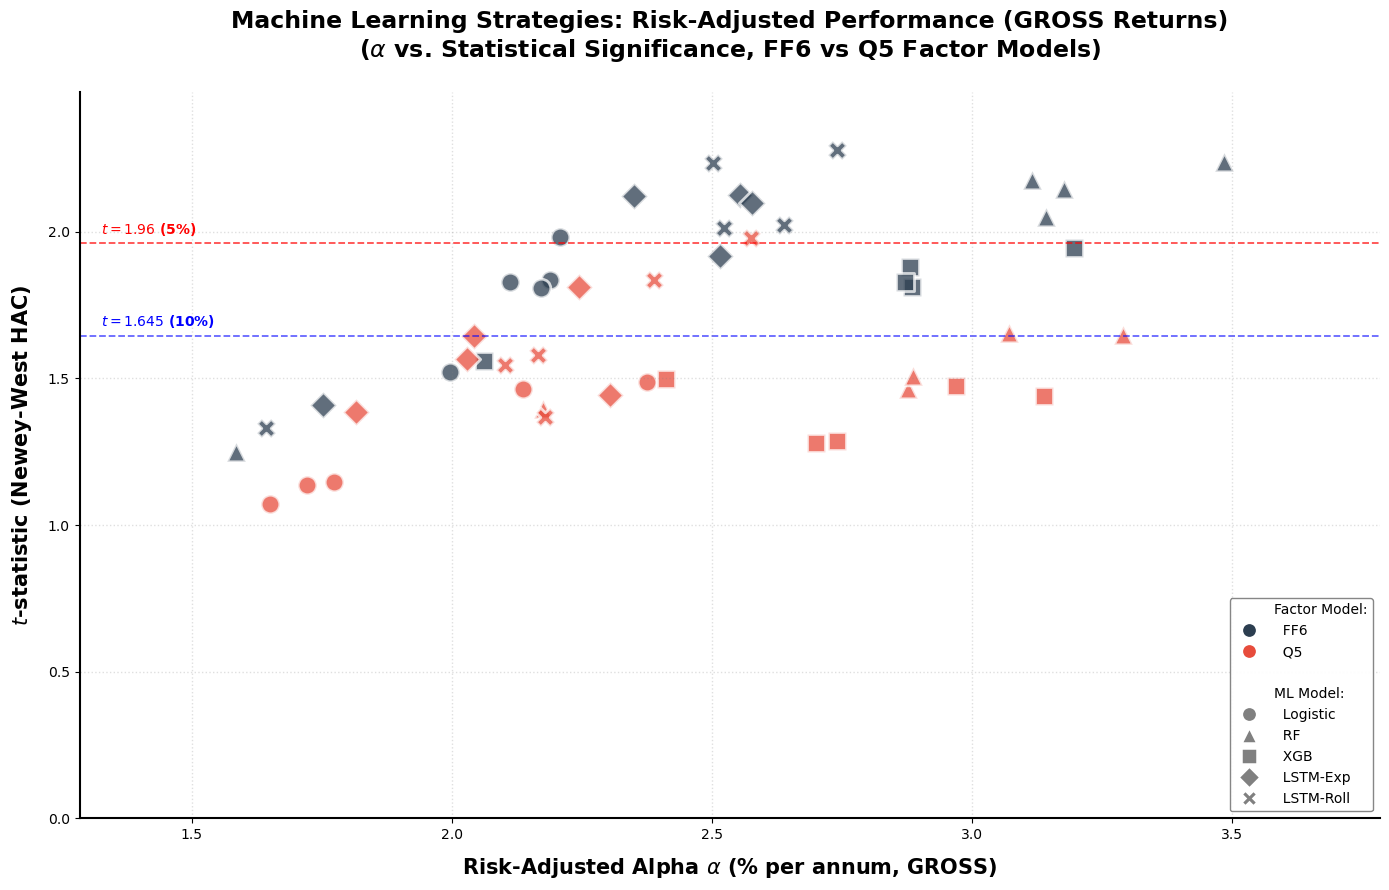


✅ FINAL SCATTER PLOT COMPLETE (GROSS)


In [76]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: FACTOR REGRESSIONS - ML STRATEGIES (GROSS RETURNS)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("FACTOR REGRESSIONS: ML STRATEGIES (GROSS RETURNS - for scatter plot)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# 1. RUN REGRESSIONS FOR EACH (MODEL, BASKET, FACTOR_MODEL) - GROSS
# ────────────────────────────────────────────────────────────────────────────

results_ml_gross = []

for basket in df_returns_filtered['basket'].unique():
    for model in df_returns_filtered['model'].unique():
        
        # Filter to (basket, model)
        # ✅ MODIFICATION CLÉ : Utiliser 'return_gross' au lieu de 'return_net'
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')['return_gross']  # ← GROSS au lieu de NET
        
        if len(ml_ret) == 0:
            continue
        
        # Run regressions for each factor model
        for factor_name, factor_spec in FACTOR_MODELS_BASKETS.items():
            
            factor_cols = factor_spec['factors']
            rf_col = factor_spec['rf']
            factors_data = factor_spec['data']
            
            # Merge with RF
            df_merged = ml_ret.to_frame('ml_ret').merge(
                factors_data[[rf_col]],
                left_index=True,
                right_index=True,
                how='inner'
            )
            df_merged['excess_ret'] = df_merged['ml_ret'] - df_merged[rf_col]
            excess_ret = df_merged['excess_ret']
            
            # Run regression
            result = run_factor_regression_hac(excess_ret, factors_data, factor_cols)
            
            if result:
                result['basket'] = basket
                result['model'] = model
                result['factor_model'] = factor_name
                results_ml_gross.append(result)

# ────────────────────────────────────────────────────────────────────────────
# 2. CONVERT TO DATAFRAME
# ────────────────────────────────────────────────────────────────────────────

df_results_ml_gross = pd.DataFrame(results_ml_gross)

print(f"✅ Regressions completed (GROSS): {len(df_results_ml_gross)} results")
print(f"   • Baskets: {len(df_results_ml_gross['basket'].unique())}")
print(f"   • Models: {len(df_results_ml_gross['model'].unique())}")
print(f"   • Factor models: {sorted(df_results_ml_gross['factor_model'].unique())}\n")

# Quick stats
print("📊 Alpha summary (GROSS, all factor models):")
print(f"   • Mean: {df_results_ml_gross['alpha_ann'].mean()*100:.2f}%")
print(f"   • Median: {df_results_ml_gross['alpha_ann'].median()*100:.2f}%")
print(f"   • t-stat mean: {df_results_ml_gross['t_stat'].mean():.2f}")

print("\n" + "="*120)


# ════════════════════════════════════════════════════════════════════════════
# CELL: SCATTER PLOT - Alpha vs t-stat (FF6 vs Q5, 25 ML strategies) - GROSS
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("="*120)
print("CREATING SCATTER PLOT: Alpha vs t-stat (FF6 vs Q5) - GROSS RETURNS")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: PREPARE DATA (FF6 + Q5 only, 25 ML strategies)
# ────────────────────────────────────────────────────────────────────────────

df_plot = df_results_ml_gross[
    df_results_ml_gross['factor_model'].isin(['FF6', 'Q5'])
].copy()

print(f"✅ Data prepared:")
print(f"   • Total points: {len(df_plot)} (25 strategies × 2 factor models)")
print(f"   • Factor models: FF6, Q5")
print(f"   • Baskets: {len(df_plot['basket'].unique())}")
print(f"   • Models: {len(df_plot['model'].unique())}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: DEFINE COLORS & MARKERS
# ────────────────────────────────────────────────────────────────────────────

# ✅ 2 couleurs (factor models)
FACTOR_COLORS = {
    'FF6': '#2C3E50',      # dark blue-gray
    'Q5': '#E74C3C'        # rouge vif
}

# ✅ 5 formes (ML models)
MODEL_MARKERS = {
    'Logistic L2': 'o',           # cercle
    'Random Forest': '^',         # triangle
    'XGBoost': 's',               # carré
    'LSTM Expanding': 'D',        # diamant
    'LSTM Rolling 10Y': 'X'       # croix
}

print("✅ Visual encoding defined:")
print(f"   • Colors (factor models): FF6={FACTOR_COLORS['FF6']}, Q5={FACTOR_COLORS['Q5']}")
print(f"   • Markers (ML models): {list(MODEL_MARKERS.keys())}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: CREATE FIGURE (single plot, FF6 + Q5 overlay)
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 9))

# ✅ REMOVED GREEN BACKGROUND (no Rectangle patch)

# Plot each combination (factor × model)
for factor in ['FF6', 'Q5']:
    for model in MODEL_MARKERS.keys():
        
        subset = df_plot[
            (df_plot['factor_model'] == factor) &
            (df_plot['model'] == model)
        ]
        
        if len(subset) == 0:
            continue
        
        ax.scatter(
            subset['alpha_ann'] * 100,  # α (%)
            subset['t_stat'],            # t
            color=FACTOR_COLORS[factor],
            marker=MODEL_MARKERS[model],
            s=180,
            alpha=0.75,
            edgecolor='white',
            linewidth=2.0,
            label=f"{factor} - {get_model_display_name(model, compact=True)}"
        )

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: ADD REFERENCE LINES (improved style)
# ────────────────────────────────────────────────────────────────────────────

# α = 0 (vertical)
ax.axvline(0, color='gray', linestyle='-', linewidth=2, alpha=0.4, zorder=1)

# t = 1.96 (horizontal, seuil 5%)
ax.axhline(1.96, color='red', linestyle='--', linewidth=1.3, alpha=0.7, zorder=1)

# t = 1.645 (horizontal, seuil 10%) - ✅ AJOUTÉ
ax.axhline(1.645, color='blue', linestyle='--', linewidth=1.3, alpha=0.6, zorder=1)

# ✅ IMPROVED TEXT LABELS (positioned better to avoid extra space)
# For 5% line
ax.text(ax.get_xlim()[0] + 1.5, 1.96 + 0.02, r'$t = 1.96$ (5%)',
       fontsize=10, va='bottom', ha='left', color='red', weight='bold')

# For 10% line
ax.text(ax.get_xlim()[0] + 1.5, 1.645 + 0.02, r'$t = 1.645$ (10%)',
       fontsize=10, va='bottom', ha='left', color='blue', weight='bold')

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: IMPROVED LEGEND (bottom right, compact)
# ────────────────────────────────────────────────────────────────────────────

# ✅ Build combined legend (factor × model in one list)
legend_handles = []

# Add factor model section
legend_handles.append(Line2D([0], [0], linestyle='', label='Factor Model:', marker=''))
for factor, color in FACTOR_COLORS.items():
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color, markersize=11, 
               label=f'  {factor}', markeredgecolor='white', markeredgewidth=1.8)
    )

# Add spacer
legend_handles.append(Line2D([0], [0], linestyle='', label='', marker=''))

# Add ML model section
legend_handles.append(Line2D([0], [0], linestyle='', label='ML Model:', marker=''))
for model, marker in MODEL_MARKERS.items():
    legend_handles.append(
        Line2D([0], [0], marker=marker, color='w', 
               markerfacecolor='gray', markersize=11, 
               label=f'  {get_model_display_name(model, compact=True)}',
               markeredgecolor='white', markeredgewidth=1.8)
    )

# ✅ LEGEND MOVED TO BOTTOM RIGHT
ax.legend(handles=legend_handles, loc='lower right', 
         frameon=True, fontsize=10, ncol=1, 
         framealpha=0.95, edgecolor='gray')

# ────────────────────────────────────────────────────────────────────────────
# STEP 6: FORMATTING (improved readability)
# ────────────────────────────────────────────────────────────────────────────

ax.set_xlabel(r'Risk-Adjusted Alpha $\alpha$ (% per annum, GROSS)', 
             fontsize=15, fontweight='bold', labelpad=10)
ax.set_ylabel(r'$t$-statistic (Newey-West HAC)', 
             fontsize=15, fontweight='bold', labelpad=10)
ax.set_title('Machine Learning Strategies: Risk-Adjusted Performance (GROSS Returns)\n' + 
            r'($\alpha$ vs. Statistical Significance, FF6 vs Q5 Factor Models)', 
            fontsize=17, fontweight='bold', pad=25)

# Grid style
ax.grid(True, alpha=0.25, linestyle=':', linewidth=1.0, color='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# ✅ Set axis limits (TIGHTER to avoid extra space, NO NEGATIVE)
alpha_vals = df_plot['alpha_ann'].values * 100
t_vals = df_plot['t_stat'].values
ax.set_xlim(alpha_vals.min() - 0.3, alpha_vals.max() + 0.3)
ax.set_ylim(0, t_vals.max() + 0.2)  # ✅ Start at 0 (no negative)

plt.tight_layout()

# ────────────────────────────────────────────────────────────────────────────
# STEP 7: SAVE & DISPLAY
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/00_FIG_results_T_vs_Alpha_GROSS.png')
output_path.parent.mkdir(parents=True, exist_ok=True)

# plt.savefig(output_path, dpi=300, bbox_inches='tight', format='pdf')
plt.savefig(output_path.with_suffix('.png'), dpi=300, bbox_inches='tight')

print(f"✅ Final scatter plot saved:")
print(f"   • PDF: {output_path}")
print(f"   • PNG: {output_path.with_suffix('.png')}")
print(f"   • Total points plotted: {len(df_plot)}")
print(f"   • Factor models: FF6 (dark blue), Q5 (red)")
print(f"   • ML models: 5 shapes")
print(f"   • Significance lines: 5% (red), 10% (orange)")

plt.show()

print("\n" + "="*120)
print("✅ FINAL SCATTER PLOT COMPLETE (GROSS)")
print("="*120)




### Graph ALPHA x T-Stat hac12

CREATING SCATTER PLOT: Alpha vs t-stat (FF6 vs Q5) - FINAL VERSION

✅ Data prepared:
   • Total points: 50 (25 strategies × 2 factor models)
   • Factor models: FF6, Q5
   • Baskets: 5
   • Models: 5

✅ Visual encoding defined:
   • Colors (factor models): FF6=#2C3E50, Q5=#E74C3C
   • Markers (ML models): ['Logistic L2', 'Random Forest', 'XGBoost', 'LSTM Expanding', 'LSTM Rolling 10Y']

✅ Final scatter plot saved:
   • PDF: results/latex/results/00_FIG_results_T_vs_Alpha_.png
   • PNG: results/latex/results/00_FIG_results_T_vs_Alpha_.png
   • Total points plotted: 50
   • Factor models: FF6 (dark blue), Q5 (red)
   • ML models: 5 shapes


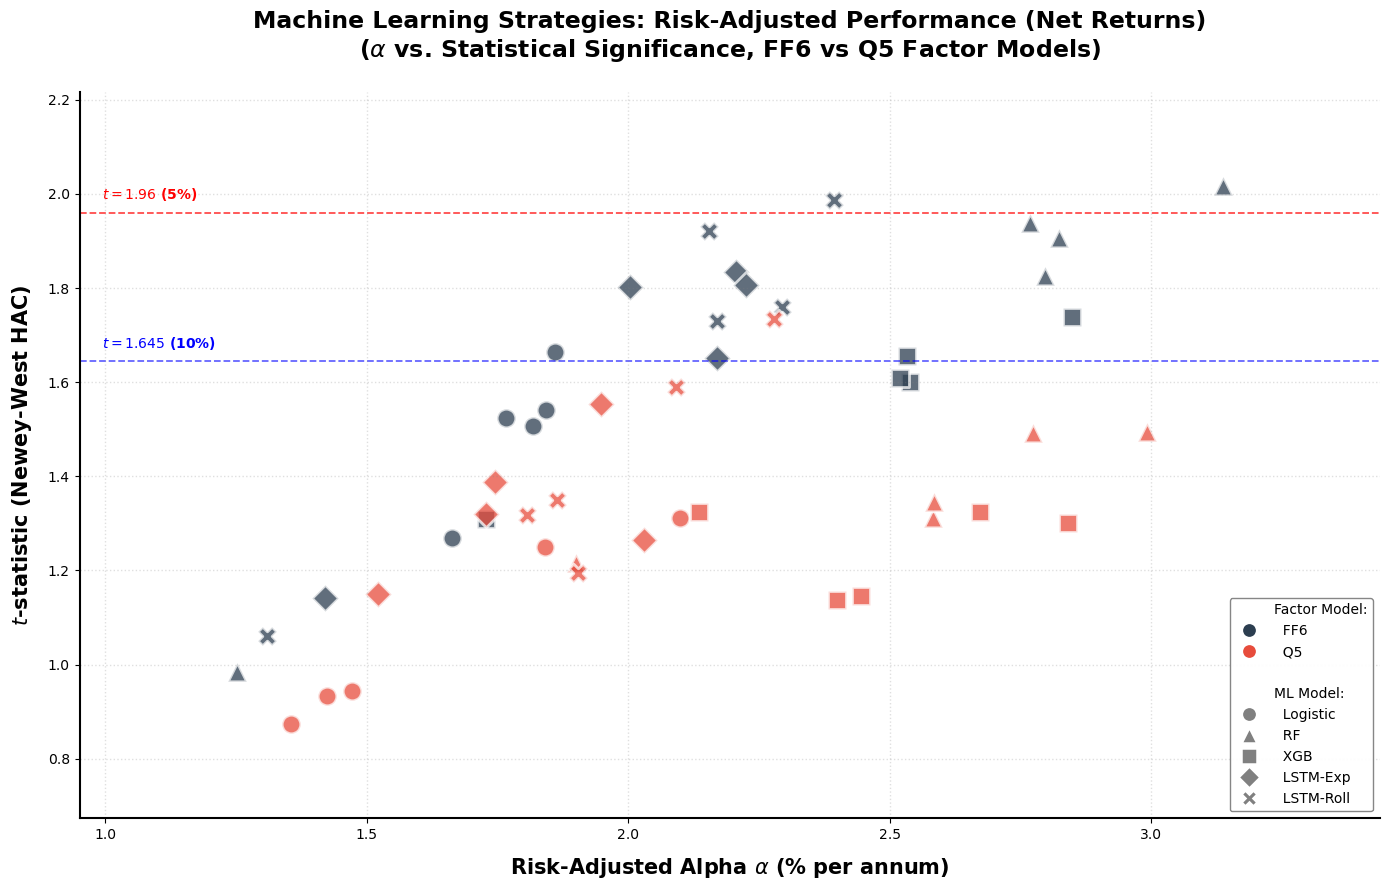


✅ FINAL SCATTER PLOT COMPLETE


In [71]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: SCATTER PLOT - Alpha vs t-stat (FF6 vs Q5, 25 ML strategies) - FINAL
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("="*120)
print("CREATING SCATTER PLOT: Alpha vs t-stat (FF6 vs Q5) - FINAL VERSION")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: PREPARE DATA (FF6 + Q5 only, 25 ML strategies)
# ────────────────────────────────────────────────────────────────────────────

df_plot = df_results_ml[
    df_results_ml['factor_model'].isin(['FF6', 'Q5'])
].copy()

print(f"✅ Data prepared:")
print(f"   • Total points: {len(df_plot)} (25 strategies × 2 factor models)")
print(f"   • Factor models: FF6, Q5")
print(f"   • Baskets: {len(df_plot['basket'].unique())}")
print(f"   • Models: {len(df_plot['model'].unique())}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: DEFINE COLORS & MARKERS
# ────────────────────────────────────────────────────────────────────────────

# ✅ 2 couleurs (factor models)
FACTOR_COLORS = {
    'FF6': '#2C3E50',      # dark blue-gray
    'Q5': '#E74C3C'        # rouge vif
}

# ✅ 5 formes (ML models)
MODEL_MARKERS = {
    'Logistic L2': 'o',           # cercle
    'Random Forest': '^',         # triangle
    'XGBoost': 's',               # carré
    'LSTM Expanding': 'D',        # diamant
    'LSTM Rolling 10Y': 'X'       # croix
}

print("✅ Visual encoding defined:")
print(f"   • Colors (factor models): FF6={FACTOR_COLORS['FF6']}, Q5={FACTOR_COLORS['Q5']}")
print(f"   • Markers (ML models): {list(MODEL_MARKERS.keys())}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: CREATE FIGURE (single plot, FF6 + Q5 overlay)
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 9))

# ✅ REMOVED GREEN BACKGROUND (no Rectangle patch)

# Plot each combination (factor × model)
for factor in ['FF6', 'Q5']:
    for model in MODEL_MARKERS.keys():
        
        subset = df_plot[
            (df_plot['factor_model'] == factor) &
            (df_plot['model'] == model)
        ]
        
        if len(subset) == 0:
            continue
        
        ax.scatter(
            subset['alpha_ann'] * 100,  # α (%)
            subset['t_stat'],            # t
            color=FACTOR_COLORS[factor],
            marker=MODEL_MARKERS[model],
            s=180,
            alpha=0.75,
            edgecolor='white',
            linewidth=2.0,
            label=f"{factor} - {get_model_display_name(model, compact=True)}"
        )

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: ADD REFERENCE LINES (improved style)
# ────────────────────────────────────────────────────────────────────────────

# α = 0 (vertical)
ax.axvline(0, color='gray', linestyle='-', linewidth=2, alpha=0.4, zorder=1)


# t = ±1.96 (horizontal, seuil 5%)
ax.axhline(1.96, color='red', linestyle='--', linewidth=1.3, alpha=0.7, zorder=1)
# t = 1.645 (horizontal, seuil 10%) - ✅ AJOUTÉ
ax.axhline(1.645, color='blue', linestyle='--', linewidth=1.3, alpha=0.6, zorder=1)

# ✅ IMPROVED TEXT LABELS (positioned better to avoid extra space)
# For top line
ax.text(ax.get_xlim()[0] + 1.15, 1.96 + 0.02, r'$t = 1.96$ (5%)',
       fontsize=10, va='bottom', ha='left', color='red', weight='bold')


# For 10% line
ax.text(ax.get_xlim()[0] + 1.15, 1.645 + 0.02, r'$t = 1.645$ (10%)',
       fontsize=10, va='bottom', ha='left', color='blue', weight='bold')

# # For bottom line (positioned ABOVE the line to avoid pushing ylim down)
# ax.text(ax.get_xlim()[0] + 0.1, -1.96 + 0.1, r'$t = -1.96$ (5%)',
#        fontsize=10, va='bottom', ha='left', color='red', weight='bold')

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: IMPROVED LEGEND (bottom right, compact)
# ────────────────────────────────────────────────────────────────────────────

# ✅ Build combined legend (factor × model in one list)
legend_handles = []

# Add factor model section
legend_handles.append(Line2D([0], [0], linestyle='', label='Factor Model:', marker=''))
for factor, color in FACTOR_COLORS.items():
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color, markersize=11, 
               label=f'  {factor}', markeredgecolor='white', markeredgewidth=1.8)
    )

# Add spacer
legend_handles.append(Line2D([0], [0], linestyle='', label='', marker=''))

# Add ML model section
legend_handles.append(Line2D([0], [0], linestyle='', label='ML Model:', marker=''))
for model, marker in MODEL_MARKERS.items():
    legend_handles.append(
        Line2D([0], [0], marker=marker, color='w', 
               markerfacecolor='gray', markersize=11, 
               label=f'  {get_model_display_name(model, compact=True)}',
               markeredgecolor='white', markeredgewidth=1.8)
    )

# ✅ LEGEND MOVED TO BOTTOM RIGHT
ax.legend(handles=legend_handles, loc='lower right', 
         frameon=True, fontsize=10, ncol=1, 
         framealpha=0.95, edgecolor='gray')

# ────────────────────────────────────────────────────────────────────────────
# STEP 6: FORMATTING (improved readability)
# ────────────────────────────────────────────────────────────────────────────

ax.set_xlabel(r'Risk-Adjusted Alpha $\alpha$ (% per annum)', 
             fontsize=15, fontweight='bold', labelpad=10)
ax.set_ylabel(r'$t$-statistic (Newey-West HAC)', 
             fontsize=15, fontweight='bold', labelpad=10)
ax.set_title('Machine Learning Strategies: Risk-Adjusted Performance (Net Returns)\n' + 
            r'($\alpha$ vs. Statistical Significance, FF6 vs Q5 Factor Models)', 
            fontsize=17, fontweight='bold', pad=25)

# Grid style
ax.grid(True, alpha=0.25, linestyle=':', linewidth=1.0, color='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# ✅ Set axis limits (TIGHTER to avoid extra space)
alpha_vals = df_plot['alpha_ann'].values * 100
t_vals = df_plot['t_stat'].values
ax.set_xlim(alpha_vals.min() - 0.3, alpha_vals.max() + 0.3)
ax.set_ylim(t_vals.min() - 0.2, t_vals.max() + 0.2)  # ✅ Reduced padding

plt.tight_layout()

# ────────────────────────────────────────────────────────────────────────────
# STEP 7: SAVE & DISPLAY
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/00_FIG_results_T_vs_Alpha_.png')
output_path.parent.mkdir(parents=True, exist_ok=True)

# plt.savefig(output_path, dpi=300, bbox_inches='tight', format='pdf')
plt.savefig(output_path.with_suffix('.png'), dpi=300, bbox_inches='tight')

print(f"✅ Final scatter plot saved:")
print(f"   • PDF: {output_path}")
print(f"   • PNG: {output_path.with_suffix('.png')}")
print(f"   • Total points plotted: {len(df_plot)}")
print(f"   • Factor models: FF6 (dark blue), Q5 (red)")
print(f"   • ML models: 5 shapes")

plt.show()

print("\n" + "="*120)
print("✅ FINAL SCATTER PLOT COMPLETE")
print("="*120)

### rolling sharp

CREATING FIGURE 1: ROLLING SHARPE + DELTA PANEL (ML - MARKET)

🔍 Selecting best ML strategy (max net Sharpe, full-sample)...

✅ Best ML strategy identified:
   • Basket: Beta Expansion
   • Model: LSTM (Rolling 10Y)
   • Net Sharpe (full-sample): 0.825

📊 Loading returns & computing rolling Sharpe...

✅ Returns loaded: 528 months

✅ Rolling Sharpe computed:
   • Window: 60 months
   • Valid observations: 469
   • Period: 1985-06-28 → 2024-06-28

🎨 Creating figure (2 panels)...

   • Resolution: 300 DPI
   • Best strategy: Beta Expansion + LSTM (Rolling 10Y)
   • Full-sample net Sharpe: 0.825


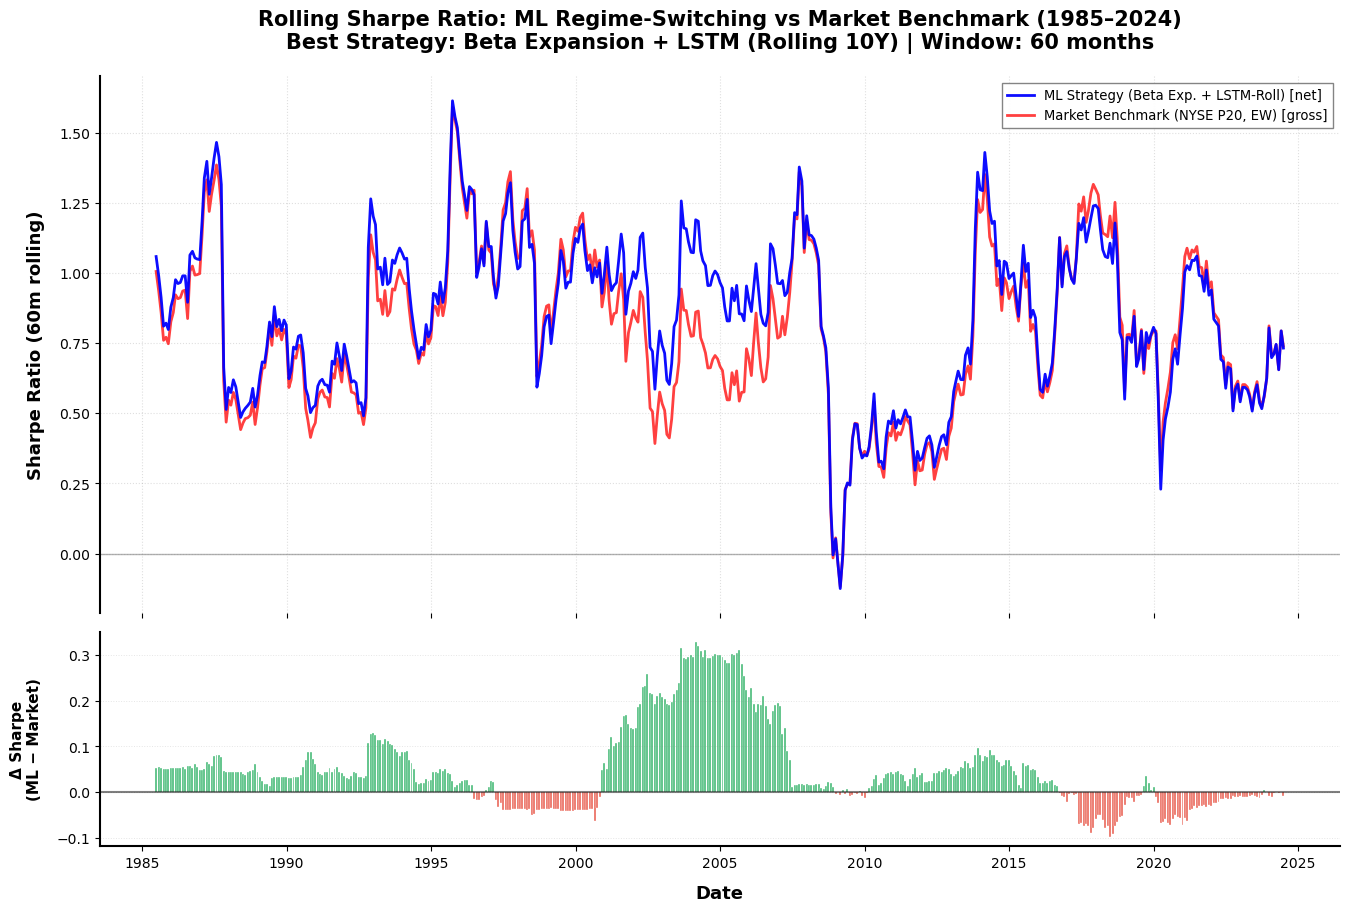


✅ FIGURE 1 (WITH DELTA PANEL) COMPLETE


In [66]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: FIGURE 1 - ROLLING SHARPE (60M, NET) + DELTA PANEL (ML - MARKET)
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("="*120)
print("CREATING FIGURE 1: ROLLING SHARPE + DELTA PANEL (ML - MARKET)")
print("="*120 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: IDENTIFY BEST ML STRATEGY (reuse existing code)
# ────────────────────────────────────────────────────────────────────────────

print("🔍 Selecting best ML strategy (max net Sharpe, full-sample)...\n")

sharpe_ranking = []

for basket in df_returns_filtered['basket'].unique():
    for model in df_returns_filtered['model'].unique():
        
        ml_ret = df_returns_filtered[
            (df_returns_filtered['basket'] == basket) &
            (df_returns_filtered['model'] == model)
        ].set_index('date')['return_net']
        
        if len(ml_ret) < 36:
            continue
        
        sharpe_net = (ml_ret.mean() / ml_ret.std()) * np.sqrt(12)
        
        sharpe_ranking.append({
            'basket': basket,
            'model': model,
            'sharpe_net': sharpe_net
        })

df_ranking = pd.DataFrame(sharpe_ranking).sort_values('sharpe_net', ascending=False)

best_basket = df_ranking.iloc[0]['basket']
best_model = df_ranking.iloc[0]['model']
best_sharpe = df_ranking.iloc[0]['sharpe_net']

print(f"✅ Best ML strategy identified:")
print(f"   • Basket: {get_basket_display_name(best_basket)}")
print(f"   • Model: {get_model_display_name(best_model)}")
print(f"   • Net Sharpe (full-sample): {best_sharpe:.3f}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: LOAD RETURNS & COMPUTE ROLLING SHARPE
# ────────────────────────────────────────────────────────────────────────────

print("📊 Loading returns & computing rolling Sharpe...\n")

# Load returns
ml_ret = df_returns_filtered[
    (df_returns_filtered['basket'] == best_basket) &
    (df_returns_filtered['model'] == best_model)
].set_index('date')['return_net']

market_ret = df_basket_returns_filtered[
    (df_basket_returns_filtered['basket'] == best_basket) &
    (df_basket_returns_filtered['strategy'] == 'Buy&Hold Offensive')
].set_index('date')['return_gross']

# Merge
df_plot = pd.DataFrame({
    'ML': ml_ret,
    'Market': market_ret
}).dropna()

print(f"✅ Returns loaded: {len(df_plot)} months\n")

# Compute rolling Sharpe
WINDOW = 60

def rolling_sharpe(returns, window):
    mean = returns.rolling(window).mean() * 12
    std = returns.rolling(window).std() * np.sqrt(12)
    return mean / std

df_plot['ML_Sharpe'] = rolling_sharpe(df_plot['ML'], WINDOW)
df_plot['Market_Sharpe'] = rolling_sharpe(df_plot['Market'], WINDOW)
df_plot['Delta_Sharpe'] = df_plot['ML_Sharpe'] - df_plot['Market_Sharpe']

# Drop NaN
df_plot = df_plot.dropna()

print(f"✅ Rolling Sharpe computed:")
print(f"   • Window: {WINDOW} months")
print(f"   • Valid observations: {len(df_plot)}")
print(f"   • Period: {df_plot.index.min().date()} → {df_plot.index.max().date()}\n")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: CREATE FIGURE (2 PANELS)
# ────────────────────────────────────────────────────────────────────────────

print("🎨 Creating figure (2 panels)...\n")

# ✅ Create 2 subplots (70% top, 30% bottom)
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(16, 10),
    gridspec_kw={'height_ratios': [2.5, 1], 'hspace': 0.05},  # ✅ Tight spacing
    facecolor='white'
)

# ════════════════════════════════════════════════════════════════════════════
# PANEL A: ROLLING SHARPE (ML vs Market)
# ════════════════════════════════════════════════════════════════════════════

# Plot curves
ax1.plot(df_plot.index, df_plot['ML_Sharpe'], 
         color='blue', linestyle='-', linewidth=2, alpha=0.95,
         label=f"ML Strategy ({get_basket_display_name(best_basket, compact=True)} + {get_model_display_name(best_model, compact=True)}) [net]",
         zorder=3)

ax1.plot(df_plot.index, df_plot['Market_Sharpe'], 
         color='red', linestyle='-', linewidth=2, alpha=0.75,
         label='Market Benchmark (NYSE P20, EW) [gross]',
         zorder=2)

# Reference line (Sharpe = 0)
ax1.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.3, zorder=1)

# Formatting
ax1.set_ylabel('Sharpe Ratio (60m rolling)', fontsize=13, fontweight='bold', labelpad=10)
ax1.set_title('Rolling Sharpe Ratio: ML Regime-Switching vs Market Benchmark (1985–2024)\n' +
             f'Best Strategy: {get_basket_display_name(best_basket)} + {get_model_display_name(best_model)} | Window: {WINDOW} months',
             fontsize=15, fontweight='bold', pad=20)

# Legend
ax1.legend(loc='upper right', frameon=True, fontsize=9.5, 
          framealpha=0.97, edgecolor='gray', fancybox=False)

# Grid
ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.8, color='gray')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_visible(False)  # ✅ Hide bottom spine (merged with ax2)

# ✅ Remove x-axis labels (will be on ax2)
ax1.set_xticklabels([])

# ════════════════════════════════════════════════════════════════════════════
# PANEL B: DELTA SHARPE (ML - MARKET) - BAR PLOT
# ════════════════════════════════════════════════════════════════════════════

# ✅ Color bars: green if positive, red if negative
colors = ['#27AE60' if x > 0 else '#E74C3C' for x in df_plot['Delta_Sharpe']]

# Plot bars
ax2.bar(df_plot.index, df_plot['Delta_Sharpe'], 
        color=colors, alpha=0.85, width=25, edgecolor='white', linewidth=0.3)

# Reference line (Δ = 0)
ax2.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5, zorder=3)

# Formatting
ax2.set_xlabel('Date', fontsize=13, fontweight='bold', labelpad=10)
ax2.set_ylabel('Δ Sharpe\n(ML − Market)', fontsize=11, fontweight='bold', labelpad=10)

# Grid
ax2.grid(True, alpha=0.2, linestyle=':', linewidth=0.7, color='gray', axis='y')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.5)
ax2.spines['bottom'].set_linewidth(1.5)

# ✅ Align x-axis with ax1
ax2.set_xlim(ax1.get_xlim())

# Tight layout
plt.tight_layout()

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: SAVE (PDF + PNG)
# ────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR = Path('results/latex/results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# output_pdf = OUTPUT_DIR / '00_FIG_results_Rolling_Sharpe_with_Delta.pdf'
output_png = OUTPUT_DIR / '00_FIG_results_Rolling_Sharpe_with_Delta.png'

# plt.savefig(output_pdf, dpi=300, bbox_inches='tight', format='pdf')
plt.savefig(output_png, dpi=300, bbox_inches='tight', format='png')

# print(f"✅ Figure 1 (with Delta panel) saved:")
# print(f"   • PDF: {output_pdf}")
# print(f"   • PNG: {output_png}")
print(f"   • Resolution: 300 DPI")
print(f"   • Best strategy: {get_basket_display_name(best_basket)} + {get_model_display_name(best_model)}")
print(f"   • Full-sample net Sharpe: {best_sharpe:.3f}")

plt.show()

print("\n" + "="*120)
print("✅ FIGURE 1 (WITH DELTA PANEL) COMPLETE")
print("="*120)